# In-situ skill from raw time series: pre-SMAP vs SMAP-era

This notebook focuses on one in-situ network at a time (`SCAN` or `USCRN`) and compares OL vs DA over two fixed periods:

- pre-SMAP: **2007-06-01** to **2015-03-31**
- SMAP-era: **2015-04-01** to **2024-06-30**

Workflow:
1. Load OL/DA raw MAT time series.
2. Run obs-only reliability checks first.
3. Select top-N sites per depth (surface + rootzone).
4. Compute `R`, `anomR`, and `ubRMSE` for each period.
5. Plot bar charts, maps, and time series.


In [60]:
from pathlib import Path
import sys
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

# -------------------------
# User configuration
# -------------------------
NETWORK = "SCAN"  # "SCAN" or "USCRN"

BASE_DIR = Path("/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2")
RAW_MAT_FILES = [
    BASE_DIR / f"LS_OLv8_M36_{NETWORK}_SM_1d_c1234smv_25yr_raw_timeseries.mat",
    BASE_DIR / f"LS_DAv8_M36_{NETWORK}_SM_1d_c1234smv_25yr_raw_timeseries.mat",
]

RANGES = [
    ("pre-SMAP", "2007-06-01", "2015-03-31"),
    ("SMAP-era", "2015-04-01", "2021-04-01"),   # previously "2021-04-01", "2024-06-30"
]

TOP_N_SITES_BY_DEPTH = {0: 40, 1: 30}  # depth-specific top-N: 0=surface, 1=rootzone
MIN_DAYS_PER_RANGE_SURF = 800
MIN_DAYS_PER_RANGE_RZ = 800

NMIN = 200      # paired samples for get_validation_stats
NMIN_DAY = 30   # minimum per DOY sample count for anomaly calc
ADD_ANOMR = True

# reliability thresholds
QC_MIN_YEARS = 10
COVERAGE_DROP_FRAC = 0.5
VAR_DRIFT_FACTOR = 2.0
KS_PVAL_THRESH = 0.01
SEASONAL_CORR_MIN = 0.7

# plotting controls
DEPTH_NAMES = {0: "surface", 1: "rootzone"}
EXP_ORDER = ["OL", "DA"]
MAP_METRIC = "R"          # one of: R, anomR, ubRMSE
TS_DEPTH = 0               # 0=surface, 1=rootzone
TS_MAX_SITES = 8
TS_SITE_IDS = None         # set list of site indices to override auto selection

OUT_DIR = BASE_DIR
print(f"Network: {NETWORK}")
print("Raw files:")
for p in RAW_MAT_FILES:
    print(f"  - {p}")


Network: SCAN
Raw files:
  - /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_OLv8_M36_SCAN_SM_1d_c1234smv_25yr_raw_timeseries.mat
  - /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_DAv8_M36_SCAN_SM_1d_c1234smv_25yr_raw_timeseries.mat


In [61]:
# -------------------------
# Helpers
# -------------------------
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
            REPO_ROOT = parent
            break
sys.path.insert(0, str(REPO_ROOT / "projects/matlab2python/scripts"))

from sm_skill_vs_insitu import get_validation_stats, compute_anom  # type: ignore


def load_mat_file(path: Path):
    try:
        return sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    except NotImplementedError as e:
        try:
            import h5py
        except Exception as e2:
            raise RuntimeError(
                f"MAT file appears to be v7.3 (HDF5), but h5py is unavailable: {e2}"
            ) from e
        with h5py.File(path, "r") as f:
            return {k: f[k] for k in f.keys()}


def mat_struct_to_array(ms, field):
    if isinstance(ms, np.ndarray):
        flat = ms.ravel()
        return np.array([getattr(x, field) for x in flat])
    return np.array([getattr(ms, field)])


def _safe_field(dtv, field, fallback=None):
    try:
        arr = mat_struct_to_array(dtv, field).astype(int).ravel()
        return arr
    except Exception:
        if fallback is None:
            raise
        return np.full_like(fallback, fallback)


def build_timestamps(dtv):
    year = mat_struct_to_array(dtv, "year").astype(int).ravel()
    month = mat_struct_to_array(dtv, "month").astype(int).ravel()
    day = mat_struct_to_array(dtv, "day").astype(int).ravel()

    try:
        hour = mat_struct_to_array(dtv, "hour").astype(int).ravel()
    except Exception:
        hour = np.zeros_like(year)

    try:
        minute = mat_struct_to_array(dtv, "min").astype(int).ravel()
    except Exception:
        minute = np.zeros_like(year)

    try:
        second = mat_struct_to_array(dtv, "sec").astype(int).ravel()
    except Exception:
        second = np.zeros_like(year)

    timestamps = np.array([
        dt.datetime(int(y), int(m), int(d), int(h), int(mi), int(s))
        for y, m, d, h, mi, s in zip(year, month, day, hour, minute, second)
    ])

    dates_only = np.array([t.date() for t in timestamps])

    try:
        doy_vec = mat_struct_to_array(dtv, "dofyr").astype(int).ravel()
    except Exception:
        doy_vec = np.array([t.timetuple().tm_yday for t in timestamps], dtype=int)

    return timestamps, dates_only, doy_vec


def _to_1d_array(v, n_site=None):
    arr = np.ravel(v)
    if n_site is not None and arr.size >= n_site:
        arr = arr[:n_site]
    return arr


def _normalize_site_ids(raw_ids, n_site):
    if raw_ids is None:
        return [f"site_{i}" for i in range(n_site)]

    arr = np.ravel(raw_ids)
    ids = []
    for x in arr[:n_site]:
        if isinstance(x, bytes):
            s = x.decode("utf-8", errors="ignore")
        elif isinstance(x, str):
            s = x
        else:
            try:
                x_arr = np.array(x).squeeze()
                if x_arr.dtype.kind in {"U", "S"}:
                    s = "".join(np.ravel(x_arr).astype(str)).strip()
                else:
                    s = str(x_arr)
            except Exception:
                s = str(x)
        ids.append(s.strip())

    if len(ids) < n_site:
        ids.extend([f"site_{i}" for i in range(len(ids), n_site)])
    return ids


def extract_site_meta(mat, n_site):
    lat = np.full(n_site, np.nan, dtype=float)
    lon = np.full(n_site, np.nan, dtype=float)
    ids = [f"site_{i}" for i in range(n_site)]

    for k in ["INSITU_lat", "site_lat", "lat", "LAT"]:
        if k in mat:
            try:
                lat_tmp = _to_1d_array(mat[k], n_site=n_site).astype(float)
                if lat_tmp.size == n_site:
                    lat = lat_tmp
                    break
            except Exception:
                pass

    for k in ["INSITU_lon", "site_lon", "lon", "LON"]:
        if k in mat:
            try:
                lon_tmp = _to_1d_array(mat[k], n_site=n_site).astype(float)
                if lon_tmp.size == n_site:
                    lon = lon_tmp
                    break
            except Exception:
                pass

    for k in ["INSITU_id", "site_id", "id", "ID"]:
        if k in mat:
            try:
                ids = _normalize_site_ids(mat[k], n_site)
                break
            except Exception:
                pass

    return {"lat": lat, "lon": lon, "ids": ids}


print("Helper setup complete.")


Helper setup complete.


In [62]:
# -------------------------
# Load raw arrays
# -------------------------
for p in RAW_MAT_FILES:
    if not p.exists():
        raise FileNotFoundError(f"Missing raw MAT file: {p}")

raw = {}
meta = None

for raw_path in RAW_MAT_FILES:
    mat = load_mat_file(raw_path)
    required = ["LDAS_sm_org", "INSITU_sm", "date_time_vec"]
    missing = [k for k in required if k not in mat]
    if missing:
        raise KeyError(f"{raw_path.name} missing required keys: {missing}")

    ldas = np.array(mat["LDAS_sm_org"], dtype=float)
    if ldas.ndim == 4:
        ldas = ldas[:, :, :, 0]
    if ldas.ndim != 3:
        raise ValueError(f"Unexpected LDAS_sm_org shape for {raw_path.name}: {ldas.shape}")

    obs = np.array(mat["INSITU_sm"], dtype=float)
    if obs.ndim != 3:
        raise ValueError(f"Unexpected INSITU_sm shape for {raw_path.name}: {obs.shape}")

    ldas = ldas[:, :2, :]
    obs = obs[:, :2, :]

    # pair-mask model and obs
    ldas[ldas == 0] = np.nan
    ldas[np.isnan(obs)] = np.nan
    obs[np.isnan(ldas)] = np.nan

    timestamps, dates_only, doy_vec = build_timestamps(mat["date_time_vec"])

    exp_key = "OL" if "_OL" in raw_path.name else "DA"
    raw[exp_key] = {
        "ldas": ldas,
        "obs": obs,
        "timestamps": timestamps,
        "dates_only": dates_only,
        "doy": doy_vec,
        "path": raw_path,
        "mat": mat,
    }

    if meta is None:
        meta = extract_site_meta(mat, n_site=ldas.shape[2])

if not set(EXP_ORDER).issubset(set(raw.keys())):
    raise RuntimeError(f"Expected experiments {EXP_ORDER}, found {list(raw.keys())}")

# use OL as canonical obs/time vectors
obs = raw["OL"]["obs"].copy()
timestamps = raw["OL"]["timestamps"]
dates_only = raw["OL"]["dates_only"]
doy_vec = raw["OL"]["doy"]

ldas_by_exp = {k: raw[k]["ldas"].copy() for k in EXP_ORDER}

# enforce obs paired with both experiments
for exp in EXP_ORDER:
    ldas_by_exp[exp][np.isnan(obs)] = np.nan
obs[np.isnan(ldas_by_exp["OL"])] = np.nan
obs[np.isnan(ldas_by_exp["DA"])] = np.nan
for exp in EXP_ORDER:
    ldas_by_exp[exp][np.isnan(obs)] = np.nan

n_time, n_depth, n_site = obs.shape
if n_depth < 2:
    raise RuntimeError(f"Expected >=2 depths (surface/rootzone), found {n_depth}")

print(f"Loaded network={NETWORK}")
print(f"Experiments: {EXP_ORDER}")
print(f"Shape: time={n_time}, depth={n_depth}, site={n_site}")
if meta is not None:
    print("Meta available:",
          f"lat_finite={np.isfinite(meta['lat']).sum()}",
          f"lon_finite={np.isfinite(meta['lon']).sum()}")


Loaded network=SCAN
Experiments: ['OL', 'DA']
Shape: time=8766, depth=2, site=146
Meta available: lat_finite=146 lon_finite=146


In [63]:
# first 5 site IDs by raw site index
if meta is None or "ids" not in meta:
    raise RuntimeError("Site metadata/IDs not available")

n = min(5, len(meta["ids"]))
pd.DataFrame({
    "site_index": np.arange(n),
    "site_id": meta["ids"][:n],
})

,site_index,site_id
0,0,2001
1,1,2004
2,2,2005
3,3,2006
4,4,2007


In [64]:
# -------------------------
# Build period masks
# -------------------------
range_masks = {}
for name, s0, s1 in RANGES:
    t0 = dt.datetime.fromisoformat(s0)
    t1 = dt.datetime.fromisoformat(s1)
    mask = (timestamps >= t0) & (timestamps <= t1)
    range_masks[name] = mask

range_summary = []
for name, _, _ in RANGES:
    m = range_masks[name]
    range_summary.append((name, int(np.sum(m)), str(timestamps[m][0]) if np.any(m) else "NA", str(timestamps[m][-1]) if np.any(m) else "NA"))

range_df = pd.DataFrame(range_summary, columns=["range", "n_steps", "first_time", "last_time"])
range_df


,range,n_steps,first_time,last_time
0,pre-SMAP,2860,2007-06-01 12:00:00,2015-03-30 12:00:00
1,SMAP-era,2192,2015-04-01 12:00:00,2021-03-31 12:00:00


## 1) Obs-only reliability checks (run this first)

QC is computed per depth and per site from observations only, then combined with paired-sample readiness checks for OL and DA over both periods.


In [65]:
try:
    from scipy.stats import ks_2samp
except Exception:
    ks_2samp = None

years = np.array([t.year for t in timestamps], dtype=int)
months = np.array([t.month for t in timestamps], dtype=int)

pre_name = RANGES[0][0]
smap_name = RANGES[1][0]
pre_mask = range_masks[pre_name]
smap_mask = range_masks[smap_name]

qc_by_depth = {}

for depth in [0, 1]:
    min_days = MIN_DAYS_PER_RANGE_SURF if depth == 0 else MIN_DAYS_PER_RANGE_RZ
    rows = []

    for site in range(n_site):
        series = obs[:, depth, site].astype(float)
        if np.all(np.isnan(series)):
            continue

        df = pd.DataFrame({"year": years, "val": series})
        cov = df.groupby("year")["val"].apply(lambda s: np.isfinite(s).sum())
        if cov.size < QC_MIN_YEARS:
            continue

        cov_med = float(np.median(cov))
        cov_min = int(np.min(cov))
        coverage_drop = cov_min < cov_med * (1.0 - COVERAGE_DROP_FRAC)

        period_counts = []
        for r_name, _, _ in RANGES:
            m = range_masks[r_name]
            period_counts.append(int(np.isfinite(series[m]).sum()))
        coverage_period_fail = any(c < min_days for c in period_counts)
        period_min_count = int(np.min(period_counts))
        period_total_count = int(np.sum(period_counts))

        mean_pre = float(np.nanmean(series[pre_mask])) if np.any(pre_mask) else np.nan
        mean_smap = float(np.nanmean(series[smap_mask])) if np.any(smap_mask) else np.nan
        step_change = abs(mean_smap - mean_pre) if np.isfinite(mean_pre) and np.isfinite(mean_smap) else np.nan

        var_pre = np.nanvar(series[pre_mask])
        var_smap = np.nanvar(series[smap_mask])
        if var_pre > 0 and np.isfinite(var_smap):
            var_ratio = float(var_smap / var_pre)
        else:
            var_ratio = np.nan
        var_drift = np.isfinite(var_ratio) and ((var_ratio > VAR_DRIFT_FACTOR) or (var_ratio < 1.0 / VAR_DRIFT_FACTOR))

        if ks_2samp is not None:
            v1 = series[pre_mask & np.isfinite(series)]
            v2 = series[smap_mask & np.isfinite(series)]
            if v1.size > 10 and v2.size > 10:
                ks_p = float(ks_2samp(v1, v2).pvalue)
            else:
                ks_p = np.nan
        else:
            ks_p = np.nan
        dist_shift = np.isfinite(ks_p) and (ks_p < KS_PVAL_THRESH)

        clim_pre = pd.DataFrame({"m": months[pre_mask], "v": series[pre_mask]}).groupby("m")["v"].mean()
        clim_smap = pd.DataFrame({"m": months[smap_mask], "v": series[smap_mask]}).groupby("m")["v"].mean()
        common_m = clim_pre.index.intersection(clim_smap.index)
        if common_m.size >= 6:
            c1 = clim_pre.loc[common_m].to_numpy()
            c2 = clim_smap.loc[common_m].to_numpy()
            if np.all(np.isfinite(c1)) and np.all(np.isfinite(c2)):
                seasonal_corr = float(np.corrcoef(c1, c2)[0, 1])
            else:
                seasonal_corr = np.nan
        else:
            seasonal_corr = np.nan
        seasonal_shift = np.isfinite(seasonal_corr) and (seasonal_corr < SEASONAL_CORR_MIN)

        rows.append({
            "site": int(site),
            "depth": int(depth),
            "coverage_min": cov_min,
            "coverage_med": cov_med,
            "coverage_drop": bool(coverage_drop),
            "period_counts": period_counts,
            "period_min_count": period_min_count,
            "period_total_count": period_total_count,
            "coverage_period_fail": bool(coverage_period_fail),
            "step_change_mean": float(step_change) if np.isfinite(step_change) else np.nan,
            "var_ratio": float(var_ratio) if np.isfinite(var_ratio) else np.nan,
            "var_drift": bool(var_drift),
            "ks_p": float(ks_p) if np.isfinite(ks_p) else np.nan,
            "dist_shift": bool(dist_shift),
            "seasonal_corr": float(seasonal_corr) if np.isfinite(seasonal_corr) else np.nan,
            "seasonal_shift": bool(seasonal_shift),
        })

    qc_df = pd.DataFrame(rows)
    if qc_df.empty:
        raise RuntimeError(f"No QC rows produced for depth={depth}")

    qc_df["flagged"] = qc_df[["coverage_drop", "var_drift", "dist_shift", "seasonal_shift"]].any(axis=1)
    qc_df["score"] = (
        qc_df["coverage_drop"].astype(int)
        + 5 * qc_df["coverage_period_fail"].astype(int)
        + qc_df["var_drift"].astype(int)
        + qc_df["dist_shift"].astype(int)
        + qc_df["seasonal_shift"].astype(int)
    )

    qc_df = qc_df.sort_values(
        ["period_min_count", "period_total_count", "score", "coverage_period_fail", "coverage_min"],
        ascending=[False, False, True, True, False],
    ).reset_index(drop=True)

    qc_by_depth[depth] = qc_df

    print(f"Depth {depth} ({DEPTH_NAMES.get(depth, depth)}):")
    print(f"  Sites with QC rows: {len(qc_df)}")
    print(f"  Flagged sites: {int(qc_df['flagged'].sum())}")

qc_by_depth[0].head(20)


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/4192344259.py:43: RuntimeWarning: Mean of empty slice
  mean_smap = float(np.nanmean(series[smap_mask])) if np.any(smap_mask) else np.nan
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/4192344259.py:47: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_smap = np.nanvar(series[smap_mask])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/4192344259.py:42: RuntimeWarning: Mean of empty slice
  mean_pre = float(np.nanmean(series[pre_mask])) if np.any(pre_mask) else np.nan
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/4192344259.py:46: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_pre = np.nanvar(series[pre_mask])


Depth 0 (surface):
  Sites with QC rows: 142
  Flagged sites: 133


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/4192344259.py:42: RuntimeWarning: Mean of empty slice
  mean_pre = float(np.nanmean(series[pre_mask])) if np.any(pre_mask) else np.nan
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/4192344259.py:46: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_pre = np.nanvar(series[pre_mask])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/4192344259.py:43: RuntimeWarning: Mean of empty slice
  mean_smap = float(np.nanmean(series[smap_mask])) if np.any(smap_mask) else np.nan
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/4192344259.py:47: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_smap = np.nanvar(series[smap_mask])


Depth 1 (rootzone):
  Sites with QC rows: 118
  Flagged sites: 103


,site,depth,coverage_min,coverage_med,coverage_drop,period_counts,period_min_count,period_total_count,coverage_period_fail,step_change_mean,var_ratio,var_drift,ks_p,dist_shift,seasonal_corr,seasonal_shift,flagged,score
0,67,0,0,289.0,True,"[2263, 2100]",2100,4363,False,0.007177,0.809218,False,1.191278e-30,True,0.634180,True,True,3
1,72,0,0,321.0,True,"[2334, 2071]",2071,4405,False,0.006346,0.697012,False,6.417222e-32,True,0.868542,False,True,2
2,25,0,0,308.0,True,"[2364, 2026]",2026,4390,False,0.015739,1.665677,False,9.778098e-105,True,0.500389,True,True,3
3,31,0,0,298.0,True,"[1990, 2147]",1990,4137,False,0.020625,0.876322,False,3.696963e-49,True,0.657836,True,True,3
4,37,0,0,326.0,True,"[2517, 1970]",1970,4487,False,0.018154,0.730079,False,1.984719e-27,True,0.717412,False,True,2
5,46,0,0,302.0,True,"[1930, 1990]",1930,3920,False,0.034485,0.795603,False,1.578319e-23,True,0.835394,False,True,2
6,21,0,103,337.0,True,"[2627, 1895]",1895,4522,False,0.027904,1.252874,False,9.893288e-165,True,0.798339,False,True,2
7,28,0,0,323.0,True,"[2390, 1891]",1891,4281,False,0.081910,3.445266,True,7.265995e-212,True,0.787737,False,True,3
8,62,0,0,290.0,True,"[2284, 1871]",1871,4155,False,0.090976,0.703748,False,1.295108e-170,True,0.943253,False,True,2
9,51,0,0,269.0,True,"[1866, 1882]",1866,3748,False,0.012441,0.682515,False,2.398883e-16,True,0.893015,False,True,2


In [66]:
# -------------------------
# Select top-N sites per depth from QC
# -------------------------
selected_sites = {}
selected_tables = {}

for depth in [0, 1]:
    qc_df = qc_by_depth[depth].copy()

    # primary filter: pass per-range observation coverage thresholds.
    # Ranking prioritizes counts in BOTH periods, then QC score.
    candidates = qc_df[~qc_df["coverage_period_fail"]].copy()
    if candidates.empty:
        # fallback: best available by score
        candidates = qc_df.copy()

    top_n = int(TOP_N_SITES_BY_DEPTH.get(depth, 40))

    sel = candidates.sort_values(
        ["period_min_count", "period_total_count", "score", "coverage_period_fail", "coverage_min"],
        ascending=[False, False, True, True, False],
    ).head(top_n).copy()

    selected_sites[depth] = sel["site"].astype(int).tolist()
    selected_tables[depth] = sel

    print(
        f"Depth {depth} ({DEPTH_NAMES.get(depth, depth)}): selected {len(selected_sites[depth])} of requested {top_n} sites "
        f"from {len(candidates)} candidates"
    )

selected_summary = pd.concat(
    [
        selected_tables[d][["site", "depth", "period_min_count", "period_total_count", "score", "coverage_min", "flagged"]]
        for d in [0, 1]
    ],
    axis=0,
).reset_index(drop=True)

selected_summary.head(30)


Depth 0 (surface): selected 40 of requested 40 sites from 104 candidates
Depth 1 (rootzone): selected 30 of requested 30 sites from 39 candidates


,site,depth,period_min_count,period_total_count,score,coverage_min,flagged
0,67,0,2100,4363,3,0,True
1,72,0,2071,4405,2,0,True
2,25,0,2026,4390,3,0,True
3,31,0,1990,4137,3,0,True
4,37,0,1970,4487,2,0,True
5,46,0,1930,3920,2,0,True
6,21,0,1895,4522,2,103,True
7,28,0,1891,4281,3,0,True
8,62,0,1871,4155,2,0,True
9,51,0,1866,3748,2,0,True


## 2) Compute period statistics for selected sites

Metrics: `R`, `anomR`, and `ubRMSE` for both depths and both periods.


In [67]:
records = []

for depth in [0, 1]:
    for site in selected_sites[depth]:
        obs_full = obs[:, depth, site].astype(float)

        for r_name, _, _ in RANGES:
            mask = range_masks[r_name]
            obs_rng = obs_full[mask]
            doy_rng = doy_vec[mask]

            for exp in EXP_ORDER:
                mod_full = ldas_by_exp[exp][:, depth, site].astype(float)
                mod_rng = mod_full[mask]

                # pair-mask inside range
                obs_pair = obs_rng.copy()
                mod_pair = mod_rng.copy()
                mod_pair[np.isnan(obs_pair)] = np.nan
                obs_pair[np.isnan(mod_pair)] = np.nan

                tmp = np.column_stack([obs_pair, mod_pair])
                s = get_validation_stats(
                    tmp,
                    AC=True,
                    complete=True,
                    ref_col=1,
                    select_cols=[1, 2],
                    Nmin=NMIN,
                )

                if np.isfinite(s["ubMSE"]):
                    ub_rmse = float(np.sqrt(max(s["ubMSE"], 0.0)))
                else:
                    ub_rmse = np.nan

                if np.isfinite(ub_rmse) and np.isfinite(s["ubMSELO"]):
                    ub_lo_val = np.sqrt(max(s["ubMSE"] + s["ubMSELO"], 0.0))
                    ubRMSELO = float(ub_rmse - ub_lo_val)
                else:
                    ubRMSELO = np.nan

                if np.isfinite(ub_rmse) and np.isfinite(s["ubMSEUP"]):
                    ub_up_val = np.sqrt(max(s["ubMSE"] + s["ubMSEUP"], 0.0))
                    ubRMSEUP = float(ub_up_val - ub_rmse)
                else:
                    ubRMSEUP = np.nan

                if ADD_ANOMR:
                    obs_anom = compute_anom(obs_pair, doy_rng, Nmin_day=NMIN_DAY)
                    mod_anom = compute_anom(mod_pair, doy_rng, Nmin_day=NMIN_DAY)
                    tmp_anom = np.column_stack([obs_anom, mod_anom])
                    sa = get_validation_stats(
                        tmp_anom,
                        AC=True,
                        complete=True,
                        ref_col=1,
                        select_cols=[1, 2],
                        Nmin=NMIN,
                    )
                    anomR = float(sa["R"]) if np.isfinite(sa["R"]) else np.nan
                    anomRLO = float(sa["RLO"]) if np.isfinite(sa["RLO"]) else np.nan
                    anomRUP = float(sa["RUP"]) if np.isfinite(sa["RUP"]) else np.nan
                else:
                    anomR = np.nan
                    anomRLO = np.nan
                    anomRUP = np.nan

                records.append(
                    {
                        "site": int(site),
                        "depth": int(depth),
                        "range": r_name,
                        "experiment": exp,
                        "N_pairs": float(s["N_pairs"]) if np.isfinite(s["N_pairs"]) else np.nan,
                        "R": float(s["R"]) if np.isfinite(s["R"]) else np.nan,
                        "RLO": float(s["RLO"]) if np.isfinite(s["RLO"]) else np.nan,
                        "RUP": float(s["RUP"]) if np.isfinite(s["RUP"]) else np.nan,
                        "anomR": anomR,
                        "anomRLO": anomRLO,
                        "anomRUP": anomRUP,
                        "ubRMSE": ub_rmse,
                        "ubRMSELO": ubRMSELO,
                        "ubRMSEUP": ubRMSEUP,
                    }
                )

stats_df = pd.DataFrame(records)
if stats_df.empty:
    raise RuntimeError("No stats were computed. Check site selection and data availability.")

print(f"Computed rows: {len(stats_df)}")
stats_df.head(20)


Computed rows: 280


,site,depth,range,experiment,N_pairs,R,RLO,RUP,anomR,anomRLO,anomRUP,ubRMSE,ubRMSELO,ubRMSEUP
0,67,0,pre-SMAP,OL,2263.0,0.677899,-0.134635,0.100643,0.605518,-0.115437,0.094564,0.074065,0.009705,0.013178
1,67,0,pre-SMAP,DA,2263.0,0.672846,-0.134321,0.100972,0.601528,-0.109209,0.090564,0.072823,0.009445,0.012780
2,67,0,SMAP-era,OL,2100.0,0.676087,-0.198818,0.132972,0.582492,-0.141787,0.113429,0.072195,0.012428,0.019002
3,67,0,SMAP-era,DA,2100.0,0.715364,-0.174122,0.115295,0.606089,-0.147944,0.115270,0.074702,0.012515,0.018868
4,72,0,pre-SMAP,OL,2334.0,0.817053,-0.091870,0.063289,0.653454,-0.086946,0.072558,0.067589,0.009299,0.012857
5,72,0,pre-SMAP,DA,2334.0,0.823786,-0.081345,0.057405,0.656400,-0.077040,0.065415,0.066916,0.008636,0.011664
6,72,0,SMAP-era,OL,2071.0,0.801380,-0.117834,0.077124,0.535581,-0.114213,0.097489,0.059817,0.009316,0.013563
7,72,0,SMAP-era,DA,2071.0,0.843011,-0.094492,0.060938,0.667096,-0.098489,0.079634,0.055309,0.008488,0.012276
8,25,0,pre-SMAP,OL,2364.0,0.683527,-0.140906,0.103490,0.568284,-0.121633,0.101009,0.071800,0.009823,0.013552
9,25,0,pre-SMAP,DA,2364.0,0.685708,-0.138081,0.101722,0.595019,-0.107136,0.089476,0.069922,0.009460,0.012996


In [68]:
# -------------------------
# Aggregate for plotting
# -------------------------
metrics = ["R", "anomR", "ubRMSE"]
summary_rows = []

for depth in [0, 1]:
    for r_name, _, _ in RANGES:
        for exp in EXP_ORDER:
            sub = stats_df[
                (stats_df["depth"] == depth)
                & (stats_df["range"] == r_name)
                & (stats_df["experiment"] == exp)
            ]
            for metric in metrics:
                vals = sub[metric].to_numpy(dtype=float)
                n = int(np.sum(np.isfinite(vals)))
                mean = float(np.nanmean(vals)) if n > 0 else np.nan
                sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
                summary_rows.append(
                    {
                        "depth": depth,
                        "range": r_name,
                        "experiment": exp,
                        "metric": metric,
                        "n": n,
                        "mean": mean,
                        "sem": sem,
                    }
                )

summary_df = pd.DataFrame(summary_rows)
summary_df.head(20)


,depth,range,experiment,metric,n,mean,sem
0,0,pre-SMAP,OL,R,40,0.664681,0.014436
1,0,pre-SMAP,OL,anomR,40,0.576835,0.016155
2,0,pre-SMAP,OL,ubRMSE,40,0.056854,0.002482
3,0,pre-SMAP,DA,R,40,0.677492,0.014140
4,0,pre-SMAP,DA,anomR,40,0.590913,0.015502
5,0,pre-SMAP,DA,ubRMSE,40,0.056068,0.002281
6,0,SMAP-era,OL,R,40,0.659254,0.016585
7,0,SMAP-era,OL,anomR,40,0.568497,0.015196
8,0,SMAP-era,OL,ubRMSE,40,0.057045,0.002568
9,0,SMAP-era,DA,R,40,0.698518,0.015824


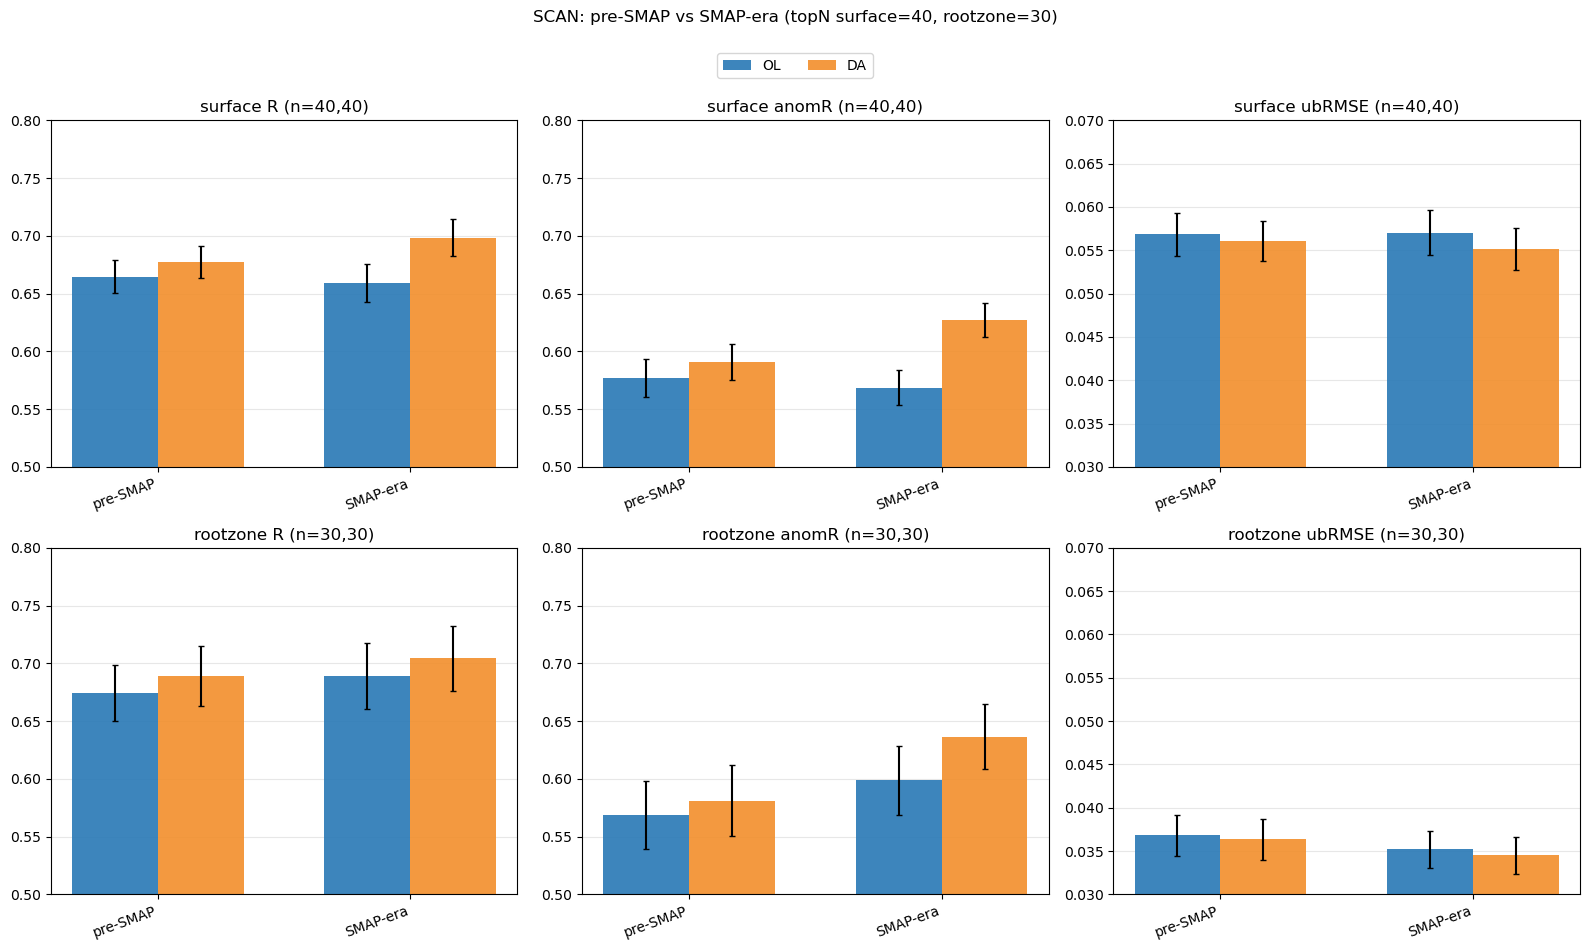

In [69]:
# -------------------------
# Bar charts: both depths, all metrics
# -------------------------
range_names = [r[0] for r in RANGES]
metric_order = ["R", "anomR", "ubRMSE"]

fig, axs = plt.subplots(2, 3, figsize=(16, 9), sharex=False)
width = 0.34
x = np.arange(len(range_names))
colors = {"OL": "#2878B5", "DA": "#F28E2B"}

for d in [0, 1]:
    for j, metric in enumerate(metric_order):
        ax = axs[d, j]
        for i, exp in enumerate(EXP_ORDER):
            sub = summary_df[
                (summary_df["depth"] == d)
                & (summary_df["metric"] == metric)
                & (summary_df["experiment"] == exp)
            ].set_index("range").reindex(range_names)

            y = sub["mean"].to_numpy(dtype=float)
            yerr = sub["sem"].to_numpy(dtype=float)

            ax.bar(
                x + (i - 0.5) * width,
                y,
                width=width,
                yerr=yerr,
                capsize=2,
                alpha=0.9,
                color=colors.get(exp, None),
                label=exp if (d == 0 and j == 0) else None,
            )

        n_text = []
        for r_name in range_names:
            nvals = summary_df[
                (summary_df["depth"] == d)
                & (summary_df["metric"] == metric)
                & (summary_df["range"] == r_name)
            ]["n"].to_numpy(dtype=int)
            n_text.append(str(int(np.nanmin(nvals))) if nvals.size else "0")

        ax.set_title(f"{DEPTH_NAMES[d]} {metric} (n={','.join(n_text)})")
        ax.set_xticks(x)
        ax.set_xticklabels(range_names, rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.5, 0.8)
        elif metric == "ubRMSE":
            ax.set_ylim(0.03, 0.07)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(EXP_ORDER), bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f"{NETWORK}: pre-SMAP vs SMAP-era (topN surface={TOP_N_SITES_BY_DEPTH.get(0,40)}, rootzone={TOP_N_SITES_BY_DEPTH.get(1,40)})", y=1.05)
plt.tight_layout()
plt.show()


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

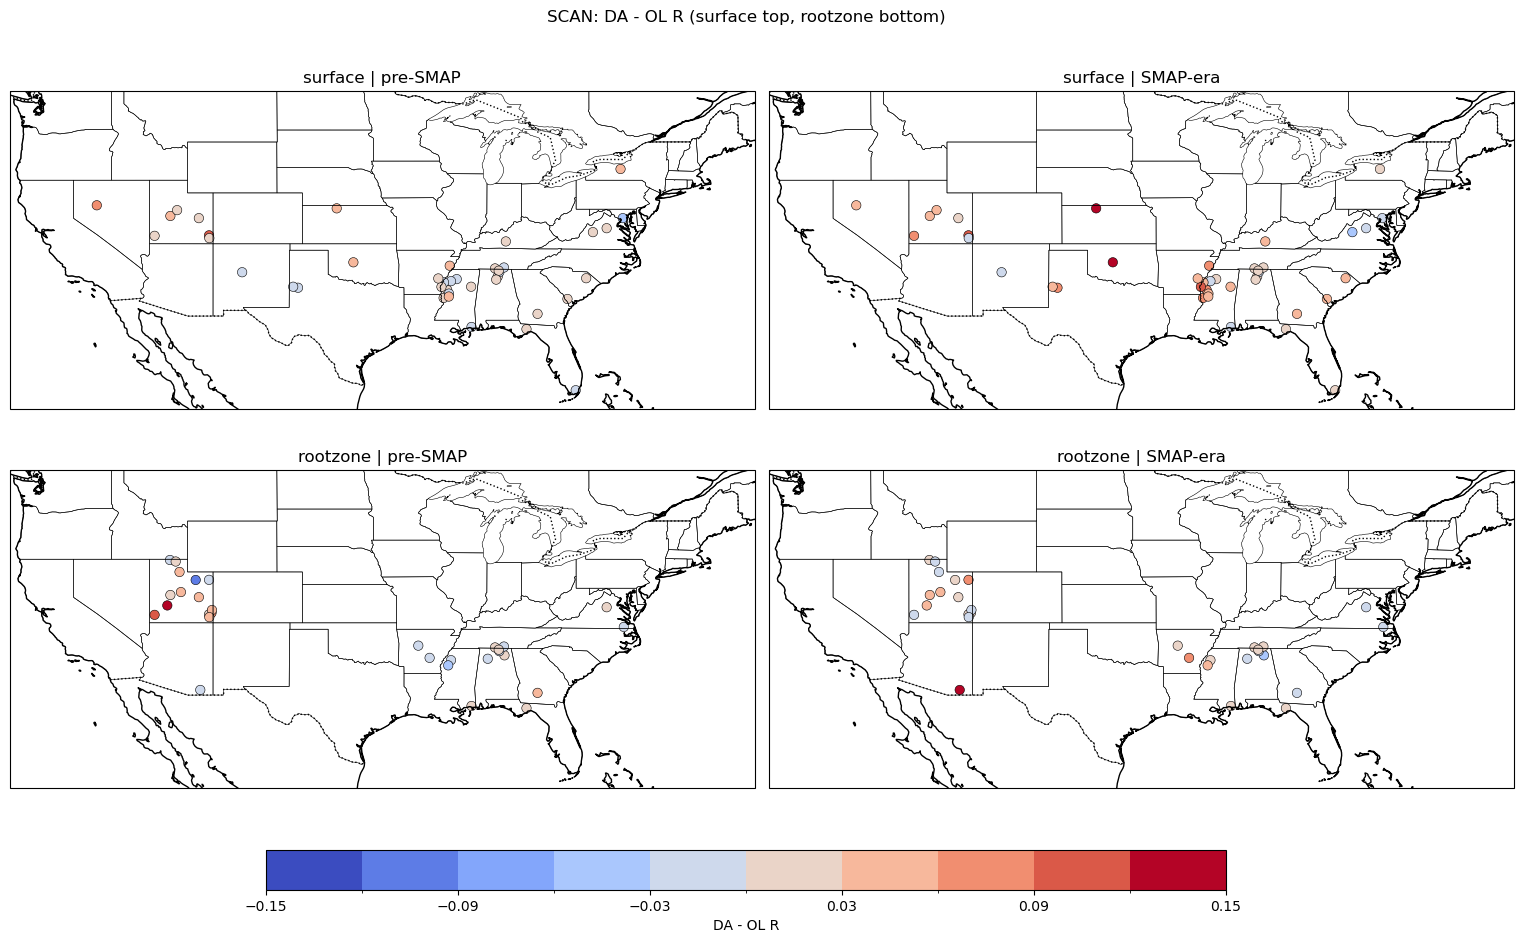

In [70]:
# -------------------------
# Map: DA - OL in 2x2 (surface/rootzone x pre-SMAP/SMAP-era)
# -------------------------
from matplotlib.colors import BoundaryNorm

if MAP_METRIC not in ["R", "anomR", "ubRMSE"]:
    raise ValueError(f"MAP_METRIC={MAP_METRIC} is invalid")
if len(RANGES) < 2:
    raise RuntimeError("Need at least two ranges for the 2x2 map")
if meta is None:
    raise RuntimeError("No metadata available for mapping")

depth_order = [0, 1]  # top row: surface, bottom row: rootzone
range_names = [RANGES[0][0], RANGES[1][0]]  # left: pre-SMAP, right: SMAP-era

lat_all = np.array(meta["lat"], dtype=float)
lon_all = np.array(meta["lon"], dtype=float)

# gather deltas for each panel and compute shared color scale
panel_payload = {}
all_vals_list = []

for depth in depth_order:
    for r_name in range_names:
        sub = stats_df[(stats_df["depth"] == depth) & (stats_df["range"] == r_name)].copy()
        ol = sub[sub["experiment"] == "OL"][["site", MAP_METRIC]].set_index("site")
        da = sub[sub["experiment"] == "DA"][["site", MAP_METRIC]].set_index("site")

        common_sites = sorted(set(ol.index).intersection(set(da.index)))
        if len(common_sites) == 0:
            panel_payload[(depth, r_name)] = {
                "lon": np.array([]),
                "lat": np.array([]),
                "delta": np.array([]),
            }
            continue

        delta = da.loc[common_sites, MAP_METRIC] - ol.loc[common_sites, MAP_METRIC]

        site_arr = np.array(common_sites, dtype=int)
        valid_geo = np.isfinite(lat_all[site_arr]) & np.isfinite(lon_all[site_arr])
        site_plot = site_arr[valid_geo]

        dvals = delta.loc[site_plot].to_numpy(dtype=float) if site_plot.size else np.array([])
        panel_payload[(depth, r_name)] = {
            "lon": lon_all[site_plot] if site_plot.size else np.array([]),
            "lat": lat_all[site_plot] if site_plot.size else np.array([]),
            "delta": dvals,
        }
        if dvals.size:
            all_vals_list.append(dvals)

# fixed shared color limits for all panels
vmax = 0.15

# segmented colorbar shared across all panels
n_bins = 10
levels = np.linspace(-vmax, vmax, n_bins + 1)
cmap = plt.get_cmap("coolwarm", len(levels) - 1)
norm = BoundaryNorm(levels, cmap.N)

if HAS_CARTOPY:
    fig, axs = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={"projection": ccrs.PlateCarree()}, sharex=True, sharey=True)
else:
    fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)

fig.subplots_adjust(left=0.04, right=0.98, top=0.90, bottom=0.16, wspace=0.02, hspace=0.05)

sc_last = None
for i, depth in enumerate(depth_order):
    for j, r_name in enumerate(range_names):
        ax = axs[i, j]
        pld = panel_payload[(depth, r_name)]

        if HAS_CARTOPY:
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS, linestyle=":")
            try:
                ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.4)
            except Exception:
                pass
            ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

        if pld["delta"].size == 0:
            ax.set_title(f"{DEPTH_NAMES[depth]} | {r_name}: no plottable sites")
            if not HAS_CARTOPY:
                if i == 1:
                    ax.set_xlabel("Longitude")
                if j == 0:
                    ax.set_ylabel("Latitude")
                ax.grid(alpha=0.3)
            continue

        if HAS_CARTOPY:
            sc = ax.scatter(
                pld["lon"],
                pld["lat"],
                c=pld["delta"],
                cmap=cmap,
                norm=norm,
                s=46,
                edgecolor="k",
                linewidth=0.4,
                transform=ccrs.PlateCarree(),
            )
        else:
            sc = ax.scatter(
                pld["lon"],
                pld["lat"],
                c=pld["delta"],
                cmap=cmap,
                norm=norm,
                s=46,
                edgecolor="k",
                linewidth=0.4,
            )
            if i == 1:
                ax.set_xlabel("Longitude")
            if j == 0:
                ax.set_ylabel("Latitude")
            ax.grid(alpha=0.3)

        sc_last = sc
        ax.set_title(f"{DEPTH_NAMES[depth]} | {r_name}")

if sc_last is not None:
    cax = fig.add_axes([0.20, 0.08, 0.60, 0.04])
    cbar = fig.colorbar(sc_last, cax=cax, orientation="horizontal", ticks=levels[::2], boundaries=levels)
    cbar.set_label(f"DA - OL {MAP_METRIC}")

fig.suptitle(f"{NETWORK}: DA - OL {MAP_METRIC} (surface top, rootzone bottom)", y=0.96)
plt.show()


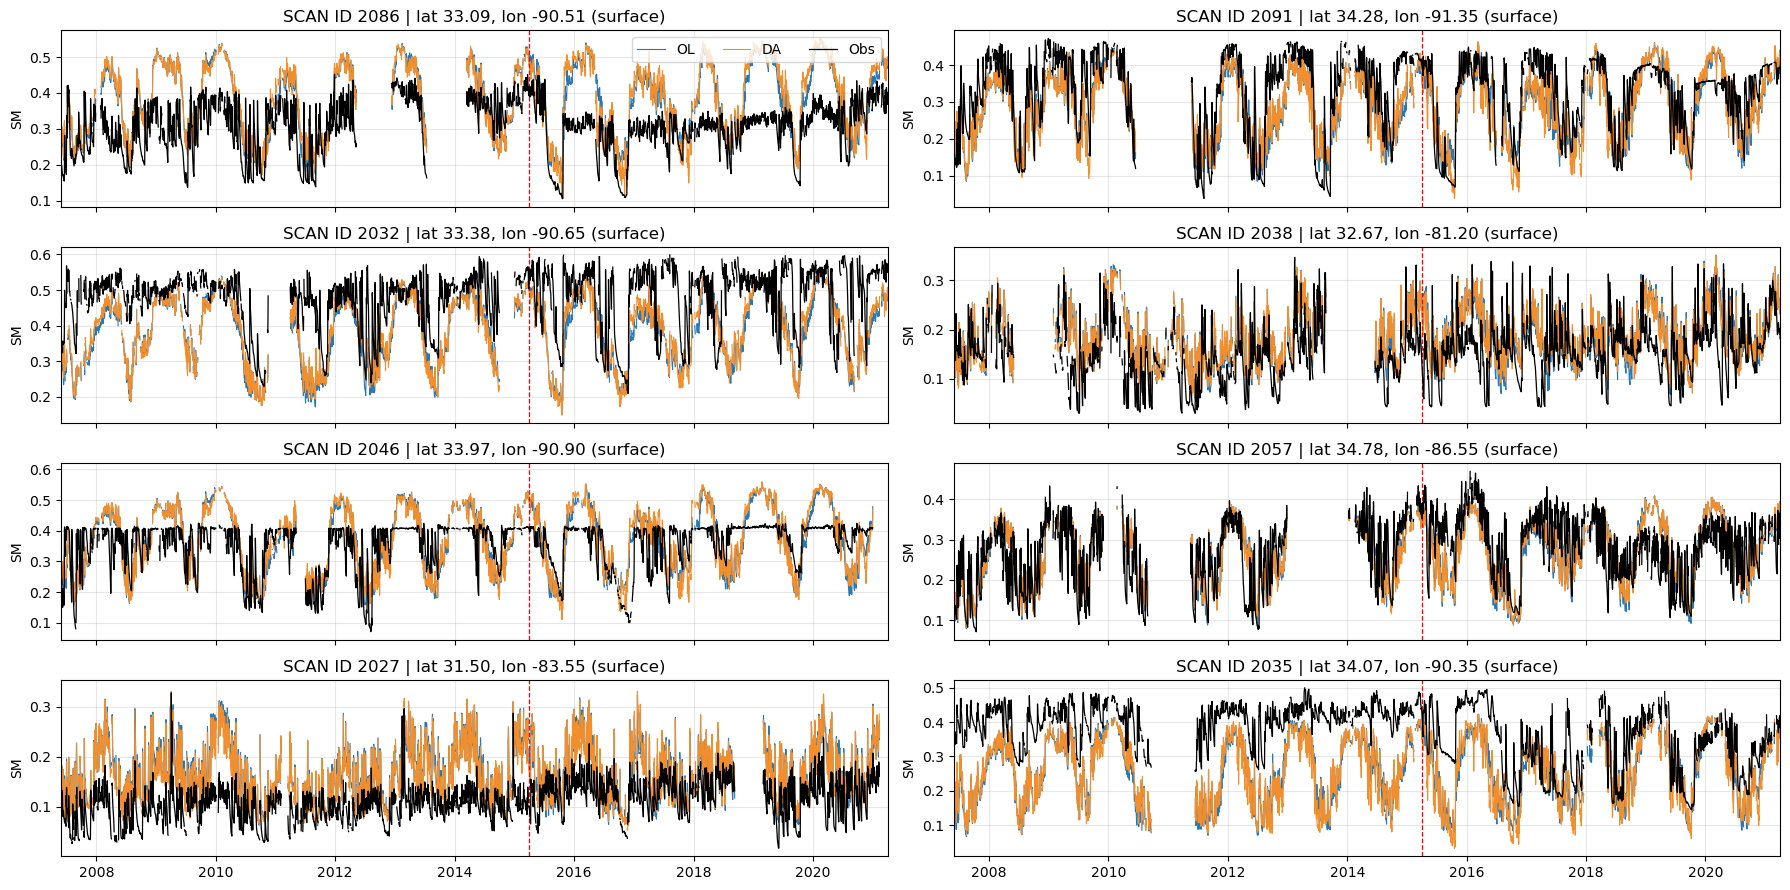

In [71]:
# -------------------------
# Time series: OL, DA, Obs for selected sites
# -------------------------
if TS_DEPTH not in [0, 1]:
    raise ValueError("TS_DEPTH must be 0 or 1")

if TS_SITE_IDS is None:
    ts_sites = selected_sites[TS_DEPTH][:TS_MAX_SITES]
else:
    ts_sites = [int(s) for s in TS_SITE_IDS]

if len(ts_sites) == 0:
    raise RuntimeError("No sites selected for time-series plotting")

# fixed 4x2 layout for presentation
nrows, ncols = 4, 2
max_panels = nrows * ncols
if len(ts_sites) > max_panels:
    print(f"Using first {max_panels} sites out of {len(ts_sites)} requested.")
    ts_sites = ts_sites[:max_panels]

fig, axs = plt.subplots(nrows, ncols, figsize=(18, 9), sharex=True)
axs_flat = axs.ravel()

period_bounds = [(dt.datetime.fromisoformat(s0), dt.datetime.fromisoformat(s1), name) for name, s0, s1 in RANGES]

for i, site in enumerate(ts_sites):
    ax = axs_flat[i]
    ax.plot(timestamps, ldas_by_exp["OL"][:, TS_DEPTH, site], color="#2878B5", lw=0.8, label="OL")
    ax.plot(timestamps, ldas_by_exp["DA"][:, TS_DEPTH, site], color="#F28E2B", lw=0.8, label="DA")
    ax.plot(timestamps, obs[:, TS_DEPTH, site], color="k", lw=0.9, label="Obs", zorder=3)

    # mark period boundary
    if len(period_bounds) >= 2:
        ax.axvline(period_bounds[1][0], color="red", ls="--", lw=0.9)

    site_id = meta["ids"][site] if (meta is not None and "ids" in meta and site < len(meta["ids"])) else "NA"
    site_lat = float(meta["lat"][site]) if (meta is not None and "lat" in meta and site < len(meta["lat"])) else np.nan
    site_lon = float(meta["lon"][site]) if (meta is not None and "lon" in meta and site < len(meta["lon"])) else np.nan
    lat_txt = f"{site_lat:.2f}" if np.isfinite(site_lat) else "NA"
    lon_txt = f"{site_lon:.2f}" if np.isfinite(site_lon) else "NA"
    ax.set_title(f"{NETWORK} ID {site_id} | lat {lat_txt}, lon {lon_txt} ({DEPTH_NAMES[TS_DEPTH]})")
    ax.set_ylabel("SM")
    ax.grid(alpha=0.3)

# hide any unused panels
for j in range(len(ts_sites), max_panels):
    axs_flat[j].set_visible(False)

start_all = min([b[0] for b in period_bounds])
end_all = max([b[1] for b in period_bounds])
for i in range(len(ts_sites)):
    axs_flat[i].set_xlim(start_all, end_all)

axs_flat[0].legend(loc="upper right", ncol=3)
plt.tight_layout()
plt.show()


In [72]:
# -------------------------
# Save selected tables and stats
# -------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

top_tag = f"topS{TOP_N_SITES_BY_DEPTH.get(0,40)}_R{TOP_N_SITES_BY_DEPTH.get(1,40)}"
selected_out = OUT_DIR / f"{NETWORK}_selected_sites_preSMAP_SMAPera_{top_tag}.csv"
stats_out = OUT_DIR / f"{NETWORK}_stats_preSMAP_SMAPera_{top_tag}.csv"
summary_out = OUT_DIR / f"{NETWORK}_summary_preSMAP_SMAPera_{top_tag}.csv"
qc_surf_out = OUT_DIR / f"{NETWORK}_qc_surface_preSMAP_SMAPera.csv"
qc_rz_out = OUT_DIR / f"{NETWORK}_qc_rootzone_preSMAP_SMAPera.csv"

selected_summary.to_csv(selected_out, index=False)
stats_df.to_csv(stats_out, index=False)
summary_df.to_csv(summary_out, index=False)
qc_by_depth[0].to_csv(qc_surf_out, index=False)
qc_by_depth[1].to_csv(qc_rz_out, index=False)

print(f"Wrote: {selected_out}")
print(f"Wrote: {stats_out}")
print(f"Wrote: {summary_out}")
print(f"Wrote: {qc_surf_out}")
print(f"Wrote: {qc_rz_out}")


Wrote: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/SCAN_selected_sites_preSMAP_SMAPera_topS40_R30.csv
Wrote: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/SCAN_stats_preSMAP_SMAPera_topS40_R30.csv
Wrote: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/SCAN_summary_preSMAP_SMAPera_topS40_R30.csv
Wrote: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/SCAN_qc_surface_preSMAP_SMAPera.csv
Wrote: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/SCAN_qc_rootzone_preSMAP_SMAPera.csv


## OL Fixed-Site Sensitivity: pre-SMAP + two SMAP-era windows

This block selects sites using **pre-SMAP + short SMAP-era** coverage/QC, then computes **OL-only** statistics for three periods using the same selected sites.


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/3861927609.py:69: RuntimeWarning: Mean of empty slice
  mean_short = float(np.nanmean(series[range_masks_ol[short_name]]))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/3861927609.py:73: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_short = np.nanvar(series[range_masks_ol[short_name]])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/3861927609.py:68: RuntimeWarning: Mean of empty slice
  mean_pre = float(np.nanmean(series[range_masks_ol[pre_name]]))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/3861927609.py:72: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_pre = np.nanvar(series[range_masks_ol[pre_name]])


Depth 0 (surface): selected 40 sites (requested 40) using pre-SMAP + short-SMAP criteria


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/3861927609.py:68: RuntimeWarning: Mean of empty slice
  mean_pre = float(np.nanmean(series[range_masks_ol[pre_name]]))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/3861927609.py:72: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_pre = np.nanvar(series[range_masks_ol[pre_name]])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/3861927609.py:69: RuntimeWarning: Mean of empty slice
  mean_short = float(np.nanmean(series[range_masks_ol[short_name]]))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/3861927609.py:73: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_short = np.nanvar(series[range_masks_ol[short_name]])


Depth 1 (rootzone): selected 30 sites (requested 30) using pre-SMAP + short-SMAP criteria
Computed OL fixed-site comparison stats.


,site,depth,period_min_count,period_total_count,score,coverage_min,flagged
0,67,0,2100,4363,3,0,True
1,72,0,2071,4405,2,0,True
2,25,0,2026,4390,3,0,True
3,31,0,1990,4137,3,0,True
4,37,0,1970,4487,2,0,True
5,46,0,1930,3920,2,0,True
6,21,0,1895,4522,2,103,True
7,28,0,1891,4281,3,0,True
8,62,0,1871,4155,2,0,True
9,51,0,1866,3748,2,0,True


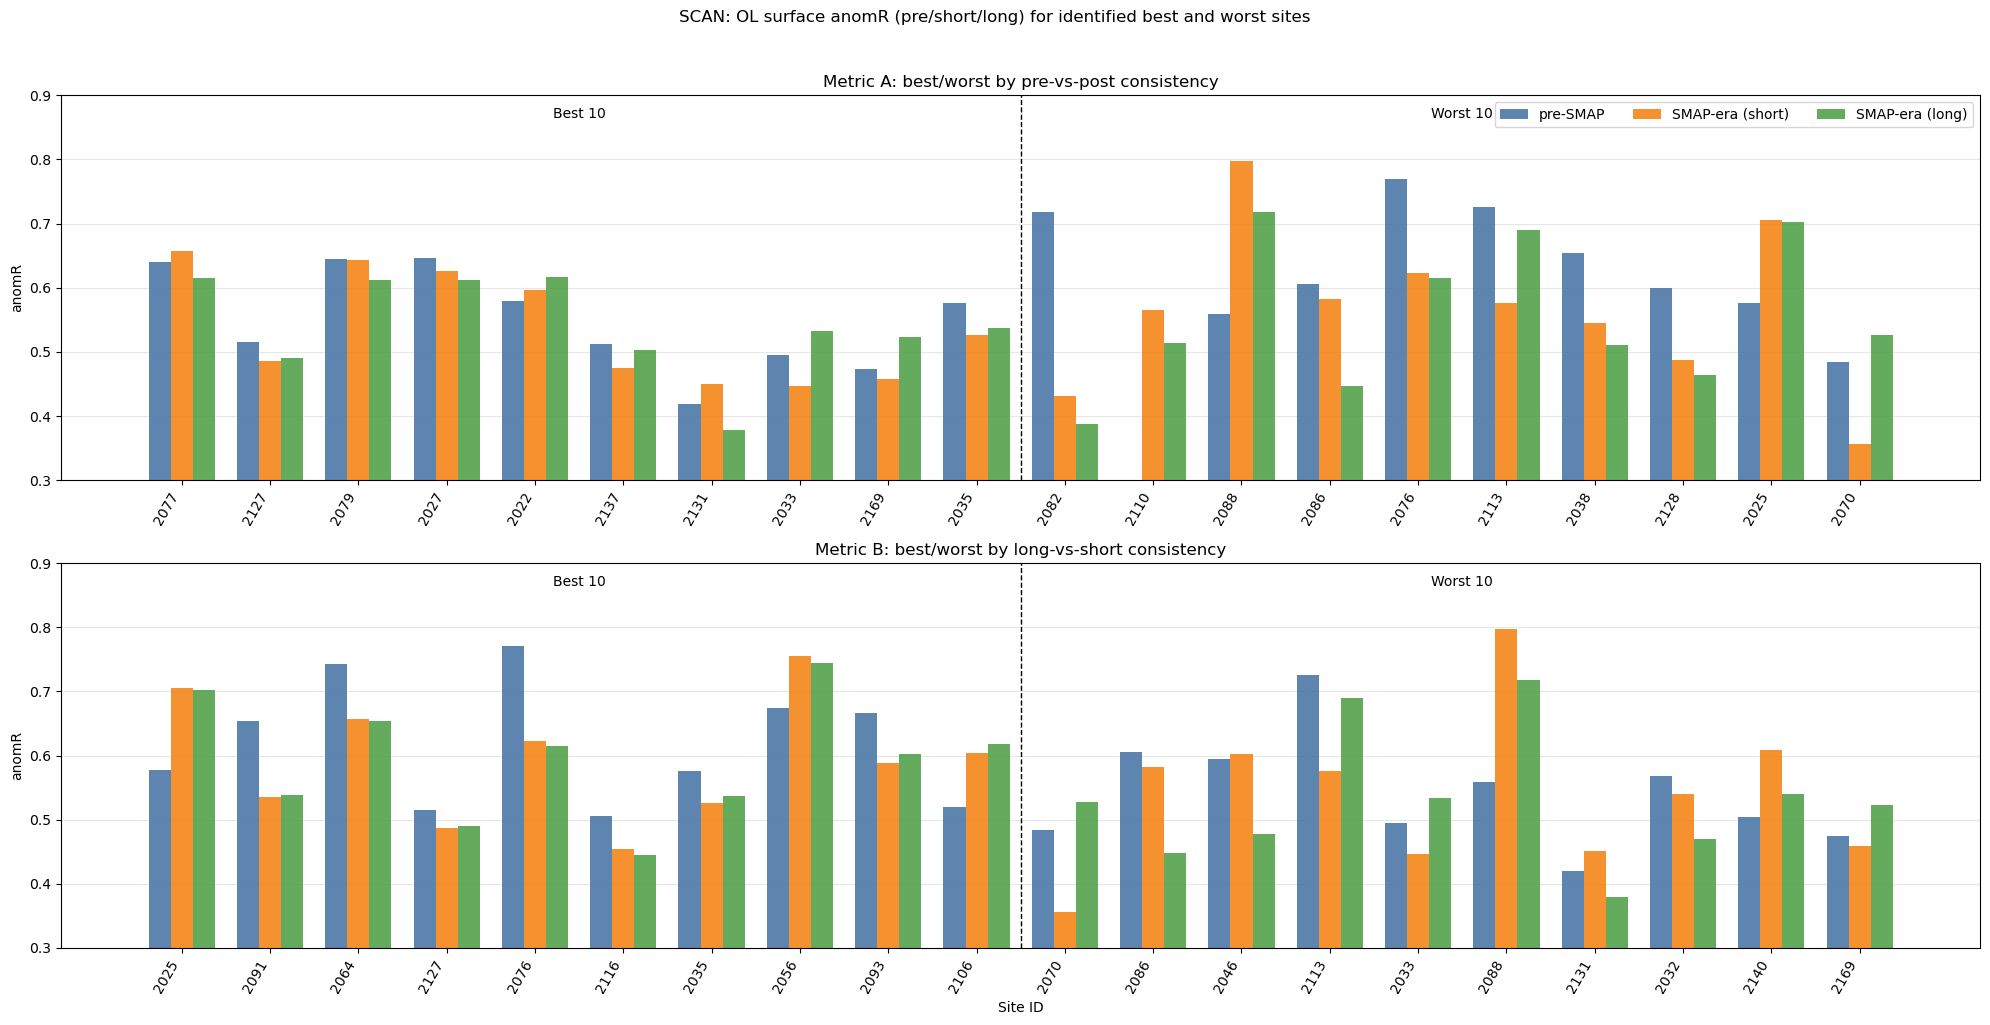

In [73]:
# -------------------------
# Fixed-site OL comparison setup
# -------------------------
RANGES_OL_COMPARE = [
    ("pre-SMAP", "2007-06-01", "2015-03-31"),
    ("SMAP-era (short)", "2015-04-01", "2021-04-01"),
    ("SMAP-era (long)", "2015-04-01", "2024-06-30"),
]

if "obs" not in globals() or "ldas_by_exp" not in globals() or "timestamps" not in globals():
    raise RuntimeError("Run the upstream load/stats cells first.")
if "OL" not in ldas_by_exp:
    raise RuntimeError("OL experiment not found in ldas_by_exp")

ol_sm = ldas_by_exp["OL"]
n_time, n_depth, n_site = obs.shape

# masks for the 3 comparison ranges
range_masks_ol = {}
for name, s0, s1 in RANGES_OL_COMPARE:
    t0 = dt.datetime.fromisoformat(s0)
    t1 = dt.datetime.fromisoformat(s1)
    range_masks_ol[name] = (timestamps >= t0) & (timestamps <= t1)

pre_name = "pre-SMAP"
short_name = "SMAP-era (short)"
long_name = "SMAP-era (long)"

if pre_name not in range_masks_ol or short_name not in range_masks_ol or long_name not in range_masks_ol:
    raise RuntimeError("Expected pre/short/long range names are missing")

try:
    from scipy.stats import ks_2samp
except Exception:
    ks_2samp = None

years = np.array([t.year for t in timestamps], dtype=int)
months = np.array([t.month for t in timestamps], dtype=int)

# 1) Build short-era-based site selection (same style as notebook QC/ranking)
short_qc_by_depth = {}
selected_short_sites = {}

for depth in [0, 1]:
    min_days = MIN_DAYS_PER_RANGE_SURF if depth == 0 else MIN_DAYS_PER_RANGE_RZ
    rows = []

    for site in range(n_site):
        series = obs[:, depth, site].astype(float)
        if np.all(np.isnan(series)):
            continue

        df = pd.DataFrame({"year": years, "val": series})
        cov = df.groupby("year")["val"].apply(lambda s: np.isfinite(s).sum())
        if cov.size < QC_MIN_YEARS:
            continue

        cov_med = float(np.median(cov))
        cov_min = int(np.min(cov))
        coverage_drop = cov_min < cov_med * (1.0 - COVERAGE_DROP_FRAC)

        pre_cnt = int(np.isfinite(series[range_masks_ol[pre_name]]).sum())
        short_cnt = int(np.isfinite(series[range_masks_ol[short_name]]).sum())
        coverage_period_fail = (pre_cnt < min_days) or (short_cnt < min_days)
        period_min_count = min(pre_cnt, short_cnt)
        period_total_count = pre_cnt + short_cnt

        mean_pre = float(np.nanmean(series[range_masks_ol[pre_name]]))
        mean_short = float(np.nanmean(series[range_masks_ol[short_name]]))
        step_change = abs(mean_short - mean_pre) if np.isfinite(mean_pre) and np.isfinite(mean_short) else np.nan

        var_pre = np.nanvar(series[range_masks_ol[pre_name]])
        var_short = np.nanvar(series[range_masks_ol[short_name]])
        var_ratio = (var_short / var_pre) if (var_pre > 0 and np.isfinite(var_short)) else np.nan
        var_drift = np.isfinite(var_ratio) and ((var_ratio > VAR_DRIFT_FACTOR) or (var_ratio < 1.0 / VAR_DRIFT_FACTOR))

        if ks_2samp is not None:
            v1 = series[range_masks_ol[pre_name] & np.isfinite(series)]
            v2 = series[range_masks_ol[short_name] & np.isfinite(series)]
            ks_p = float(ks_2samp(v1, v2).pvalue) if (v1.size > 10 and v2.size > 10) else np.nan
        else:
            ks_p = np.nan
        dist_shift = np.isfinite(ks_p) and (ks_p < KS_PVAL_THRESH)

        clim_pre = pd.DataFrame({"m": months[range_masks_ol[pre_name]], "v": series[range_masks_ol[pre_name]]}).groupby("m")["v"].mean()
        clim_short = pd.DataFrame({"m": months[range_masks_ol[short_name]], "v": series[range_masks_ol[short_name]]}).groupby("m")["v"].mean()
        common_m = clim_pre.index.intersection(clim_short.index)
        if common_m.size >= 6:
            c1 = clim_pre.loc[common_m].to_numpy()
            c2 = clim_short.loc[common_m].to_numpy()
            seasonal_corr = float(np.corrcoef(c1, c2)[0, 1]) if (np.all(np.isfinite(c1)) and np.all(np.isfinite(c2))) else np.nan
        else:
            seasonal_corr = np.nan
        seasonal_shift = np.isfinite(seasonal_corr) and (seasonal_corr < SEASONAL_CORR_MIN)

        rows.append({
            "site": int(site),
            "depth": int(depth),
            "period_min_count": int(period_min_count),
            "period_total_count": int(period_total_count),
            "coverage_min": int(cov_min),
            "coverage_med": float(cov_med),
            "coverage_drop": bool(coverage_drop),
            "coverage_period_fail": bool(coverage_period_fail),
            "step_change_mean": float(step_change) if np.isfinite(step_change) else np.nan,
            "var_ratio": float(var_ratio) if np.isfinite(var_ratio) else np.nan,
            "var_drift": bool(var_drift),
            "ks_p": float(ks_p) if np.isfinite(ks_p) else np.nan,
            "dist_shift": bool(dist_shift),
            "seasonal_corr": float(seasonal_corr) if np.isfinite(seasonal_corr) else np.nan,
            "seasonal_shift": bool(seasonal_shift),
        })

    qdf = pd.DataFrame(rows)
    if qdf.empty:
        raise RuntimeError(f"No QC rows found for depth={depth}")

    qdf["flagged"] = qdf[["coverage_drop", "var_drift", "dist_shift", "seasonal_shift"]].any(axis=1)
    qdf["score"] = (
        qdf["coverage_drop"].astype(int)
        + 5 * qdf["coverage_period_fail"].astype(int)
        + qdf["var_drift"].astype(int)
        + qdf["dist_shift"].astype(int)
        + qdf["seasonal_shift"].astype(int)
    )

    qdf = qdf.sort_values(
        ["period_min_count", "period_total_count", "score", "coverage_period_fail", "coverage_min"],
        ascending=[False, False, True, True, False],
    ).reset_index(drop=True)

    candidates = qdf[~qdf["coverage_period_fail"]].copy()
    if candidates.empty:
        candidates = qdf.copy()

    top_n = int(TOP_N_SITES_BY_DEPTH.get(depth, 40))
    selected = candidates.head(top_n).copy()

    short_qc_by_depth[depth] = qdf
    selected_short_sites[depth] = selected["site"].astype(int).tolist()

    print(
        f"Depth {depth} ({DEPTH_NAMES[depth]}): selected {len(selected_short_sites[depth])} sites "
        f"(requested {top_n}) using pre-SMAP + short-SMAP criteria"
    )

selected_short_summary = pd.concat(
    [
        short_qc_by_depth[d].set_index("site").loc[selected_short_sites[d], ["depth", "period_min_count", "period_total_count", "score", "coverage_min", "flagged"]].reset_index()
        for d in [0, 1]
    ],
    axis=0,
).reset_index(drop=True)

# 2) Compute OL-only stats for pre + short + long windows on SAME selected sites
ol_fixed_records = []
for depth in [0, 1]:
    for site in selected_short_sites[depth]:
        for r_name, _, _ in RANGES_OL_COMPARE:
            mask = range_masks_ol[r_name]
            obs_rng = obs[mask, depth, site].astype(float)
            mod_rng = ol_sm[mask, depth, site].astype(float)

            mod_rng[np.isnan(obs_rng)] = np.nan
            obs_rng[np.isnan(mod_rng)] = np.nan

            tmp = np.column_stack([obs_rng, mod_rng])
            st = get_validation_stats(
                tmp,
                AC=True,
                complete=True,
                ref_col=1,
                select_cols=[1, 2],
                Nmin=NMIN,
            )

            ub_rmse = np.sqrt(max(st["ubMSE"], 0.0)) if np.isfinite(st["ubMSE"]) else np.nan

            obs_anom = compute_anom(obs_rng, doy_vec[mask], Nmin_day=NMIN_DAY)
            mod_anom = compute_anom(mod_rng, doy_vec[mask], Nmin_day=NMIN_DAY)
            st_anom = get_validation_stats(
                np.column_stack([obs_anom, mod_anom]),
                AC=True,
                complete=True,
                ref_col=1,
                select_cols=[1, 2],
                Nmin=NMIN,
            )

            ol_fixed_records.append({
                "site": int(site),
                "depth": int(depth),
                "range": r_name,
                "N_pairs": float(st["N_pairs"]) if np.isfinite(st["N_pairs"]) else np.nan,
                "R": float(st["R"]) if np.isfinite(st["R"]) else np.nan,
                "anomR": float(st_anom["R"]) if np.isfinite(st_anom["R"]) else np.nan,
                "ubRMSE": float(ub_rmse) if np.isfinite(ub_rmse) else np.nan,
            })

ol_fixed_stats = pd.DataFrame(ol_fixed_records)

ol_fixed_summary_rows = []
for depth in [0, 1]:
    for r_name, _, _ in RANGES_OL_COMPARE:
        sub = ol_fixed_stats[(ol_fixed_stats["depth"] == depth) & (ol_fixed_stats["range"] == r_name)]
        for metric in ["R", "anomR", "ubRMSE"]:
            vals = sub[metric].to_numpy(dtype=float)
            n = int(np.sum(np.isfinite(vals)))
            mean = float(np.nanmean(vals)) if n > 0 else np.nan
            sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
            ol_fixed_summary_rows.append({
                "depth": depth,
                "range": r_name,
                "metric": metric,
                "n": n,
                "mean": mean,
                "sem": sem,
            })

ol_fixed_summary = pd.DataFrame(ol_fixed_summary_rows)

print("Computed OL fixed-site comparison stats.")
display(selected_short_summary.head(10))

# -------------------------
# Bar chart for identified best/worst consistency sites (surface, anomR only)
# -------------------------
SURF_DEPTH = 0
range_cols = ["pre-SMAP", "SMAP-era (short)", "SMAP-era (long)"]

surf_piv = (
    ol_fixed_stats[
        (ol_fixed_stats["depth"] == SURF_DEPTH)
        & (ol_fixed_stats["range"].isin(range_cols))
    ]
    .pivot_table(index="site", columns="range", values="anomR", aggfunc="first")
    .reindex(columns=range_cols)
)

# derive ranking metrics (same definitions used in later ranking cell)
delta_df = surf_piv.copy()
delta_df["d_short_pre"] = delta_df["SMAP-era (short)"] - delta_df["pre-SMAP"]
delta_df["d_long_pre"] = delta_df["SMAP-era (long)"] - delta_df["pre-SMAP"]
delta_df["d_long_short"] = delta_df["SMAP-era (long)"] - delta_df["SMAP-era (short)"]
delta_df["metric_pre_consistency"] = delta_df[["d_short_pre", "d_long_pre"]].abs().max(axis=1)
delta_df["metric_extension_consistency"] = delta_df["d_long_short"].abs()

rank_A = delta_df.sort_values("metric_pre_consistency").copy()
rank_B = delta_df.sort_values("metric_extension_consistency").copy()

best10_A = rank_A.index[:10].tolist()
worst10_A = rank_A.index[-10:].tolist()[::-1]
sites_A = best10_A + worst10_A

best10_B = rank_B.index[:10].tolist()
worst10_B = rank_B.index[-10:].tolist()[::-1]
sites_B = best10_B + worst10_B


def _site_id(i_site):
    if meta is not None and "ids" in meta and i_site < len(meta["ids"]):
        return str(meta["ids"][i_site])
    return str(i_site)


def _plot_3bar(ax, site_list, title):
    if len(site_list) == 0:
        ax.set_title(f"{title}: no sites")
        ax.axis("off")
        return

    sub = surf_piv.reindex(site_list)
    x = np.arange(len(site_list))
    bw = 0.25
    colors = ["#4C78A8", "#F58518", "#54A24B"]

    for j, rname in enumerate(range_cols):
        y = sub[rname].to_numpy(dtype=float)
        ax.bar(x + (j - 1) * bw, y, width=bw, color=colors[j], label=rname, alpha=0.9)

    labels = [_site_id(i) for i in site_list]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_ylim(0.3, 0.9)
    ax.set_ylabel("anomR")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

    if len(site_list) > 10:
        ax.axvline(9.5, color="k", ls="--", lw=1)
        y_top = ax.get_ylim()[1]
        ax.text(4.5, y_top * 0.98, "Best 10", ha="center", va="top")
        ax.text(14.5, y_top * 0.98, "Worst 10", ha="center", va="top")


fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharex=False)
_plot_3bar(axs[0], sites_A, "Metric A: best/worst by pre-vs-post consistency")
_plot_3bar(axs[1], sites_B, "Metric B: best/worst by long-vs-short consistency")

axs[0].legend(loc="upper right", ncol=3)
axs[1].set_xlabel("Site ID")
fig.suptitle(f"{NETWORK}: OL surface anomR (pre/short/long) for identified best and worst sites", y=1.02)
plt.tight_layout()
plt.show()


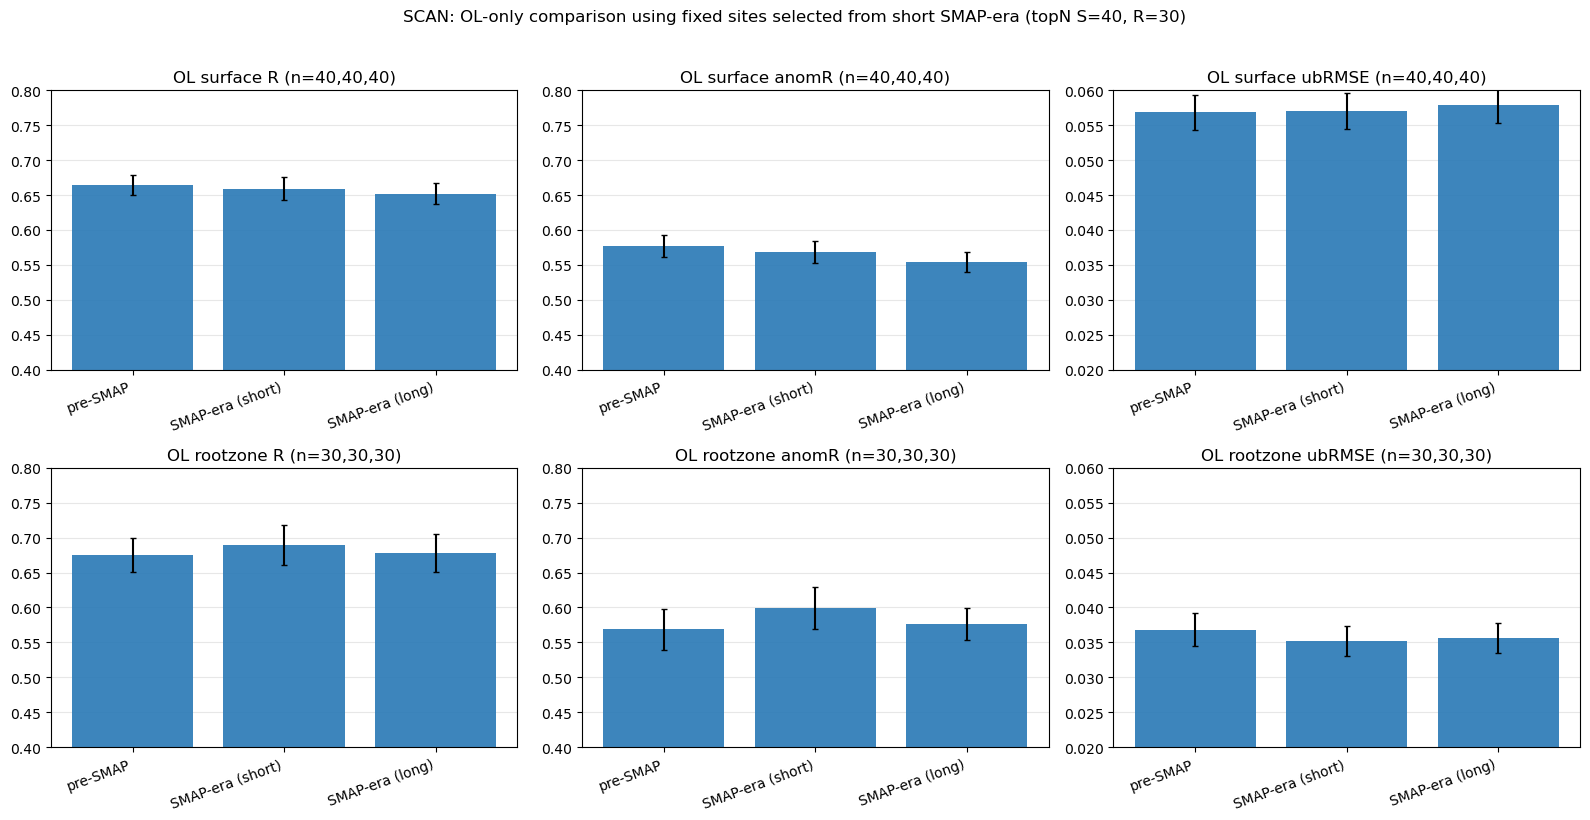

In [74]:
# -------------------------
# Plot: OL-only pre + short-SMAP + long-SMAP using same selected sites
# -------------------------
range_order = [r[0] for r in RANGES_OL_COMPARE]
metric_order = ["R", "anomR", "ubRMSE"]

fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
x = np.arange(len(range_order))

for d in [0, 1]:
    for j, metric in enumerate(metric_order):
        ax = axs[d, j]
        sub = ol_fixed_summary[(ol_fixed_summary["depth"] == d) & (ol_fixed_summary["metric"] == metric)].set_index("range").reindex(range_order)

        y = sub["mean"].to_numpy(dtype=float)
        yerr = sub["sem"].to_numpy(dtype=float)

        ax.bar(x, y, yerr=yerr, color="#2878B5", alpha=0.9, capsize=2)

        n_text = [
            str(int(ol_fixed_summary[(ol_fixed_summary["depth"] == d) & (ol_fixed_summary["metric"] == metric) & (ol_fixed_summary["range"] == r)]["n"].iloc[0]))
            for r in range_order
        ]

        ax.set_title(f"OL {DEPTH_NAMES[d]} {metric} (n={','.join(n_text)})")
        ax.set_xticks(x)
        ax.set_xticklabels(range_order, rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.4, 0.8)
        elif metric == "ubRMSE":
            ax.set_ylim(0.02, 0.06)

fig.suptitle(
    f"{NETWORK}: OL-only comparison using fixed sites selected from short SMAP-era "
    f"(topN S={TOP_N_SITES_BY_DEPTH.get(0,40)}, R={TOP_N_SITES_BY_DEPTH.get(1,40)})",
    y=1.02,
)
plt.tight_layout()
plt.show()


### OL anomR by site (first 20) for pre / short / long windows


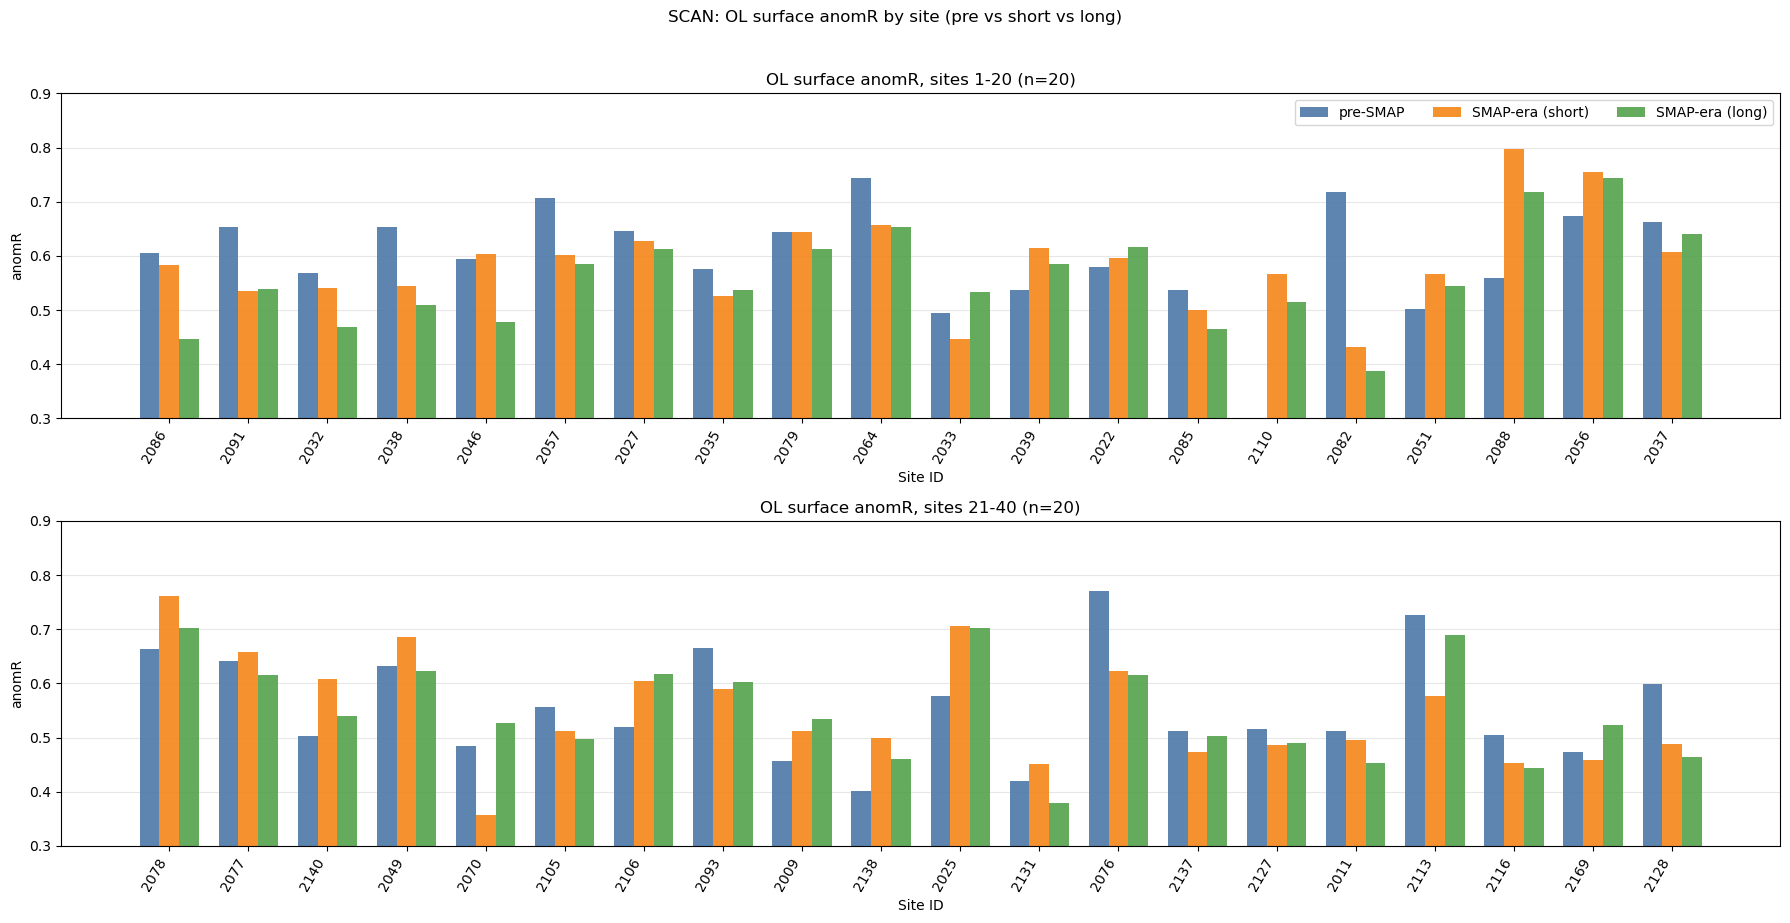

In [75]:
# -------------------------
# Individual-site view: OL anomR for pre/short/long windows (surface only)
# -------------------------
if "ol_fixed_stats" not in globals() or "selected_short_sites" not in globals():
    raise RuntimeError("Run the OL fixed-site comparison cells above first.")

RANGE_ORDER = ["pre-SMAP", "SMAP-era (short)", "SMAP-era (long)"]
SURF_DEPTH = 0
SITE_N_PER_PANEL = 20

surf_sites = selected_short_sites[SURF_DEPTH]
sites_top = surf_sites[:SITE_N_PER_PANEL]
sites_bottom = surf_sites[SITE_N_PER_PANEL:2 * SITE_N_PER_PANEL]

fig, axs = plt.subplots(2, 1, figsize=(18, 9), sharex=False)
bar_w = 0.25
colors = ["#4C78A8", "#F58518", "#54A24B"]

for ax, sites, panel_label in zip(
    axs,
    [sites_top, sites_bottom],
    ["sites 1-20", "sites 21-40"],
):
    if len(sites) == 0:
        ax.set_title(f"surface {panel_label}: no sites")
        ax.axis("off")
        continue

    sub = ol_fixed_stats[(ol_fixed_stats["depth"] == SURF_DEPTH) & (ol_fixed_stats["site"].isin(sites))].copy()
    piv = sub.pivot_table(index="site", columns="range", values="anomR", aggfunc="first")
    piv = piv.reindex(index=sites, columns=RANGE_ORDER)

    x = np.arange(len(sites))
    for j, r_name in enumerate(RANGE_ORDER):
        y = piv[r_name].to_numpy(dtype=float)
        ax.bar(x + (j - 1) * bar_w, y, width=bar_w, color=colors[j], label=r_name, alpha=0.9)

    id_labels = []
    for s in sites:
        if meta is not None and "ids" in meta and s < len(meta["ids"]):
            id_labels.append(str(meta["ids"][s]))
        else:
            id_labels.append(str(s))

    ax.set_xticks(x)
    ax.set_xticklabels(id_labels, rotation=60, ha="right")
    ax.set_ylim(0.3, 0.9)
    ax.set_ylabel("anomR")
    ax.set_title(f"OL surface anomR, {panel_label} (n={len(sites)})")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

axs[0].legend(loc="upper right", ncol=3)
axs[0].set_xlabel("Site ID")
axs[1].set_xlabel("Site ID")
fig.suptitle(f"{NETWORK}: OL surface anomR by site (pre vs short vs long)", y=1.02)
plt.tight_layout()
plt.show()


### Site Consistency Ranking (surface): pre/short+pre/long vs long/short

Top panel ranks sites by consistency against pre-SMAP (`d_short_pre` and `d_long_pre` together), and bottom panel ranks by extension-window sensitivity (`d_long_short`).


range,site_id,d_short_pre,d_long_pre,metric_pre_consistency
site,,,,
60,2077,0.016449,-0.025175,0.025175
90,2127,-0.029351,-0.025760,0.029351
62,2079,-0.001051,-0.032798,0.032798
21,2027,-0.019343,-0.033828,0.033828
16,2022,0.017513,0.036873,0.036873
100,2137,-0.038649,-0.010036,0.038649
94,2131,0.031286,-0.040192,0.040192
26,2033,-0.048542,0.038199,0.048542
132,2169,-0.015361,0.049874,0.049874


range,site_id,d_short_pre,d_long_pre,metric_pre_consistency
site,,,,
54,2070,-0.128124,0.042485,0.128124
19,2025,0.128223,0.125687,0.128223
91,2128,-0.112202,-0.136090,0.136090
31,2038,-0.108553,-0.143364,0.143364
84,2113,-0.150246,-0.036807,0.150246
59,2076,-0.147553,-0.154923,0.154923
67,2086,-0.023027,-0.158134,0.158134
69,2088,0.238249,0.158873,0.238249
82,2110,0.287524,0.235561,0.287524


range,site_id,d_long_short,metric_extension_consistency
site,,,
19,2025,-0.002536,0.002536
72,2091,0.002635,0.002635
51,2064,-0.003085,0.003085
90,2127,0.003591,0.003591
59,2076,-0.007370,0.007370
87,2116,-0.009007,0.009007
28,2035,0.011346,0.011346
45,2056,-0.011375,0.011375
74,2093,0.013426,0.013426


range,site_id,d_long_short,metric_extension_consistency
site,,,
132,2169,0.065235,0.065235
103,2140,-0.068021,0.068021
25,2032,-0.071326,0.071326
94,2131,-0.071477,0.071477
69,2088,-0.079376,0.079376
26,2033,0.086741,0.086741
84,2113,0.113438,0.113438
37,2046,-0.124730,0.124730
67,2086,-0.135107,0.135107


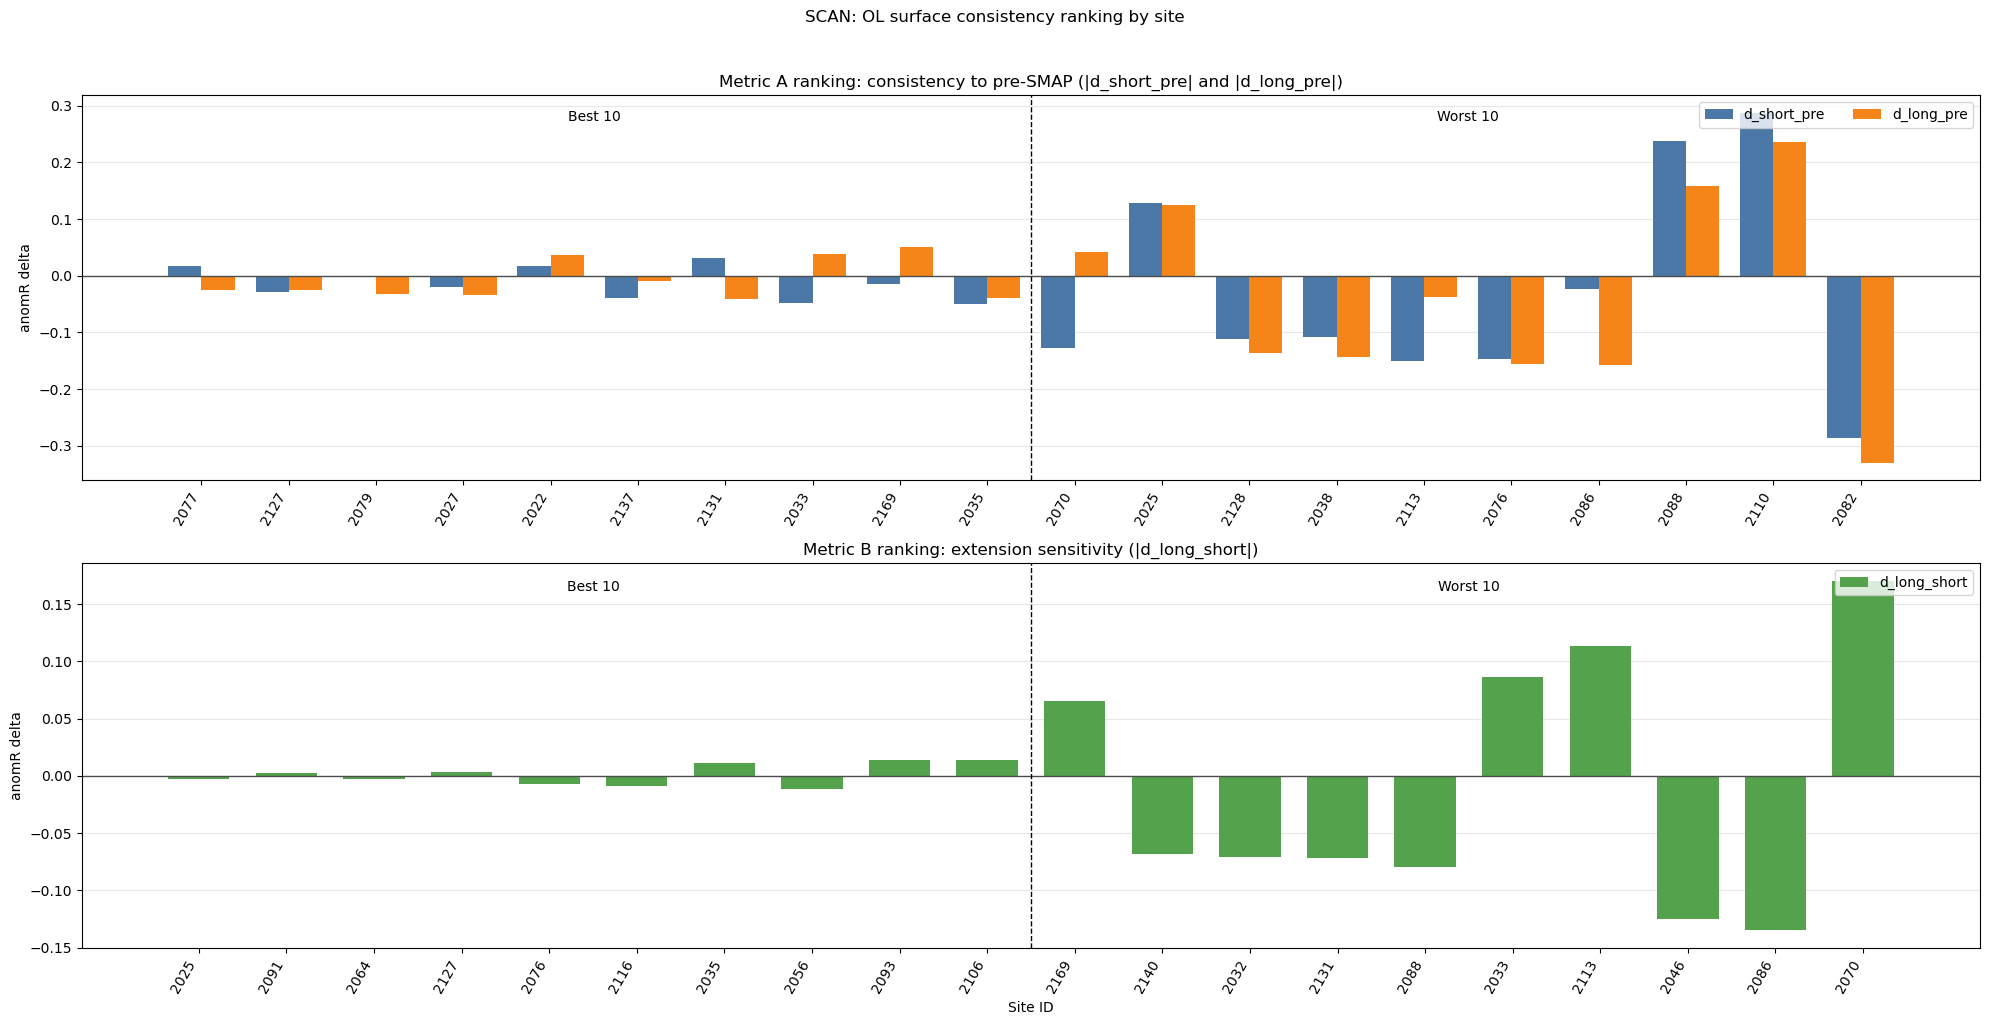

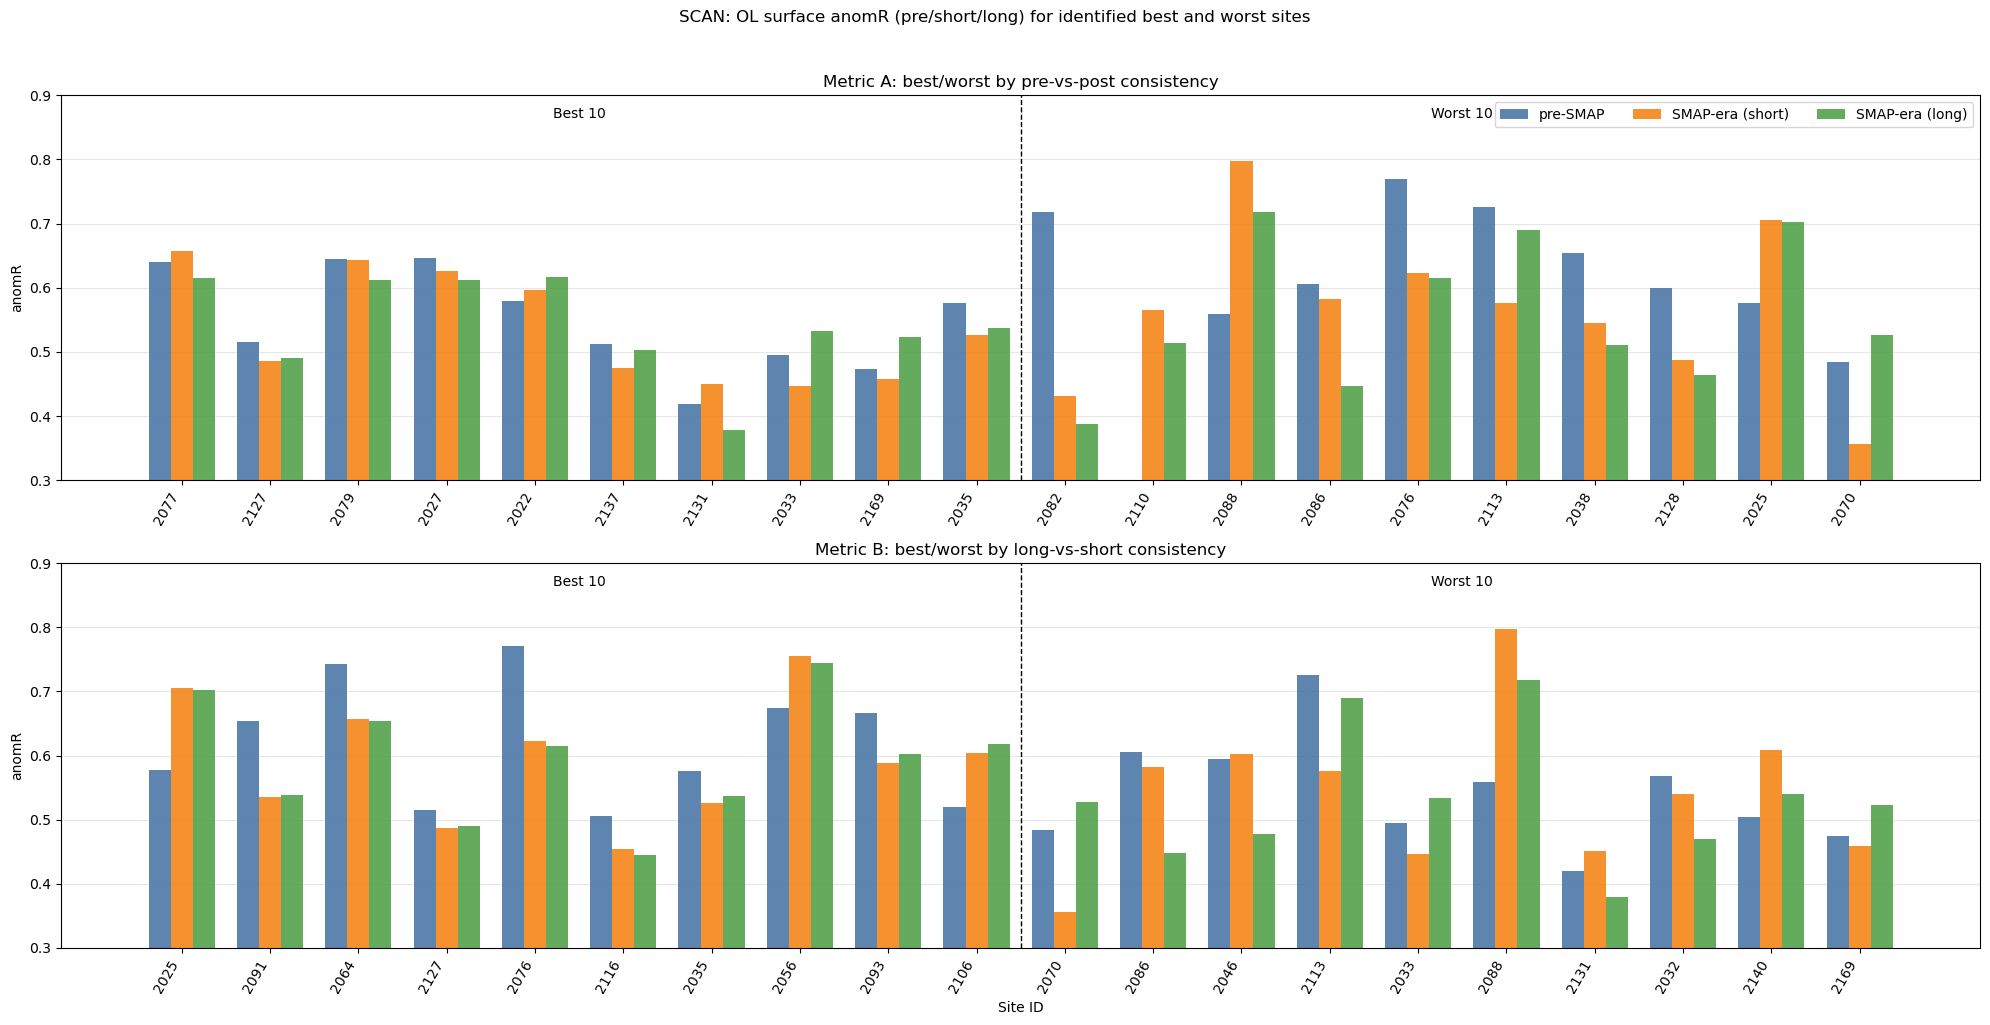

In [76]:
# -------------------------
# Rank sites by two consistency metrics and plot best 10 + worst 10
# -------------------------
if "ol_fixed_stats" not in globals() or "selected_short_sites" not in globals():
    raise RuntimeError("Run the OL fixed-site comparison cells above first.")

SURF_DEPTH = 0
range_needed = ["pre-SMAP", "SMAP-era (short)", "SMAP-era (long)"]
sites = selected_short_sites[SURF_DEPTH]

if len(sites) == 0:
    raise RuntimeError("No selected surface sites found")

piv = (
    ol_fixed_stats[
        (ol_fixed_stats["depth"] == SURF_DEPTH)
        & (ol_fixed_stats["site"].isin(sites))
        & (ol_fixed_stats["range"].isin(range_needed))
    ]
    .pivot_table(index="site", columns="range", values="anomR", aggfunc="first")
    .reindex(index=sites, columns=range_needed)
)

delta_df = piv.copy()
delta_df["d_short_pre"] = delta_df["SMAP-era (short)"] - delta_df["pre-SMAP"]
delta_df["d_long_pre"] = delta_df["SMAP-era (long)"] - delta_df["pre-SMAP"]
delta_df["d_long_short"] = delta_df["SMAP-era (long)"] - delta_df["SMAP-era (short)"]

# Metric A: consistency relative to pre-SMAP (combine d_short_pre + d_long_pre)
delta_df["metric_pre_consistency"] = delta_df[["d_short_pre", "d_long_pre"]].abs().max(axis=1)

# Metric B: sensitivity to adding later years (long vs short)
delta_df["metric_extension_consistency"] = delta_df["d_long_short"].abs()

def site_id_for(idx):
    if meta is not None and "ids" in meta and idx < len(meta["ids"]):
        return str(meta["ids"][idx])
    return str(idx)

def pick_best_worst(df, metric_col, n_each=10):
    s = df[metric_col].dropna().sort_values()
    if s.empty:
        return []
    if len(s) <= 2 * n_each:
        return s.index.tolist()
    return s.index[:n_each].tolist() + s.index[-n_each:].tolist()

sites_mA = pick_best_worst(delta_df, "metric_pre_consistency", n_each=10)
sites_mB = pick_best_worst(delta_df, "metric_extension_consistency", n_each=10)

# Optional tables for review
rank_A = delta_df.sort_values("metric_pre_consistency").copy()
rank_B = delta_df.sort_values("metric_extension_consistency").copy()
rank_A["site_id"] = [site_id_for(i) for i in rank_A.index]
rank_B["site_id"] = [site_id_for(i) for i in rank_B.index]

display(rank_A[["site_id", "d_short_pre", "d_long_pre", "metric_pre_consistency"]].head(10))
display(rank_A[["site_id", "d_short_pre", "d_long_pre", "metric_pre_consistency"]].tail(10))
display(rank_B[["site_id", "d_long_short", "metric_extension_consistency"]].head(10))
display(rank_B[["site_id", "d_long_short", "metric_extension_consistency"]].tail(10))

fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharex=False)

# --- Top panel: d_short_pre and d_long_pre for best10+worst10 by Metric A
if len(sites_mA) > 0:
    subA = delta_df.loc[sites_mA]
    xA = np.arange(len(subA))
    bw = 0.38
    axs[0].bar(xA - bw/2, subA["d_short_pre"].to_numpy(dtype=float), width=bw, color="#4C78A8", label="d_short_pre")
    axs[0].bar(xA + bw/2, subA["d_long_pre"].to_numpy(dtype=float), width=bw, color="#F58518", label="d_long_pre")
    axs[0].axhline(0, color="0.3", lw=1)
    if len(subA) > 10:
        axs[0].axvline(9.5, color="k", ls="--", lw=1)
        axs[0].text(4.5, axs[0].get_ylim()[1]*0.92, "Best 10", ha="center", va="top")
        axs[0].text(14.5, axs[0].get_ylim()[1]*0.92, "Worst 10", ha="center", va="top")

    labelsA = [site_id_for(i) for i in subA.index]
    axs[0].set_xticks(xA)
    axs[0].set_xticklabels(labelsA, rotation=60, ha="right")
    axs[0].set_ylabel("anomR delta")
    axs[0].set_title("Metric A ranking: consistency to pre-SMAP (|d_short_pre| and |d_long_pre|)")
    axs[0].grid(axis="y", alpha=0.3)
    axs[0].set_axisbelow(True)
    axs[0].legend(loc="upper right", ncol=2)
else:
    axs[0].set_title("Metric A ranking: no data")
    axs[0].axis("off")

# --- Bottom panel: d_long_short for best10+worst10 by Metric B
if len(sites_mB) > 0:
    subB = delta_df.loc[sites_mB]
    xB = np.arange(len(subB))
    axs[1].bar(xB, subB["d_long_short"].to_numpy(dtype=float), width=0.7, color="#54A24B", label="d_long_short")
    axs[1].axhline(0, color="0.3", lw=1)
    if len(subB) > 10:
        axs[1].axvline(9.5, color="k", ls="--", lw=1)
        axs[1].text(4.5, axs[1].get_ylim()[1]*0.92, "Best 10", ha="center", va="top")
        axs[1].text(14.5, axs[1].get_ylim()[1]*0.92, "Worst 10", ha="center", va="top")

    labelsB = [site_id_for(i) for i in subB.index]
    axs[1].set_xticks(xB)
    axs[1].set_xticklabels(labelsB, rotation=60, ha="right")
    axs[1].set_ylabel("anomR delta")
    axs[1].set_title("Metric B ranking: extension sensitivity (|d_long_short|)")
    axs[1].grid(axis="y", alpha=0.3)
    axs[1].set_axisbelow(True)
    axs[1].legend(loc="upper right")
else:
    axs[1].set_title("Metric B ranking: no data")
    axs[1].axis("off")

axs[1].set_xlabel("Site ID")
fig.suptitle(f"{NETWORK}: OL surface consistency ranking by site", y=1.02)
plt.tight_layout()
plt.show()


# -------------------------
# Additional view: 3-bar anomR (pre/short/long) for identified best/worst sites
# -------------------------
range_cols = ["pre-SMAP", "SMAP-era (short)", "SMAP-era (long)"]
surf_piv = piv.reindex(columns=range_cols)

best10_A = rank_A.index[:10].tolist()
worst10_A = rank_A.index[-10:].tolist()[::-1]
sites_A = best10_A + worst10_A

best10_B = rank_B.index[:10].tolist()
worst10_B = rank_B.index[-10:].tolist()[::-1]
sites_B = best10_B + worst10_B

def _plot_anomr_3bar(ax, site_list, title):
    if len(site_list) == 0:
        ax.set_title(f"{title}: no sites")
        ax.axis("off")
        return

    sub = surf_piv.reindex(site_list)
    x = np.arange(len(site_list))
    bw = 0.25
    colors = ["#4C78A8", "#F58518", "#54A24B"]

    for j, rname in enumerate(range_cols):
        y = sub[rname].to_numpy(dtype=float)
        ax.bar(x + (j - 1) * bw, y, width=bw, color=colors[j], label=rname, alpha=0.9)

    labels = [site_id_for(i) for i in site_list]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_ylim(0.3, 0.9)
    ax.set_ylabel("anomR")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

    if len(site_list) > 10:
        ax.axvline(9.5, color="k", ls="--", lw=1)
        y_top = ax.get_ylim()[1]
        ax.text(4.5, y_top * 0.98, "Best 10", ha="center", va="top")
        ax.text(14.5, y_top * 0.98, "Worst 10", ha="center", va="top")

fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharex=False)
_plot_anomr_3bar(axs[0], sites_A, "Metric A: best/worst by pre-vs-post consistency")
_plot_anomr_3bar(axs[1], sites_B, "Metric B: best/worst by long-vs-short consistency")

axs[0].legend(loc="upper right", ncol=3)
axs[1].set_xlabel("Site ID")
fig.suptitle(f"{NETWORK}: OL surface anomR (pre/short/long) for identified best and worst sites", y=1.02)
plt.tight_layout()
plt.show()


### OL vs Obs Surface Time Series for Best/Worst Consistency Sites

Two 4x2 figures are produced:
1. **pre-vs-post consistency** ranking (`d_short_pre` + `d_long_pre`) with best 4 (left) and worst 4 (right).
2. **long-vs-short consistency** ranking (`d_long_short`) with best 4 (left) and worst 4 (right).


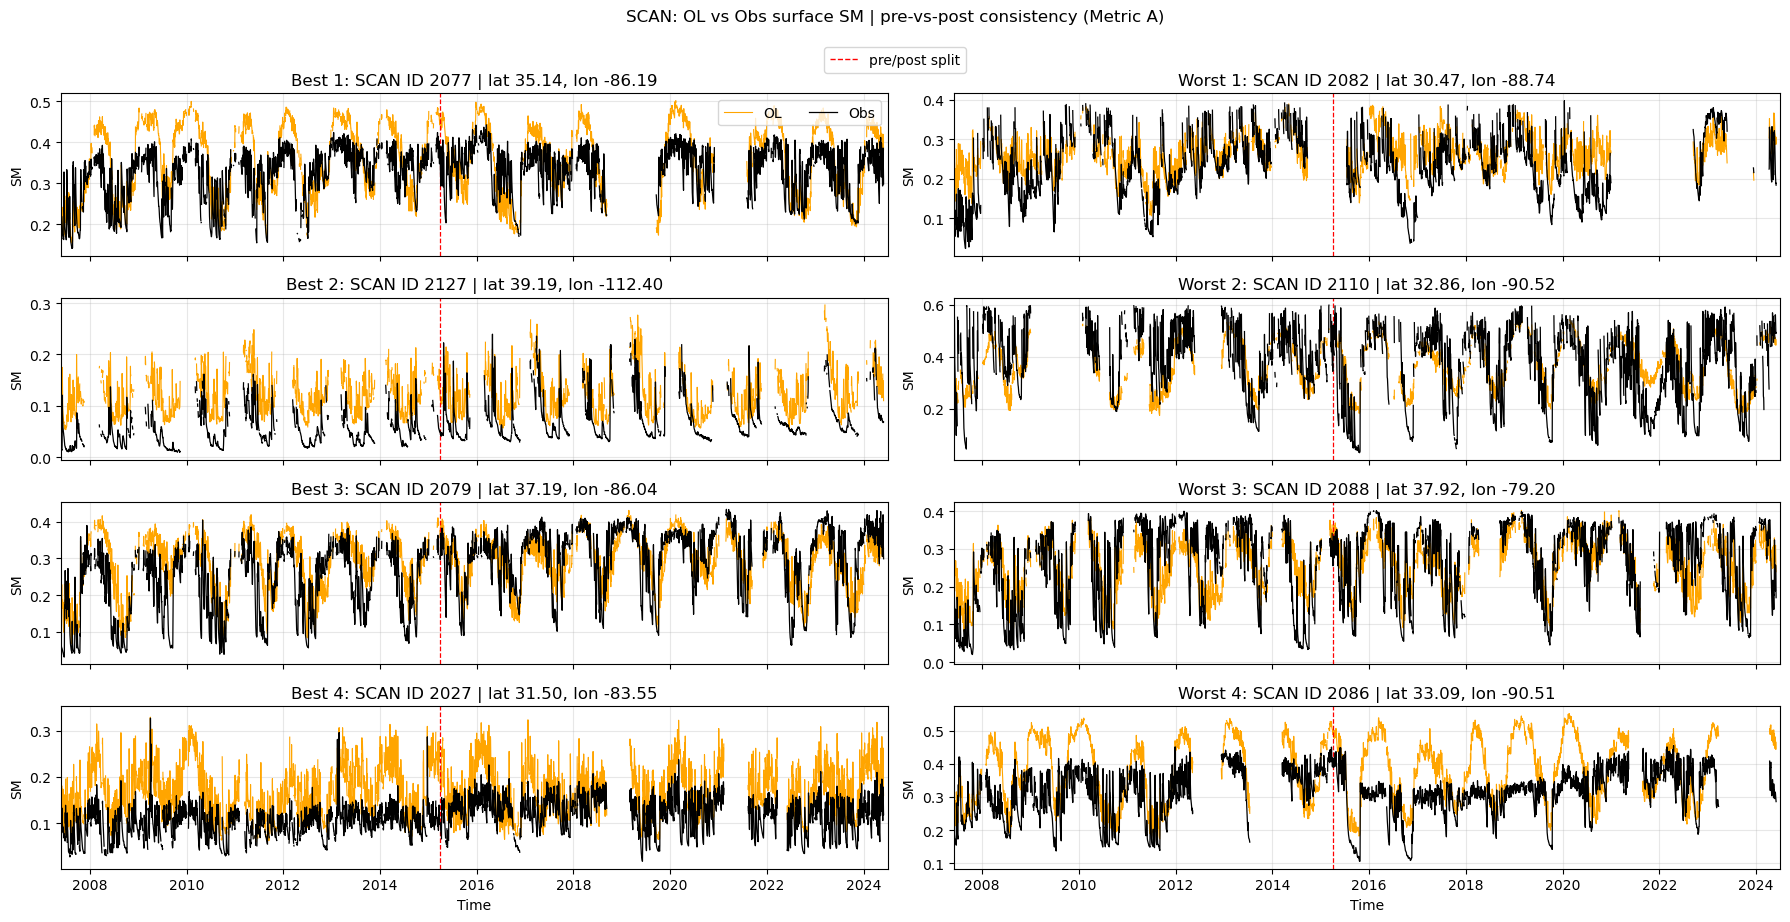

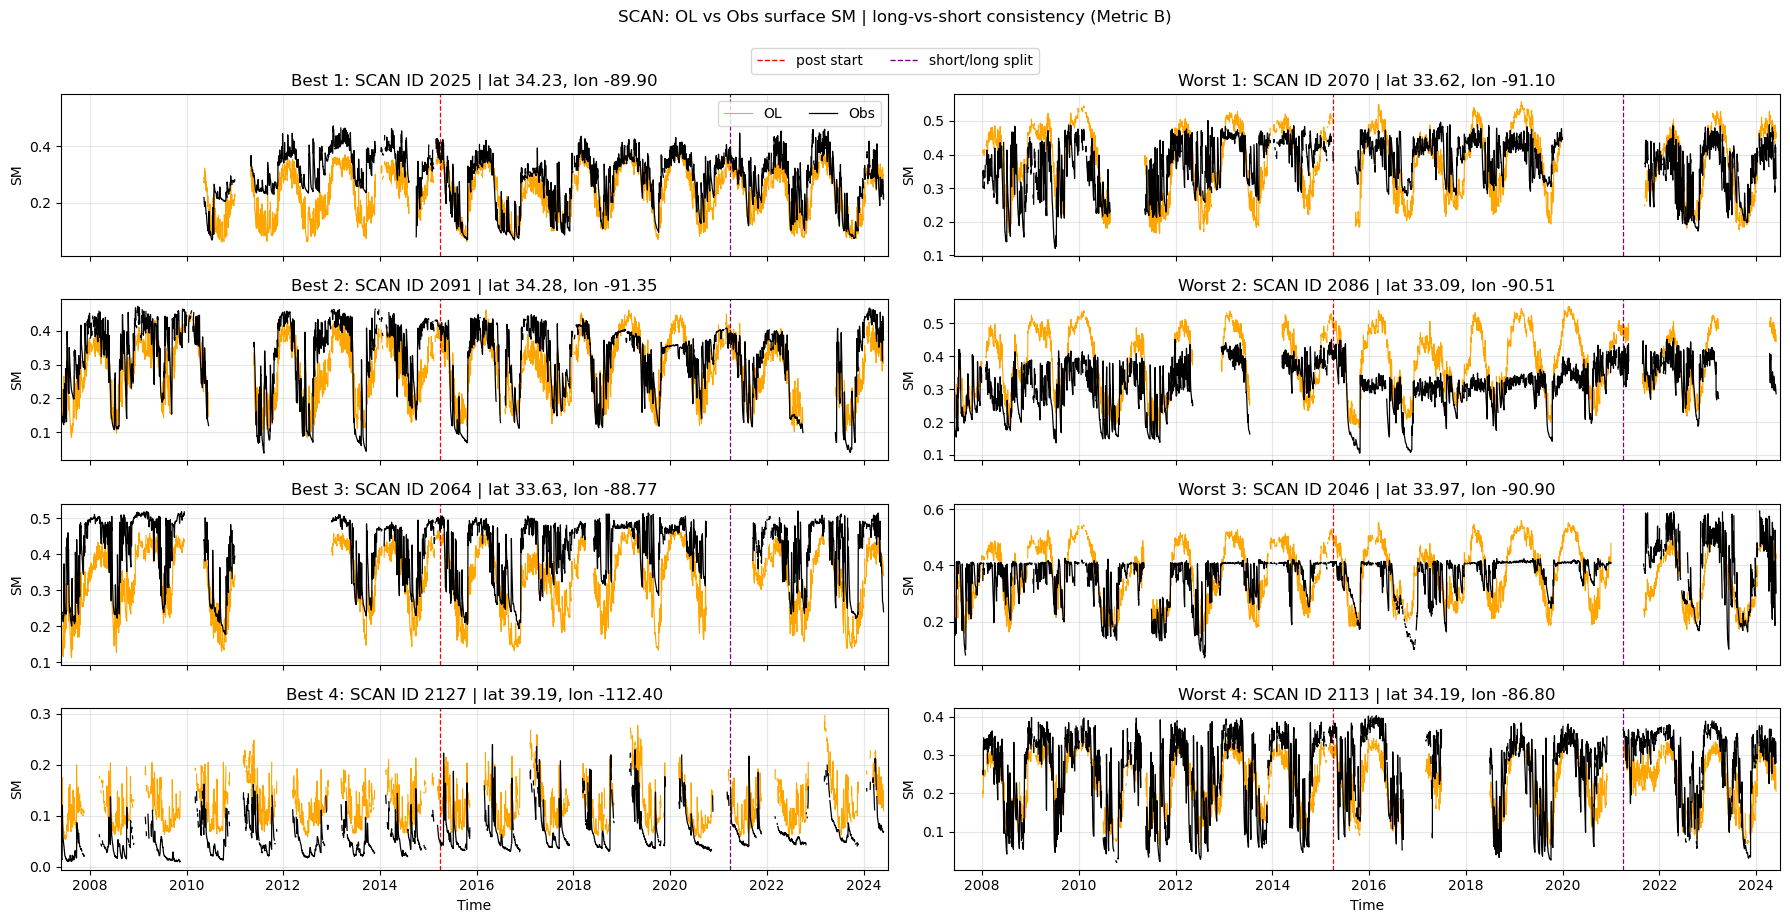

In [77]:
# -------------------------
# Time-series quality check: OL vs Obs (surface), best4 vs worst4 for two rankings
# -------------------------
if "selected_short_sites" not in globals():
    raise RuntimeError("Run fixed-site setup cells first (selected_short_sites missing).")

# recover ranking tables if needed
if "rank_A" not in globals() or "rank_B" not in globals():
    if "delta_df" in globals():
        rank_A = delta_df.sort_values("metric_pre_consistency").copy()
        rank_B = delta_df.sort_values("metric_extension_consistency").copy()
    else:
        raise RuntimeError("Run the ranking cell first to create rank_A/rank_B.")

SURF_DEPTH = 0
ol_surface = ldas_by_exp["OL"][:, SURF_DEPTH, :]
obs_surface = obs[:, SURF_DEPTH, :]

pre_start = dt.datetime.fromisoformat("2007-06-01")
post_start = dt.datetime.fromisoformat("2015-04-01")
short_end = dt.datetime.fromisoformat("2021-04-01")
long_end = dt.datetime.fromisoformat("2024-06-30")


def _site_title(site_idx: int, side_label: str, rank_pos: int):
    if meta is not None and "ids" in meta and site_idx < len(meta["ids"]):
        sid = str(meta["ids"][site_idx])
    else:
        sid = str(site_idx)

    lat = float(meta["lat"][site_idx]) if (meta is not None and "lat" in meta and site_idx < len(meta["lat"])) else np.nan
    lon = float(meta["lon"][site_idx]) if (meta is not None and "lon" in meta and site_idx < len(meta["lon"])) else np.nan
    lat_txt = f"{lat:.2f}" if np.isfinite(lat) else "NA"
    lon_txt = f"{lon:.2f}" if np.isfinite(lon) else "NA"
    return f"{side_label} {rank_pos}: {NETWORK} ID {sid} | lat {lat_txt}, lon {lon_txt}"


def _plot_best_worst_grid(best_sites, worst_sites, fig_title, vlines):
    fig, axs = plt.subplots(4, 2, figsize=(18, 9), sharex=True)

    for r in range(4):
        for c, site_list in enumerate([best_sites, worst_sites]):
            ax = axs[r, c]
            if r >= len(site_list):
                ax.set_visible(False)
                continue

            site = int(site_list[r])
            ax.plot(timestamps, ol_surface[:, site], color="orange", lw=0.8, label="OL")
            ax.plot(timestamps, obs_surface[:, site], color="k", lw=0.9, label="Obs", zorder=3)

            for vdt, vcolor, vlabel in vlines:
                ax.axvline(vdt, color=vcolor, ls="--", lw=0.9)

            side = "Best" if c == 0 else "Worst"
            ax.set_title(_site_title(site, side, r + 1))
            ax.set_ylabel("SM")
            ax.grid(alpha=0.3)
            ax.set_xlim(pre_start, long_end)

    # legend on first panel
    axs[0, 0].legend(loc="upper right", ncol=2)

    # add reference-line legend only once
    if len(vlines) > 0:
        from matplotlib.lines import Line2D
        ref_handles = [Line2D([0], [0], color=vc, ls="--", lw=1, label=vl) for _, vc, vl in vlines]
        fig.legend(handles=ref_handles, loc="upper center", ncol=max(1, len(ref_handles)), bbox_to_anchor=(0.5, 0.985))

    axs[-1, 0].set_xlabel("Time")
    axs[-1, 1].set_xlabel("Time")
    fig.suptitle(fig_title, y=1.02)
    plt.tight_layout()
    plt.show()


# Figure 1: pre-vs-post consistency ranking (Metric A)
best4_A = rank_A.index[:4].tolist()
worst4_A = rank_A.index[-4:].tolist()[::-1]  # most inconsistent at top-right
_plot_best_worst_grid(
    best4_A,
    worst4_A,
    f"{NETWORK}: OL vs Obs surface SM | pre-vs-post consistency (Metric A)",
    vlines=[(post_start, "red", "pre/post split")],
)

# Figure 2: long-vs-short sensitivity ranking (Metric B)
best4_B = rank_B.index[:4].tolist()
worst4_B = rank_B.index[-4:].tolist()[::-1]
_plot_best_worst_grid(
    best4_B,
    worst4_B,
    f"{NETWORK}: OL vs Obs surface SM | long-vs-short consistency (Metric B)",
    vlines=[(post_start, "red", "post start"), (short_end, "purple", "short/long split")],
)


### Pre-vs-SMAP Figure With Worst 5 `long_short` Sites Removed

Reproduces the main pre-SMAP vs SMAP-era bar chart (same layout/metrics as earlier), after removing the 5 worst sites by `|d_long_short|` from the surface site pool.


Removing worst 5 sites by |d_long_short| (surface ranking):
  site_index=26, site_id=2033
  site_index=84, site_id=2113
  site_index=37, site_id=2046
  site_index=67, site_id=2086
  site_index=54, site_id=2070


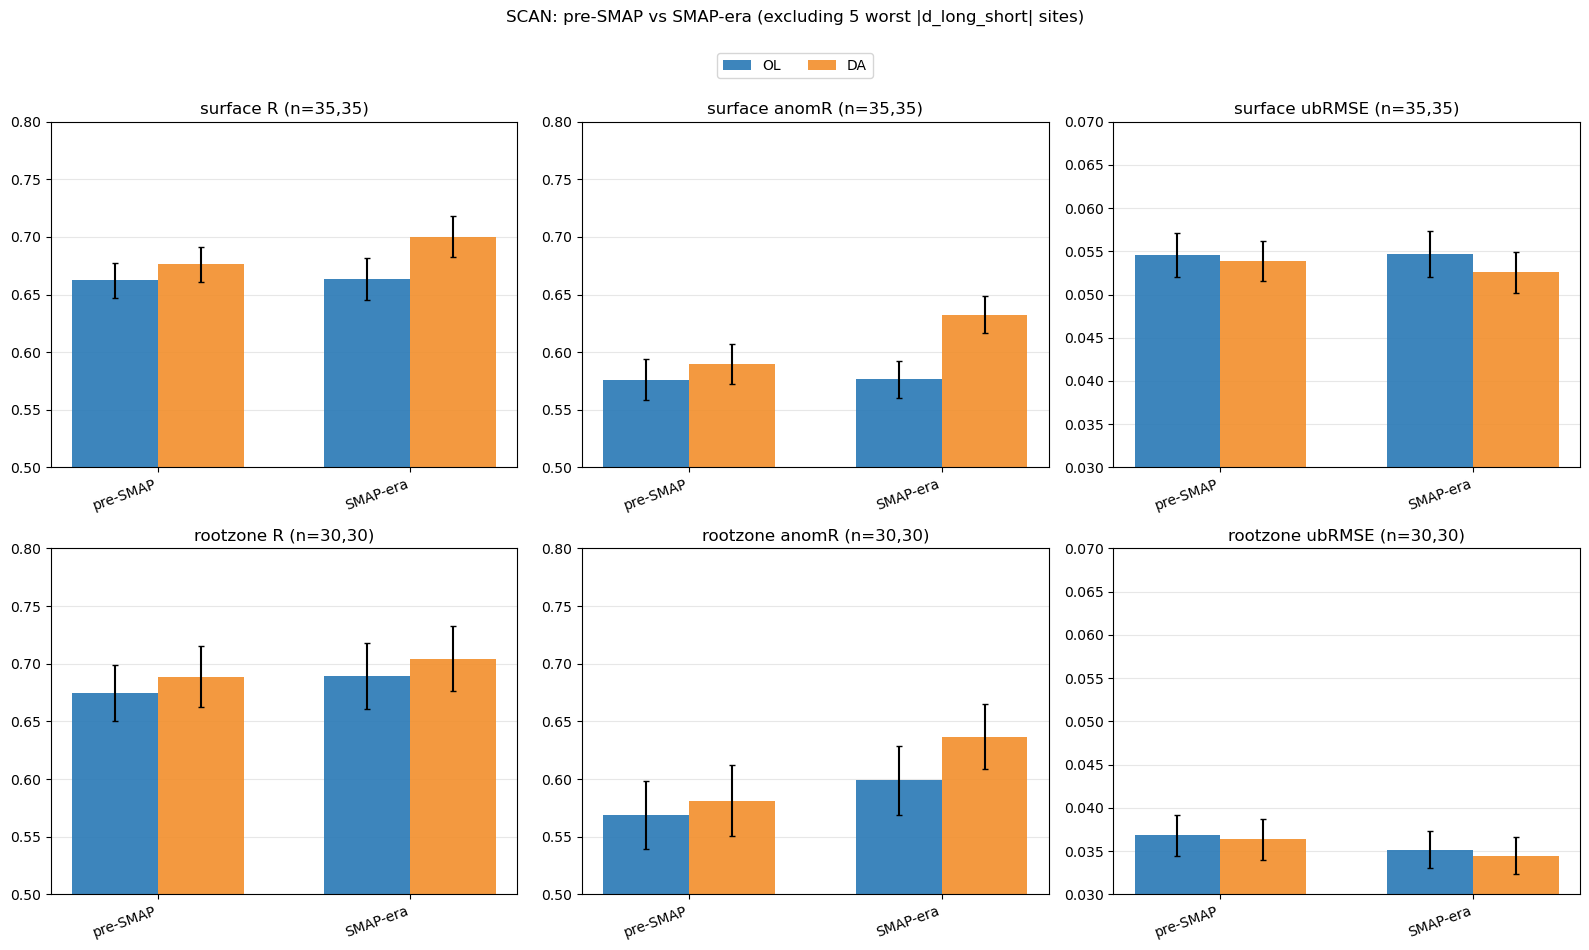

In [78]:
# -------------------------
# Reproduce pre-vs-SMAP figure after removing 5 worst long_short sites
# -------------------------
if "stats_df" not in globals():
    raise RuntimeError("stats_df not found; run the main stats cells first.")

# Prefer rank_B (already sorted by metric_extension_consistency); fallback uses delta_df
if "rank_B" in globals():
    rank_b_use = rank_B.copy()
elif "delta_df" in globals():
    rank_b_use = delta_df.sort_values("metric_extension_consistency").copy()
else:
    raise RuntimeError("rank_B/delta_df not found; run the consistency ranking cell first.")

worst5_sites = rank_b_use.index[-5:].tolist()

# helper for readable labels
removed_labels = []
for s in worst5_sites:
    if meta is not None and "ids" in meta and s < len(meta["ids"]):
        removed_labels.append(str(meta["ids"][s]))
    else:
        removed_labels.append(str(s))

print("Removing worst 5 sites by |d_long_short| (surface ranking):")
for idx, sid in zip(worst5_sites, removed_labels):
    print(f"  site_index={idx}, site_id={sid}")

# Remove these site indices from the stats used in the original pre-vs-SMAP figure
# (applied across both depths if present)
stats_df_drop5 = stats_df[~stats_df["site"].isin(worst5_sites)].copy()

metrics = ["R", "anomR", "ubRMSE"]
summary_rows_drop5 = []
for depth in [0, 1]:
    for r_name, _, _ in RANGES:
        for exp in EXP_ORDER:
            sub = stats_df_drop5[
                (stats_df_drop5["depth"] == depth)
                & (stats_df_drop5["range"] == r_name)
                & (stats_df_drop5["experiment"] == exp)
            ]
            for metric in metrics:
                vals = sub[metric].to_numpy(dtype=float)
                n = int(np.sum(np.isfinite(vals)))
                mean = float(np.nanmean(vals)) if n > 0 else np.nan
                sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
                summary_rows_drop5.append(
                    {
                        "depth": depth,
                        "range": r_name,
                        "experiment": exp,
                        "metric": metric,
                        "n": n,
                        "mean": mean,
                        "sem": sem,
                    }
                )

summary_df_drop5 = pd.DataFrame(summary_rows_drop5)

# Plot (mirrors the earlier pre-vs-SMAP figure style)
range_names = [r[0] for r in RANGES]
metric_order = ["R", "anomR", "ubRMSE"]

fig, axs = plt.subplots(2, 3, figsize=(16, 9), sharex=False)
width = 0.34
x = np.arange(len(range_names))
colors = {"OL": "#2878B5", "DA": "#F28E2B"}

for d in [0, 1]:
    for j, metric in enumerate(metric_order):
        ax = axs[d, j]
        for i, exp in enumerate(EXP_ORDER):
            sub = summary_df_drop5[
                (summary_df_drop5["depth"] == d)
                & (summary_df_drop5["metric"] == metric)
                & (summary_df_drop5["experiment"] == exp)
            ].set_index("range").reindex(range_names)

            y = sub["mean"].to_numpy(dtype=float)
            yerr = sub["sem"].to_numpy(dtype=float)

            ax.bar(
                x + (i - 0.5) * width,
                y,
                width=width,
                yerr=yerr,
                capsize=2,
                alpha=0.9,
                color=colors.get(exp, None),
                label=exp if (d == 0 and j == 0) else None,
            )

        n_text = []
        for r_name in range_names:
            nvals = summary_df_drop5[
                (summary_df_drop5["depth"] == d)
                & (summary_df_drop5["metric"] == metric)
                & (summary_df_drop5["range"] == r_name)
            ]["n"].to_numpy(dtype=int)
            n_text.append(str(int(np.nanmin(nvals))) if nvals.size else "0")

        ax.set_title(f"{DEPTH_NAMES[d]} {metric} (n={','.join(n_text)})")
        ax.set_xticks(x)
        ax.set_xticklabels(range_names, rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.5, 0.8)
        elif metric == "ubRMSE":
            ax.set_ylim(0.03, 0.07)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(EXP_ORDER), bbox_to_anchor=(0.5, 1.01))
fig.suptitle(
    f"{NETWORK}: pre-SMAP vs SMAP-era (excluding 5 worst |d_long_short| sites)",
    y=1.05,
)
plt.tight_layout()
plt.show()


## SMAP-Era Split Analysis (split date: 2021-04-01)

This section compares two SMAP-era subperiods:
- `SMAP-early`: 2015-04-01 to 2021-03-31
- `SMAP-late`: 2021-04-01 to 2024-06-30

Workflow:
1. Obs-only QC/ranking and top-N selection (same ranking style as above).
2. Intermediate check: list best/worst 20 obs-only sites and plot 4x2 Obs-only time series (best left, worst right).
3. Compute OL/DA statistics for the two subperiods using selected sites.


In [79]:
# -------------------------
# 1) Obs-only QC/ranking for SMAP split (2021-04-01)
# -------------------------
if "obs" not in globals() or "timestamps" not in globals():
    raise RuntimeError("Run upstream load cells first (obs/timestamps missing).")

SMAP_SPLIT_DATE = dt.datetime.fromisoformat("2021-04-01")
SMAP_SPLIT_RANGES = [
    ("SMAP-early", "2015-04-01", "2021-03-31"),  # pre-split
    ("SMAP-late", "2021-04-01", "2024-06-30"),   # post-split
]

split_masks = {}
for name, s0, s1 in SMAP_SPLIT_RANGES:
    t0 = dt.datetime.fromisoformat(s0)
    t1 = dt.datetime.fromisoformat(s1)
    split_masks[name] = (timestamps >= t0) & (timestamps <= t1)

early_name = "SMAP-early"
late_name = "SMAP-late"

years = np.array([t.year for t in timestamps], dtype=int)
months = np.array([t.month for t in timestamps], dtype=int)

try:
    from scipy.stats import ks_2samp
except Exception:
    ks_2samp = None

smap_split_qc_by_depth = {}
smap_split_selected_sites = {}

for depth in [0, 1]:
    min_days = MIN_DAYS_PER_RANGE_SURF if depth == 0 else MIN_DAYS_PER_RANGE_RZ
    rows = []

    for site in range(obs.shape[2]):
        series = obs[:, depth, site].astype(float)
        if np.all(np.isnan(series)):
            continue

        df = pd.DataFrame({"year": years, "val": series})
        cov = df.groupby("year")["val"].apply(lambda s: np.isfinite(s).sum())
        if cov.size < QC_MIN_YEARS:
            continue

        cov_med = float(np.median(cov))
        cov_min = int(np.min(cov))
        coverage_drop = cov_min < cov_med * (1.0 - COVERAGE_DROP_FRAC)

        period_counts = []
        for r_name, _, _ in SMAP_SPLIT_RANGES:
            m = split_masks[r_name]
            period_counts.append(int(np.isfinite(series[m]).sum()))

        coverage_period_fail = any(c < min_days for c in period_counts)
        period_min_count = int(np.min(period_counts))
        period_total_count = int(np.sum(period_counts))

        mean_early = float(np.nanmean(series[split_masks[early_name]]))
        mean_late = float(np.nanmean(series[split_masks[late_name]]))
        step_change = abs(mean_late - mean_early) if np.isfinite(mean_early) and np.isfinite(mean_late) else np.nan

        var_early = np.nanvar(series[split_masks[early_name]])
        var_late = np.nanvar(series[split_masks[late_name]])
        var_ratio = (var_late / var_early) if (var_early > 0 and np.isfinite(var_late)) else np.nan
        var_drift = np.isfinite(var_ratio) and ((var_ratio > VAR_DRIFT_FACTOR) or (var_ratio < 1.0 / VAR_DRIFT_FACTOR))

        if ks_2samp is not None:
            v1 = series[split_masks[early_name] & np.isfinite(series)]
            v2 = series[split_masks[late_name] & np.isfinite(series)]
            ks_p = float(ks_2samp(v1, v2).pvalue) if (v1.size > 10 and v2.size > 10) else np.nan
        else:
            ks_p = np.nan
        dist_shift = np.isfinite(ks_p) and (ks_p < KS_PVAL_THRESH)

        clim_early = pd.DataFrame({"m": months[split_masks[early_name]], "v": series[split_masks[early_name]]}).groupby("m")["v"].mean()
        clim_late = pd.DataFrame({"m": months[split_masks[late_name]], "v": series[split_masks[late_name]]}).groupby("m")["v"].mean()
        common_m = clim_early.index.intersection(clim_late.index)
        if common_m.size >= 6:
            c1 = clim_early.loc[common_m].to_numpy()
            c2 = clim_late.loc[common_m].to_numpy()
            seasonal_corr = float(np.corrcoef(c1, c2)[0, 1]) if (np.all(np.isfinite(c1)) and np.all(np.isfinite(c2))) else np.nan
        else:
            seasonal_corr = np.nan
        seasonal_shift = np.isfinite(seasonal_corr) and (seasonal_corr < SEASONAL_CORR_MIN)

        rows.append({
            "site": int(site),
            "depth": int(depth),
            "period_counts": period_counts,
            "period_min_count": period_min_count,
            "period_total_count": period_total_count,
            "coverage_min": cov_min,
            "coverage_med": cov_med,
            "coverage_drop": bool(coverage_drop),
            "coverage_period_fail": bool(coverage_period_fail),
            "step_change_mean": float(step_change) if np.isfinite(step_change) else np.nan,
            "var_ratio": float(var_ratio) if np.isfinite(var_ratio) else np.nan,
            "var_drift": bool(var_drift),
            "ks_p": float(ks_p) if np.isfinite(ks_p) else np.nan,
            "dist_shift": bool(dist_shift),
            "seasonal_corr": float(seasonal_corr) if np.isfinite(seasonal_corr) else np.nan,
            "seasonal_shift": bool(seasonal_shift),
        })

    qdf = pd.DataFrame(rows)
    if qdf.empty:
        raise RuntimeError(f"No QC rows found for depth={depth}")

    qdf["flagged"] = qdf[["coverage_drop", "var_drift", "dist_shift", "seasonal_shift"]].any(axis=1)
    qdf["score"] = (
        qdf["coverage_drop"].astype(int)
        + 5 * qdf["coverage_period_fail"].astype(int)
        + qdf["var_drift"].astype(int)
        + qdf["dist_shift"].astype(int)
        + qdf["seasonal_shift"].astype(int)
    )

    qdf = qdf.sort_values(
        ["period_min_count", "period_total_count", "score", "coverage_period_fail", "coverage_min"],
        ascending=[False, False, True, True, False],
    ).reset_index(drop=True)

    candidates = qdf[~qdf["coverage_period_fail"]].copy()
    if candidates.empty:
        candidates = qdf.copy()

    top_n = int(TOP_N_SITES_BY_DEPTH.get(depth, 40))
    sel = candidates.head(top_n).copy()

    smap_split_qc_by_depth[depth] = qdf
    smap_split_selected_sites[depth] = sel["site"].astype(int).tolist()

    print(
        f"Depth {depth} ({DEPTH_NAMES[depth]}): selected {len(smap_split_selected_sites[depth])} "
        f"(requested {top_n}) for SMAP split analysis"
    )

smap_split_selected_summary = pd.concat(
    [
        smap_split_qc_by_depth[d].set_index("site").loc[smap_split_selected_sites[d], ["depth", "period_min_count", "period_total_count", "score", "coverage_min", "flagged"]].reset_index()
        for d in [0, 1]
    ],
    axis=0,
).reset_index(drop=True)

display(smap_split_selected_summary.head(20))


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/2648999080.py:60: RuntimeWarning: Mean of empty slice
  mean_early = float(np.nanmean(series[split_masks[early_name]]))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/2648999080.py:61: RuntimeWarning: Mean of empty slice
  mean_late = float(np.nanmean(series[split_masks[late_name]]))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/2648999080.py:64: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_early = np.nanvar(series[split_masks[early_name]])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/2648999080.py:65: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_late = np.nanvar(series[split_masks[late_name]])


Depth 0 (surface): selected 40 (requested 40) for SMAP split analysis


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/2648999080.py:60: RuntimeWarning: Mean of empty slice
  mean_early = float(np.nanmean(series[split_masks[early_name]]))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/2648999080.py:64: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_early = np.nanvar(series[split_masks[early_name]])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/2648999080.py:61: RuntimeWarning: Mean of empty slice
  mean_late = float(np.nanmean(series[split_masks[late_name]]))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_26997/2648999080.py:65: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_late = np.nanvar(series[split_masks[late_name]])


Depth 1 (rootzone): selected 13 (requested 30) for SMAP split analysis


,site,depth,period_min_count,period_total_count,score,coverage_min,flagged
0,30,0,1128,2842,2,0,True
1,81,0,1115,3134,2,0,True
2,25,0,1108,3133,2,0,True
3,64,0,1095,2329,2,0,True
4,26,0,1089,2967,3,0,True
5,86,0,1086,2280,2,0,True
6,19,0,1081,3148,2,0,True
7,20,0,1081,2979,1,0,True
8,139,0,1080,2798,2,0,True
9,66,0,1066,2789,2,0,True



best20_obs


,site,site_id,lat,lon,period_min_count,period_total_count,score,flagged
0,30,2037,34.30,-79.73,1128,2842,2,True
1,81,2109,33.66,-90.57,1115,3134,2,True
2,25,2032,33.38,-90.65,1108,3133,2,True
3,64,2083,34.25,-92.03,1095,2329,2,True
4,26,2033,32.75,-90.93,1089,2967,3,True
5,86,2115,32.43,-85.75,1086,2280,2,True
6,19,2025,34.23,-89.90,1081,3148,2,True
7,20,2026,31.73,-110.05,1081,2979,1,True
8,139,2176,32.40,-86.89,1080,2798,2,True
9,66,2085,35.28,-90.45,1066,2789,2,True



worst20_obs


,site,site_id,lat,lon,period_min_count,period_total_count,score,flagged
141,130,2167,40.17,-113.02,0,0,5,False
140,106,2143,37.66,-115.20,0,0,5,False
139,48,2059,34.85,-86.88,0,0,5,False
138,47,2058,34.43,-87.00,0,0,5,False
137,17,2023,34.95,-97.98,0,0,5,False
136,43,2054,34.87,-86.10,0,69,5,False
135,131,2168,32.56,-106.70,0,340,5,False
134,134,2171,34.36,-106.69,0,350,5,False
133,111,2148,42.95,-117.01,0,494,5,False
132,57,2074,42.02,-121.39,0,927,6,True


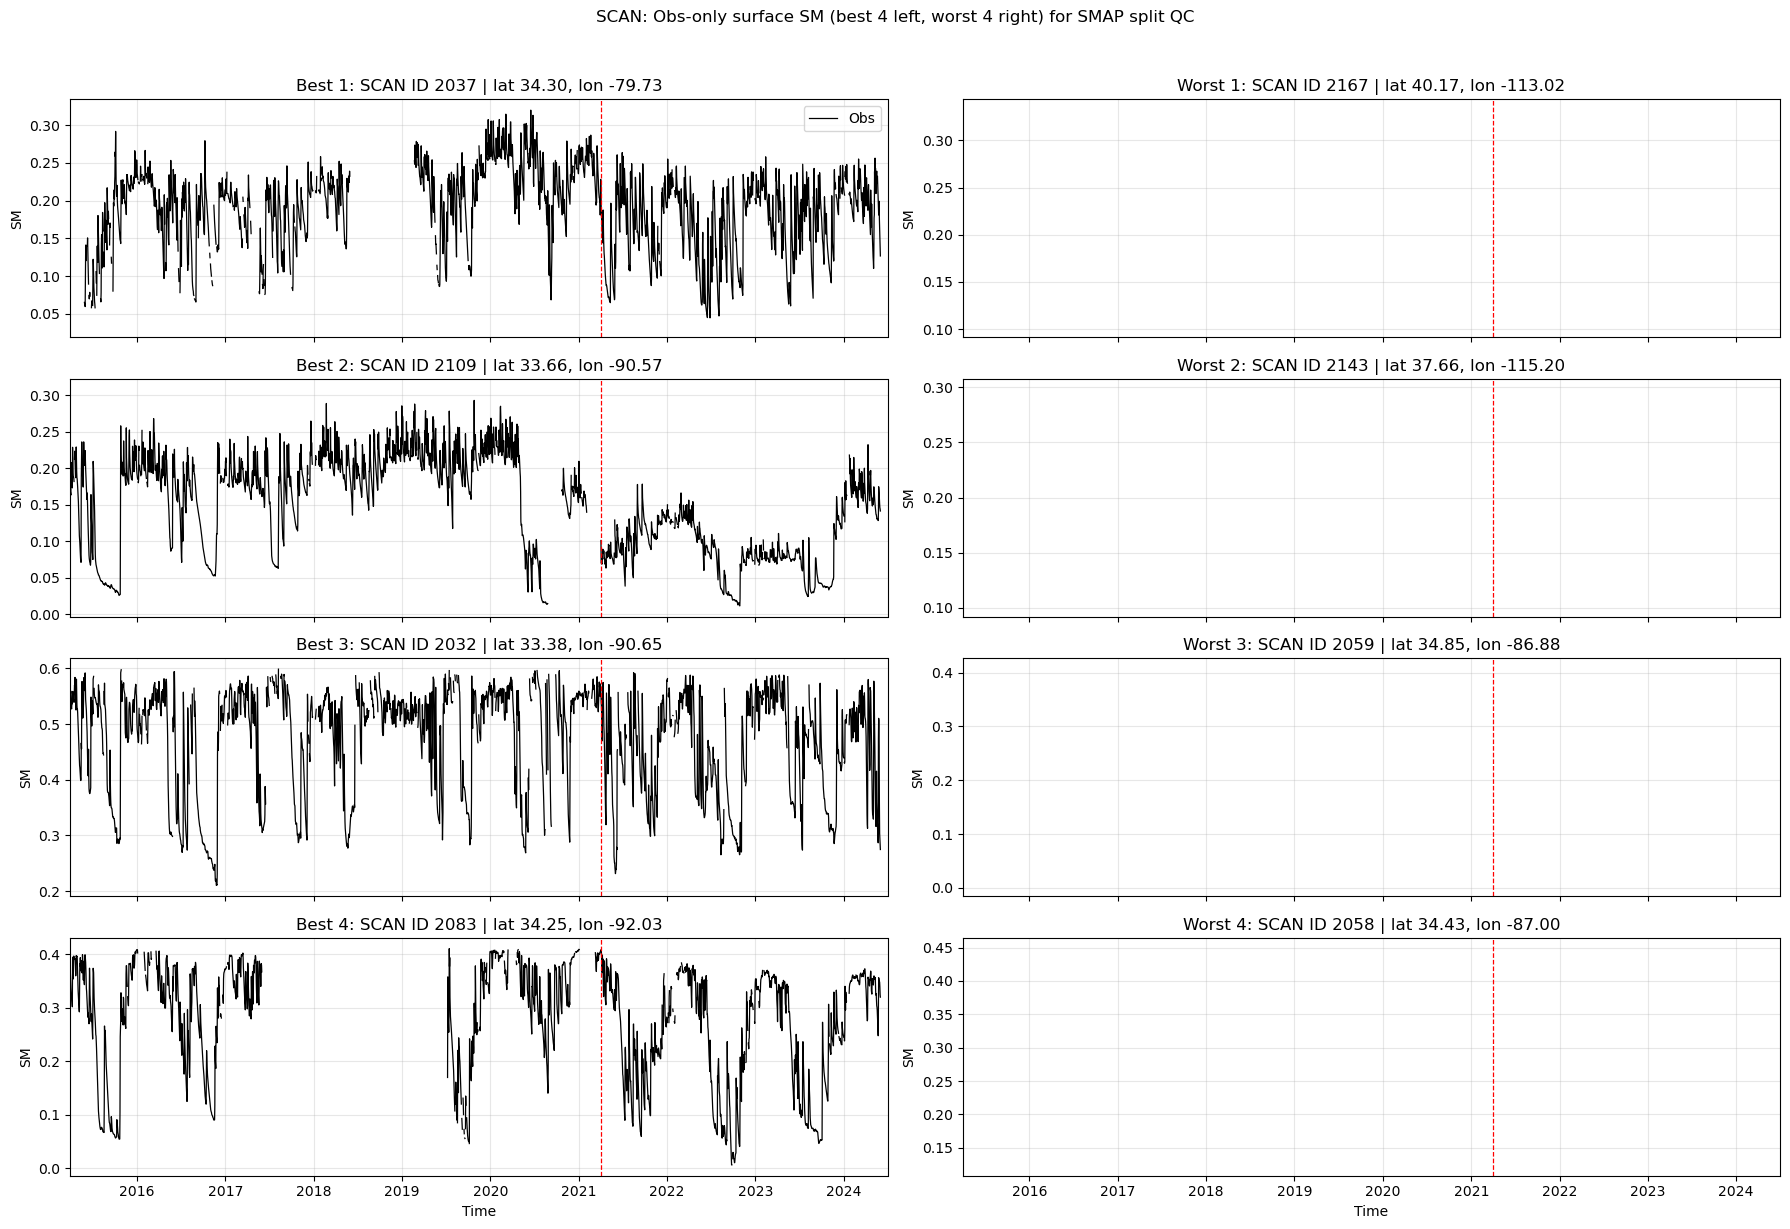

In [80]:
# -------------------------
# 2) Intermediate check: best/worst 20 obs-only sites + 4x2 Obs time series (surface)
# -------------------------
if "smap_split_qc_by_depth" not in globals():
    raise RuntimeError("Run SMAP split QC cell first.")

OBS_TS_DEPTH = 0
qdf = smap_split_qc_by_depth[OBS_TS_DEPTH].copy()

best20_obs = qdf.head(20).copy()
worst20_obs = qdf.tail(20).iloc[::-1].copy()


def _obs_site_meta(site_idx):
    sid = str(meta["ids"][site_idx]) if (meta is not None and "ids" in meta and site_idx < len(meta["ids"])) else str(site_idx)
    lat = float(meta["lat"][site_idx]) if (meta is not None and "lat" in meta and site_idx < len(meta["lat"])) else np.nan
    lon = float(meta["lon"][site_idx]) if (meta is not None and "lon" in meta and site_idx < len(meta["lon"])) else np.nan
    return sid, lat, lon


for tag, df_show in [("best20_obs", best20_obs), ("worst20_obs", worst20_obs)]:
    df_show = df_show.copy()
    ids, lats, lons = [], [], []
    for s in df_show["site"].astype(int).tolist():
        sid, lat, lon = _obs_site_meta(s)
        ids.append(sid)
        lats.append(lat)
        lons.append(lon)
    df_show["site_id"] = ids
    df_show["lat"] = lats
    df_show["lon"] = lons
    print(f"\n{tag}")
    display(df_show[["site", "site_id", "lat", "lon", "period_min_count", "period_total_count", "score", "flagged"]])

best4 = best20_obs["site"].astype(int).tolist()[:4]
worst4 = worst20_obs["site"].astype(int).tolist()[:4]

fig, axs = plt.subplots(4, 2, figsize=(18, 12), sharex=True)
for r in range(4):
    for c, site_list in enumerate([best4, worst4]):
        ax = axs[r, c]
        if r >= len(site_list):
            ax.set_visible(False)
            continue

        site = int(site_list[r])
        sid, lat, lon = _obs_site_meta(site)
        lat_txt = f"{lat:.2f}" if np.isfinite(lat) else "NA"
        lon_txt = f"{lon:.2f}" if np.isfinite(lon) else "NA"

        ax.plot(timestamps, obs[:, OBS_TS_DEPTH, site], color="k", lw=0.9, label="Obs")
        ax.axvline(SMAP_SPLIT_DATE, color="red", ls="--", lw=0.9)
        side = "Best" if c == 0 else "Worst"
        ax.set_title(f"{side} {r+1}: {NETWORK} ID {sid} | lat {lat_txt}, lon {lon_txt}")
        ax.set_ylabel("SM")
        ax.grid(alpha=0.3)
        ax.set_xlim(dt.datetime.fromisoformat("2015-04-01"), dt.datetime.fromisoformat("2024-06-30"))

axs[0, 0].legend(loc="upper right")
axs[-1, 0].set_xlabel("Time")
axs[-1, 1].set_xlabel("Time")
fig.suptitle(f"{NETWORK}: Obs-only surface SM (best 4 left, worst 4 right) for SMAP split QC", y=1.02)
plt.tight_layout()
plt.show()


In [81]:
# -------------------------
# 3) Compute OL/DA stats for SMAP-early vs SMAP-late using selected split sites
# -------------------------
if "smap_split_selected_sites" not in globals():
    raise RuntimeError("Run SMAP split selection first.")

split_stats_records = []
for depth in [0, 1]:
    for site in smap_split_selected_sites[depth]:
        for r_name, _, _ in SMAP_SPLIT_RANGES:
            mask = split_masks[r_name]
            obs_rng = obs[mask, depth, site].astype(float)
            doy_rng = doy_vec[mask]

            for exp in EXP_ORDER:
                mod_rng = ldas_by_exp[exp][mask, depth, site].astype(float)

                mod_pair = mod_rng.copy()
                obs_pair = obs_rng.copy()
                mod_pair[np.isnan(obs_pair)] = np.nan
                obs_pair[np.isnan(mod_pair)] = np.nan

                st = get_validation_stats(
                    np.column_stack([obs_pair, mod_pair]),
                    AC=True,
                    complete=True,
                    ref_col=1,
                    select_cols=[1, 2],
                    Nmin=NMIN,
                )

                ub_rmse = np.sqrt(max(st["ubMSE"], 0.0)) if np.isfinite(st["ubMSE"]) else np.nan

                obs_anom = compute_anom(obs_pair, doy_rng, Nmin_day=NMIN_DAY)
                mod_anom = compute_anom(mod_pair, doy_rng, Nmin_day=NMIN_DAY)
                st_anom = get_validation_stats(
                    np.column_stack([obs_anom, mod_anom]),
                    AC=True,
                    complete=True,
                    ref_col=1,
                    select_cols=[1, 2],
                    Nmin=NMIN,
                )

                split_stats_records.append({
                    "site": int(site),
                    "depth": int(depth),
                    "range": r_name,
                    "experiment": exp,
                    "N_pairs": float(st["N_pairs"]) if np.isfinite(st["N_pairs"]) else np.nan,
                    "R": float(st["R"]) if np.isfinite(st["R"]) else np.nan,
                    "anomR": float(st_anom["R"]) if np.isfinite(st_anom["R"]) else np.nan,
                    "ubRMSE": float(ub_rmse) if np.isfinite(ub_rmse) else np.nan,
                })

smap_split_stats_df = pd.DataFrame(split_stats_records)

summary_rows = []
for depth in [0, 1]:
    for r_name, _, _ in SMAP_SPLIT_RANGES:
        for exp in EXP_ORDER:
            sub = smap_split_stats_df[
                (smap_split_stats_df["depth"] == depth)
                & (smap_split_stats_df["range"] == r_name)
                & (smap_split_stats_df["experiment"] == exp)
            ]
            for metric in ["R", "anomR", "ubRMSE"]:
                vals = sub[metric].to_numpy(dtype=float)
                n = int(np.sum(np.isfinite(vals)))
                mean = float(np.nanmean(vals)) if n > 0 else np.nan
                sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
                summary_rows.append({
                    "depth": depth,
                    "range": r_name,
                    "experiment": exp,
                    "metric": metric,
                    "n": n,
                    "mean": mean,
                    "sem": sem,
                })

smap_split_summary_df = pd.DataFrame(summary_rows)

display(smap_split_summary_df.head(20))


,depth,range,experiment,metric,n,mean,sem
0,0,SMAP-early,OL,R,40,0.668320,0.017620
1,0,SMAP-early,OL,anomR,40,0.605720,0.018081
2,0,SMAP-early,OL,ubRMSE,40,0.062782,0.002723
3,0,SMAP-early,DA,R,40,0.708352,0.016442
4,0,SMAP-early,DA,anomR,40,0.669103,0.016462
5,0,SMAP-early,DA,ubRMSE,40,0.059561,0.002634
6,0,SMAP-late,OL,R,40,0.704231,0.019406
7,0,SMAP-late,OL,anomR,40,0.589296,0.028811
8,0,SMAP-late,OL,ubRMSE,40,0.059553,0.002950
9,0,SMAP-late,DA,R,40,0.735573,0.017221


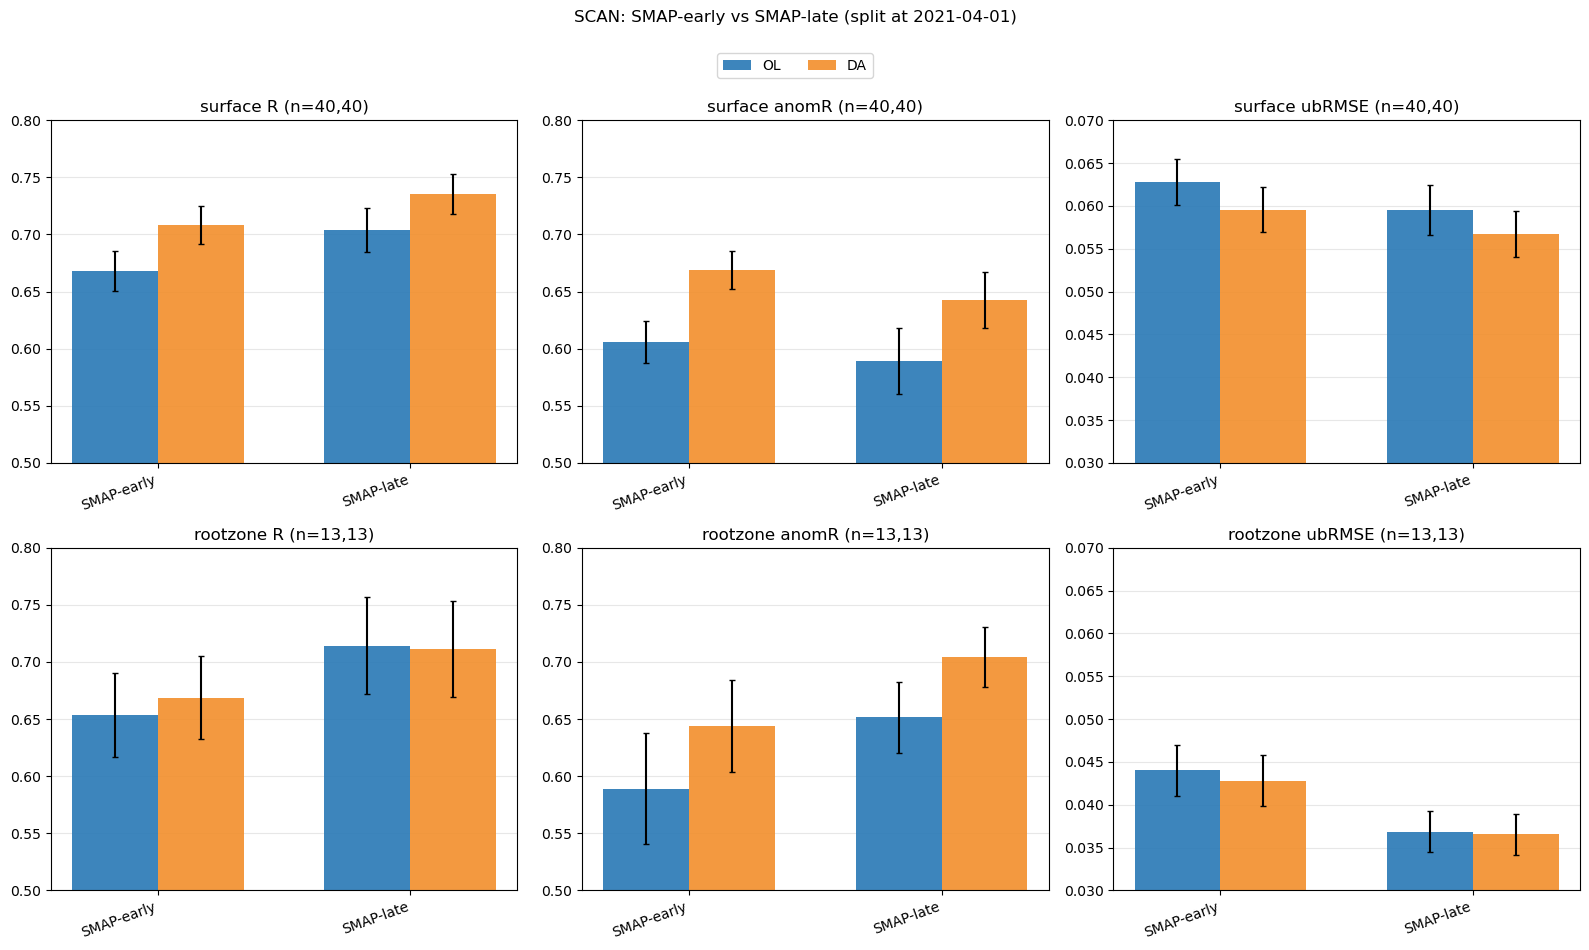

In [82]:
# -------------------------
# 4) Plot OL/DA bars for SMAP-early vs SMAP-late
# -------------------------
if "smap_split_summary_df" not in globals():
    raise RuntimeError("Run SMAP split stats cell first.")

range_names = [r[0] for r in SMAP_SPLIT_RANGES]
metric_order = ["R", "anomR", "ubRMSE"]

fig, axs = plt.subplots(2, 3, figsize=(16, 9), sharex=False)
width = 0.34
x = np.arange(len(range_names))
colors = {"OL": "#2878B5", "DA": "#F28E2B"}

for d in [0, 1]:
    for j, metric in enumerate(metric_order):
        ax = axs[d, j]
        for i, exp in enumerate(EXP_ORDER):
            sub = smap_split_summary_df[
                (smap_split_summary_df["depth"] == d)
                & (smap_split_summary_df["metric"] == metric)
                & (smap_split_summary_df["experiment"] == exp)
            ].set_index("range").reindex(range_names)

            y = sub["mean"].to_numpy(dtype=float)
            yerr = sub["sem"].to_numpy(dtype=float)

            ax.bar(
                x + (i - 0.5) * width,
                y,
                width=width,
                yerr=yerr,
                capsize=2,
                alpha=0.9,
                color=colors.get(exp, None),
                label=exp if (d == 0 and j == 0) else None,
            )

        n_text = []
        for r_name in range_names:
            nvals = smap_split_summary_df[
                (smap_split_summary_df["depth"] == d)
                & (smap_split_summary_df["metric"] == metric)
                & (smap_split_summary_df["range"] == r_name)
            ]["n"].to_numpy(dtype=int)
            n_text.append(str(int(np.nanmin(nvals))) if nvals.size else "0")

        ax.set_title(f"{DEPTH_NAMES[d]} {metric} (n={','.join(n_text)})")
        ax.set_xticks(x)
        ax.set_xticklabels(range_names, rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.5, 0.8)
        elif metric == "ubRMSE":
            ax.set_ylim(0.03, 0.07)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(EXP_ORDER), bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f"{NETWORK}: SMAP-early vs SMAP-late (split at 2021-04-01)", y=1.05)
plt.tight_layout()
plt.show()


## SMAP Split Check Using Original pre/SMAP Top-40 Sites

This section starts from the **surface top-40 sites already selected in the main pre-SMAP vs SMAP-era analysis** (`selected_sites[0]`), then filters to sites with enough obs on both sides of the 2021-04-01 split before computing SMAP-early vs SMAP-late statistics.


In [83]:
# -------------------------
# 1) Start from original pre/SMAP top-40 surface sites and check split coverage
# -------------------------
if "selected_sites" not in globals() or "obs" not in globals() or "timestamps" not in globals():
    raise RuntimeError("Run the main pre/SMAP analysis cells first (selected_sites/obs/timestamps missing).")

BASE_DEPTH = 0
BASE_TOP_N = 40
MIN_DAYS_EACH_SIDE = 600  # adjust if needed

SMAP_SPLIT_DATE = dt.datetime.fromisoformat("2021-04-01")
mask_early = (timestamps >= dt.datetime.fromisoformat("2015-04-01")) & (timestamps < SMAP_SPLIT_DATE)
mask_late  = (timestamps >= SMAP_SPLIT_DATE) & (timestamps <= dt.datetime.fromisoformat("2024-06-30"))

base_sites = selected_sites[BASE_DEPTH][:BASE_TOP_N]
if len(base_sites) == 0:
    raise RuntimeError("No base sites found from selected_sites[0].")

rows = []
for s in base_sites:
    s = int(s)
    ser = obs[:, BASE_DEPTH, s].astype(float)
    c_early = int(np.isfinite(ser[mask_early]).sum())
    c_late  = int(np.isfinite(ser[mask_late]).sum())
    keep = (c_early >= MIN_DAYS_EACH_SIDE) and (c_late >= MIN_DAYS_EACH_SIDE)

    if meta is not None and "ids" in meta and s < len(meta["ids"]):
        sid = str(meta["ids"][s])
    else:
        sid = str(s)

    lat = float(meta["lat"][s]) if (meta is not None and "lat" in meta and s < len(meta["lat"])) else np.nan
    lon = float(meta["lon"][s]) if (meta is not None and "lon" in meta and s < len(meta["lon"])) else np.nan

    rows.append({
        "site": s,
        "site_id": sid,
        "lat": lat,
        "lon": lon,
        "obs_days_early": c_early,
        "obs_days_late": c_late,
        "obs_days_min": min(c_early, c_late),
        "obs_days_total": c_early + c_late,
        "keep": bool(keep),
    })

base_split_cov_df = pd.DataFrame(rows).sort_values(
    ["keep", "obs_days_min", "obs_days_total"], ascending=[False, False, False]
).reset_index(drop=True)

split_keep_sites = base_split_cov_df.loc[base_split_cov_df["keep"], "site"].astype(int).tolist()

print(f"Base sites from main selection (depth={BASE_DEPTH}): {len(base_sites)}")
print(f"Keeping {len(split_keep_sites)} with >= {MIN_DAYS_EACH_SIDE} obs days on each side of split")

display(base_split_cov_df.head(25))
print("\nDropped sites:")
display(base_split_cov_df.loc[~base_split_cov_df["keep"], ["site", "site_id", "obs_days_early", "obs_days_late", "obs_days_min"]])


Base sites from main selection (depth=0): 40
Keeping 36 with >= 600 obs days on each side of split


,site,site_id,lat,lon,obs_days_early,obs_days_late,obs_days_min,obs_days_total,keep
0,30,2037,34.30,-79.73,1715,1128,1128,2843,True
1,25,2032,33.38,-90.65,2026,1108,1108,3134,True
2,26,2033,32.75,-90.93,1879,1089,1089,2968,True
3,19,2025,34.23,-89.90,2068,1081,1081,3149,True
4,66,2085,35.28,-90.45,1724,1066,1066,2790,True
5,82,2110,32.86,-90.52,1690,1053,1053,2743,True
6,59,2076,35.07,-86.89,1451,1047,1047,2498,True
7,77,2105,33.55,-102.37,1494,1009,1009,2503,True
8,84,2113,34.19,-86.80,1430,1009,1009,2439,True
9,6,2009,30.30,-84.42,1471,996,996,2467,True



Dropped sites:


,site,site_id,obs_days_early,obs_days_late,obs_days_min
36,8,2011,1436,552,552
37,78,2106,1487,495,495
38,132,2169,1690,440,440
39,63,2082,1680,309,309


In [84]:
# -------------------------
# 2) Compute SMAP-early vs SMAP-late stats using only kept base sites
# -------------------------
if "split_keep_sites" not in globals() or "ldas_by_exp" not in globals():
    raise RuntimeError("Run split coverage check cell first.")

SMAP_SPLIT_RANGES_BASE = [
    ("SMAP-early", "2015-04-01", "2021-03-31"),
    ("SMAP-late", "2021-04-01", "2024-06-30"),
]

split_masks_base = {}
for name, s0, s1 in SMAP_SPLIT_RANGES_BASE:
    t0 = dt.datetime.fromisoformat(s0)
    t1 = dt.datetime.fromisoformat(s1)
    split_masks_base[name] = (timestamps >= t0) & (timestamps <= t1)

records_base = []
for depth in [0, 1]:
    # surface uses kept list; rootzone can only use overlap with existing selected rootzone sites
    if depth == 0:
        site_list = split_keep_sites
    else:
        # optional conservative choice: rootzone subset of existing selected rootzone that also survived surface filter
        site_list = [s for s in selected_sites[1] if s in split_keep_sites]

    for site in site_list:
        site = int(site)
        for r_name, _, _ in SMAP_SPLIT_RANGES_BASE:
            m = split_masks_base[r_name]
            obs_rng = obs[m, depth, site].astype(float)
            doy_rng = doy_vec[m]

            for exp in EXP_ORDER:
                mod_rng = ldas_by_exp[exp][m, depth, site].astype(float)
                mod_rng[np.isnan(obs_rng)] = np.nan
                obs_pair = obs_rng.copy()
                obs_pair[np.isnan(mod_rng)] = np.nan

                st = get_validation_stats(
                    np.column_stack([obs_pair, mod_rng]),
                    AC=True,
                    complete=True,
                    ref_col=1,
                    select_cols=[1, 2],
                    Nmin=NMIN,
                )

                ub_rmse = np.sqrt(max(st["ubMSE"], 0.0)) if np.isfinite(st["ubMSE"]) else np.nan

                obs_anom = compute_anom(obs_pair, doy_rng, Nmin_day=NMIN_DAY)
                mod_anom = compute_anom(mod_rng, doy_rng, Nmin_day=NMIN_DAY)
                st_anom = get_validation_stats(
                    np.column_stack([obs_anom, mod_anom]),
                    AC=True,
                    complete=True,
                    ref_col=1,
                    select_cols=[1, 2],
                    Nmin=NMIN,
                )

                records_base.append({
                    "site": site,
                    "depth": depth,
                    "range": r_name,
                    "experiment": exp,
                    "N_pairs": float(st["N_pairs"]) if np.isfinite(st["N_pairs"]) else np.nan,
                    "R": float(st["R"]) if np.isfinite(st["R"]) else np.nan,
                    "anomR": float(st_anom["R"]) if np.isfinite(st_anom["R"]) else np.nan,
                    "ubRMSE": float(ub_rmse) if np.isfinite(ub_rmse) else np.nan,
                })

smap_split_base_stats_df = pd.DataFrame(records_base)

summary_rows = []
for depth in [0, 1]:
    for r_name, _, _ in SMAP_SPLIT_RANGES_BASE:
        for exp in EXP_ORDER:
            sub = smap_split_base_stats_df[
                (smap_split_base_stats_df["depth"] == depth)
                & (smap_split_base_stats_df["range"] == r_name)
                & (smap_split_base_stats_df["experiment"] == exp)
            ]
            for metric in ["R", "anomR", "ubRMSE"]:
                vals = sub[metric].to_numpy(dtype=float)
                n = int(np.sum(np.isfinite(vals)))
                mean = float(np.nanmean(vals)) if n > 0 else np.nan
                sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
                summary_rows.append({
                    "depth": depth,
                    "range": r_name,
                    "experiment": exp,
                    "metric": metric,
                    "n": n,
                    "mean": mean,
                    "sem": sem,
                })

smap_split_base_summary_df = pd.DataFrame(summary_rows)
display(smap_split_base_summary_df.head(20))


,depth,range,experiment,metric,n,mean,sem
0,0,SMAP-early,OL,R,36,0.666831,0.017547
1,0,SMAP-early,OL,anomR,36,0.576409,0.015951
2,0,SMAP-early,OL,ubRMSE,36,0.057554,0.002764
3,0,SMAP-early,DA,R,36,0.708993,0.015901
4,0,SMAP-early,DA,anomR,36,0.640598,0.013542
5,0,SMAP-early,DA,ubRMSE,36,0.055517,0.002575
6,0,SMAP-late,OL,R,36,0.671203,0.018905
7,0,SMAP-late,OL,anomR,36,0.574598,0.025167
8,0,SMAP-late,OL,ubRMSE,36,0.056367,0.002966
9,0,SMAP-late,DA,R,36,0.704533,0.017835


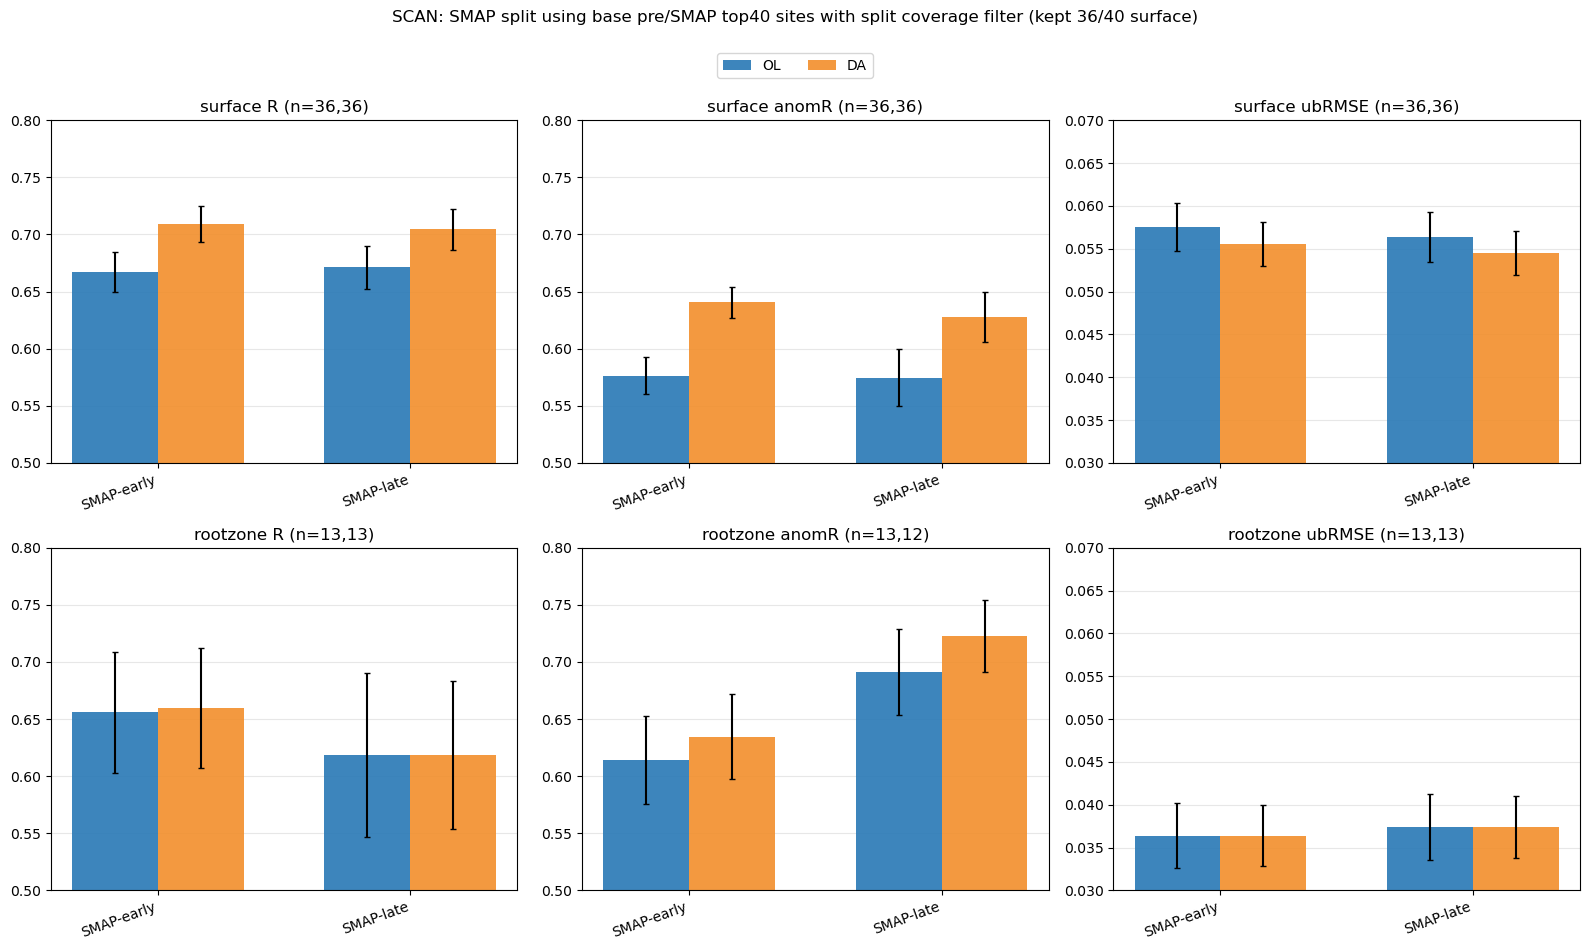

In [85]:
# -------------------------
# 3) Plot SMAP split bars for base-top40-after-coverage-filter set
# -------------------------
if "smap_split_base_summary_df" not in globals():
    raise RuntimeError("Run split base stats cell first.")

range_names = [r[0] for r in SMAP_SPLIT_RANGES_BASE]
metric_order = ["R", "anomR", "ubRMSE"]

fig, axs = plt.subplots(2, 3, figsize=(16, 9), sharex=False)
width = 0.34
x = np.arange(len(range_names))
colors = {"OL": "#2878B5", "DA": "#F28E2B"}

for d in [0, 1]:
    for j, metric in enumerate(metric_order):
        ax = axs[d, j]
        for i, exp in enumerate(EXP_ORDER):
            sub = smap_split_base_summary_df[
                (smap_split_base_summary_df["depth"] == d)
                & (smap_split_base_summary_df["metric"] == metric)
                & (smap_split_base_summary_df["experiment"] == exp)
            ].set_index("range").reindex(range_names)

            y = sub["mean"].to_numpy(dtype=float)
            yerr = sub["sem"].to_numpy(dtype=float)

            ax.bar(
                x + (i - 0.5) * width,
                y,
                width=width,
                yerr=yerr,
                capsize=2,
                alpha=0.9,
                color=colors.get(exp, None),
                label=exp if (d == 0 and j == 0) else None,
            )

        n_text = []
        for r_name in range_names:
            nvals = smap_split_base_summary_df[
                (smap_split_base_summary_df["depth"] == d)
                & (smap_split_base_summary_df["metric"] == metric)
                & (smap_split_base_summary_df["range"] == r_name)
            ]["n"].to_numpy(dtype=int)
            n_text.append(str(int(np.nanmin(nvals))) if nvals.size else "0")

        ax.set_title(f"{DEPTH_NAMES[d]} {metric} (n={','.join(n_text)})")
        ax.set_xticks(x)
        ax.set_xticklabels(range_names, rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.5, 0.8)
        elif metric == "ubRMSE":
            ax.set_ylim(0.03, 0.07)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(EXP_ORDER), bbox_to_anchor=(0.5, 1.01))
fig.suptitle(
    f"{NETWORK}: SMAP split using base pre/SMAP top40 sites with split coverage filter "
    f"(kept {len(split_keep_sites)}/{len(base_sites)} surface)",
    y=1.05,
)
plt.tight_layout()
plt.show()


### OL + Obs Time Series for Best/Worst Split-Coverage Sites (surface)


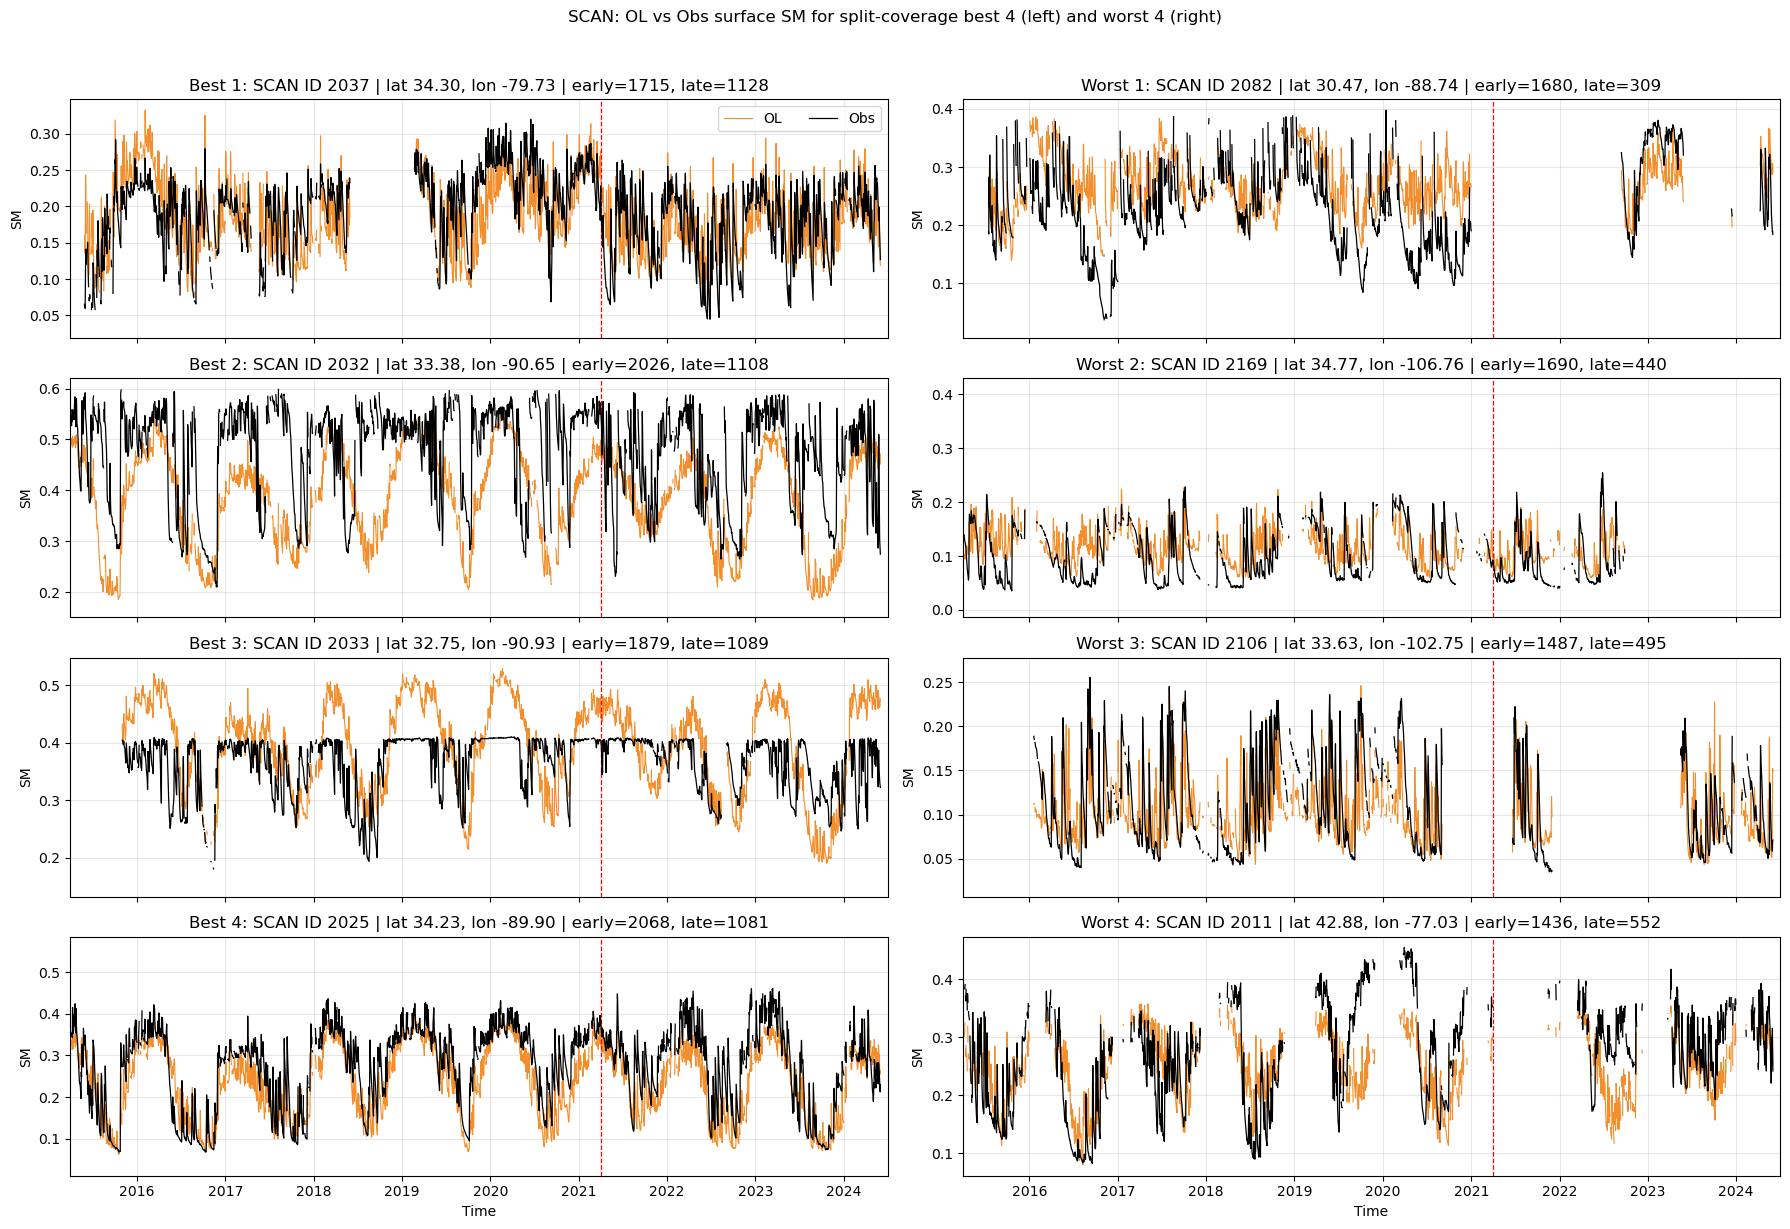

In [86]:
# -------------------------
# Time series (surface): 4 best vs 4 worst split-coverage sites from base top-40
# -------------------------
if "base_split_cov_df" not in globals():
    raise RuntimeError("Run the split coverage check cell first (base_split_cov_df missing).")

depth = 0
split_date = dt.datetime.fromisoformat("2021-04-01")
start_dt = dt.datetime.fromisoformat("2015-04-01")
end_dt = dt.datetime.fromisoformat("2024-06-30")

# best/worst based on split-side obs coverage ranking already encoded in base_split_cov_df sort
best4_df = base_split_cov_df.head(4).copy()
worst4_df = base_split_cov_df.tail(4).iloc[::-1].copy()

best4 = best4_df["site"].astype(int).tolist()
worst4 = worst4_df["site"].astype(int).tolist()

fig, axs = plt.subplots(4, 2, figsize=(18, 12), sharex=True)

for r in range(4):
    for c, (site_list, site_df, side_label) in enumerate([
        (best4, best4_df, "Best"),
        (worst4, worst4_df, "Worst"),
    ]):
        ax = axs[r, c]
        if r >= len(site_list):
            ax.set_visible(False)
            continue

        site = int(site_list[r])
        row = site_df[site_df["site"] == site].iloc[0]

        sid = str(row["site_id"]) if "site_id" in row else (str(meta["ids"][site]) if (meta is not None and "ids" in meta and site < len(meta["ids"])) else str(site))
        lat = float(row["lat"]) if "lat" in row else np.nan
        lon = float(row["lon"]) if "lon" in row else np.nan
        lat_txt = f"{lat:.2f}" if np.isfinite(lat) else "NA"
        lon_txt = f"{lon:.2f}" if np.isfinite(lon) else "NA"

        c_early = int(row["obs_days_early"]) if "obs_days_early" in row else -1
        c_late = int(row["obs_days_late"]) if "obs_days_late" in row else -1

        ax.plot(timestamps, ldas_by_exp["OL"][:, depth, site], color= "#F28E2B", lw=0.8, label="OL")
        ax.plot(timestamps, obs[:, depth, site], color="k", lw=0.9, label="Obs", zorder=3)
        ax.axvline(split_date, color="red", ls="--", lw=0.9)

        ax.set_xlim(start_dt, end_dt)
        ax.set_ylabel("SM")
        ax.grid(alpha=0.3)
        ax.set_title(
            f"{side_label} {r+1}: {NETWORK} ID {sid} | lat {lat_txt}, lon {lon_txt} | early={c_early}, late={c_late}"
        )

axs[0, 0].legend(loc="upper right", ncol=2)
axs[-1, 0].set_xlabel("Time")
axs[-1, 1].set_xlabel("Time")
fig.suptitle(
    f"{NETWORK}: OL vs Obs surface SM for split-coverage best 4 (left) and worst 4 (right)",
    y=1.02,
)
plt.tight_layout()
plt.show()


### OL + Obs Time Series for 8 Worst Obs-Ranked Sites (surface)

Ranking here is **obs-only** (based on split-side observation availability), with no model-vs-obs skill metric used for selecting the sites.


Selected worst 8 sites by obs-only split availability:


,site,site_id,obs_days_early,obs_days_late,obs_days_min,obs_days_total,keep
39,63,2082,1680,309,309,1989,False
38,132,2169,1690,440,440,2130,False
37,78,2106,1487,495,495,1982,False
36,8,2011,1436,552,552,1988,False
35,67,2086,2100,647,647,2747,True
34,28,2035,1891,675,675,2566,True
33,87,2116,1429,691,691,2120,True
32,91,2128,1378,702,702,2080,True


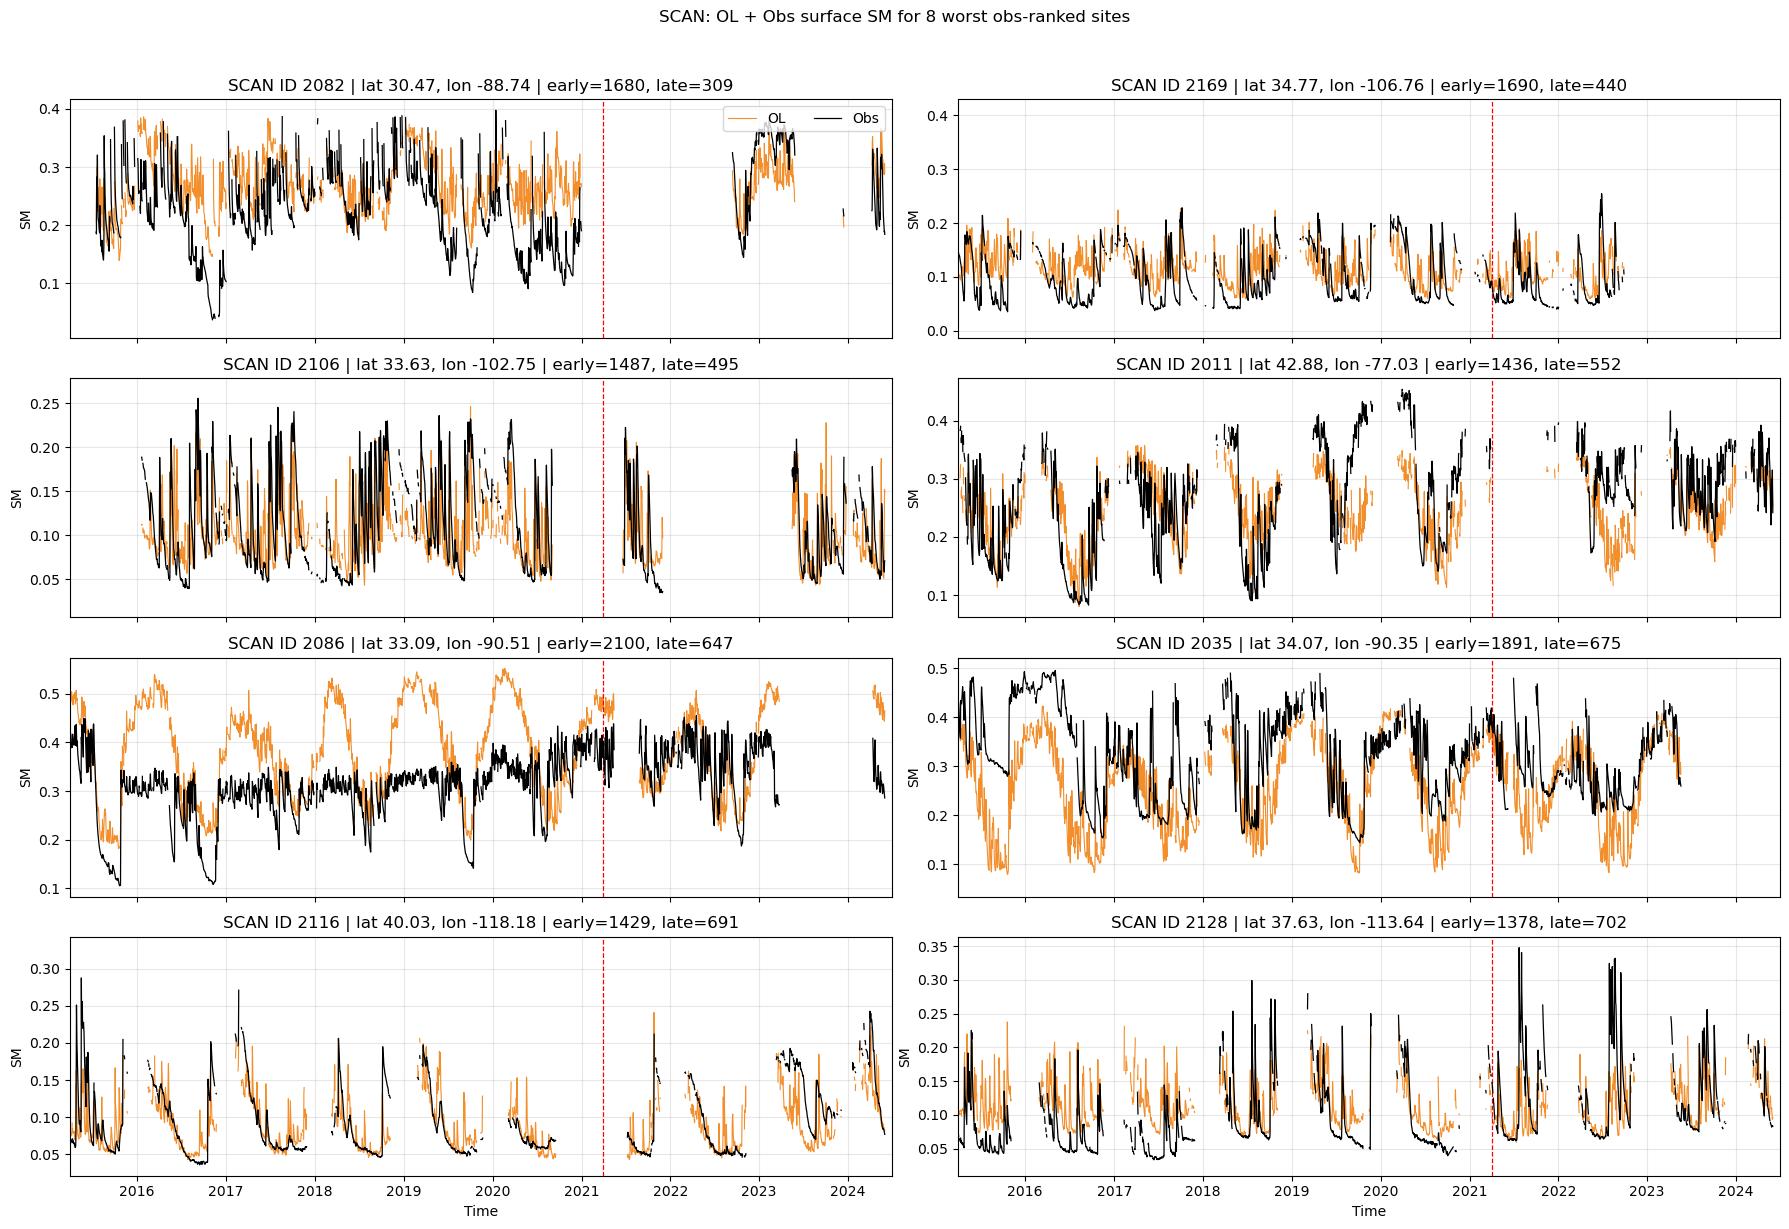

In [87]:
# -------------------------
# New figure: 8 worst sites by obs-only split-side availability (surface)
# -------------------------
if "base_split_cov_df" not in globals():
    raise RuntimeError("Run the split-coverage section first (base_split_cov_df missing).")

depth = 0
split_date = dt.datetime.fromisoformat("2021-04-01")
start_dt = dt.datetime.fromisoformat("2015-04-01")
end_dt = dt.datetime.fromisoformat("2024-06-30")

# Obs-only ranking: worst sites have lowest split-side availability
worst8_df = base_split_cov_df.sort_values(
    ["obs_days_min", "obs_days_total", "obs_days_early", "obs_days_late"],
    ascending=[True, True, True, True],
).head(8).copy()

worst8 = worst8_df["site"].astype(int).tolist()

print("Selected worst 8 sites by obs-only split availability:")
display(worst8_df[["site", "site_id", "obs_days_early", "obs_days_late", "obs_days_min", "obs_days_total", "keep"]])

fig, axs = plt.subplots(4, 2, figsize=(18, 12), sharex=True)
axs_flat = axs.ravel()

for i, site in enumerate(worst8):
    ax = axs_flat[i]
    row = worst8_df[worst8_df["site"] == site].iloc[0]

    sid = str(row["site_id"]) if "site_id" in row else (str(meta["ids"][site]) if (meta is not None and "ids" in meta and site < len(meta["ids"])) else str(site))
    lat = float(row["lat"]) if "lat" in row else np.nan
    lon = float(row["lon"]) if "lon" in row else np.nan
    lat_txt = f"{lat:.2f}" if np.isfinite(lat) else "NA"
    lon_txt = f"{lon:.2f}" if np.isfinite(lon) else "NA"

    c_early = int(row["obs_days_early"])
    c_late = int(row["obs_days_late"])

    ax.plot(timestamps, ldas_by_exp["OL"][:, depth, site], color= "#F28E2B", lw=0.8, label="OL")
    ax.plot(timestamps, obs[:, depth, site], color="k", lw=0.9, label="Obs", zorder=3)
    ax.axvline(split_date, color="red", ls="--", lw=0.9)

    ax.set_xlim(start_dt, end_dt)
    ax.set_ylabel("SM")
    ax.grid(alpha=0.3)
    ax.set_title(f"{NETWORK} ID {sid} | lat {lat_txt}, lon {lon_txt} | early={c_early}, late={c_late}")

# hide any unused panels
for j in range(len(worst8), len(axs_flat)):
    axs_flat[j].set_visible(False)

axs_flat[0].legend(loc="upper right", ncol=2)
axs[-1, 0].set_xlabel("Time")
axs[-1, 1].set_xlabel("Time")
fig.suptitle(f"{NETWORK}: OL + Obs surface SM for 8 worst obs-ranked sites", y=1.02)
plt.tight_layout()
plt.show()


### OL + Obs Time Series for 8 Best Obs-Ranked Sites (surface)


Selected best 8 sites by obs-only split availability:


,site,site_id,obs_days_early,obs_days_late,obs_days_min,obs_days_total,keep
0,30,2037,1715,1128,1128,2843,True
1,25,2032,2026,1108,1108,3134,True
2,26,2033,1879,1089,1089,2968,True
3,19,2025,2068,1081,1081,3149,True
4,66,2085,1724,1066,1066,2790,True
5,82,2110,1690,1053,1053,2743,True
6,59,2076,1451,1047,1047,2498,True
7,77,2105,1494,1009,1009,2503,True


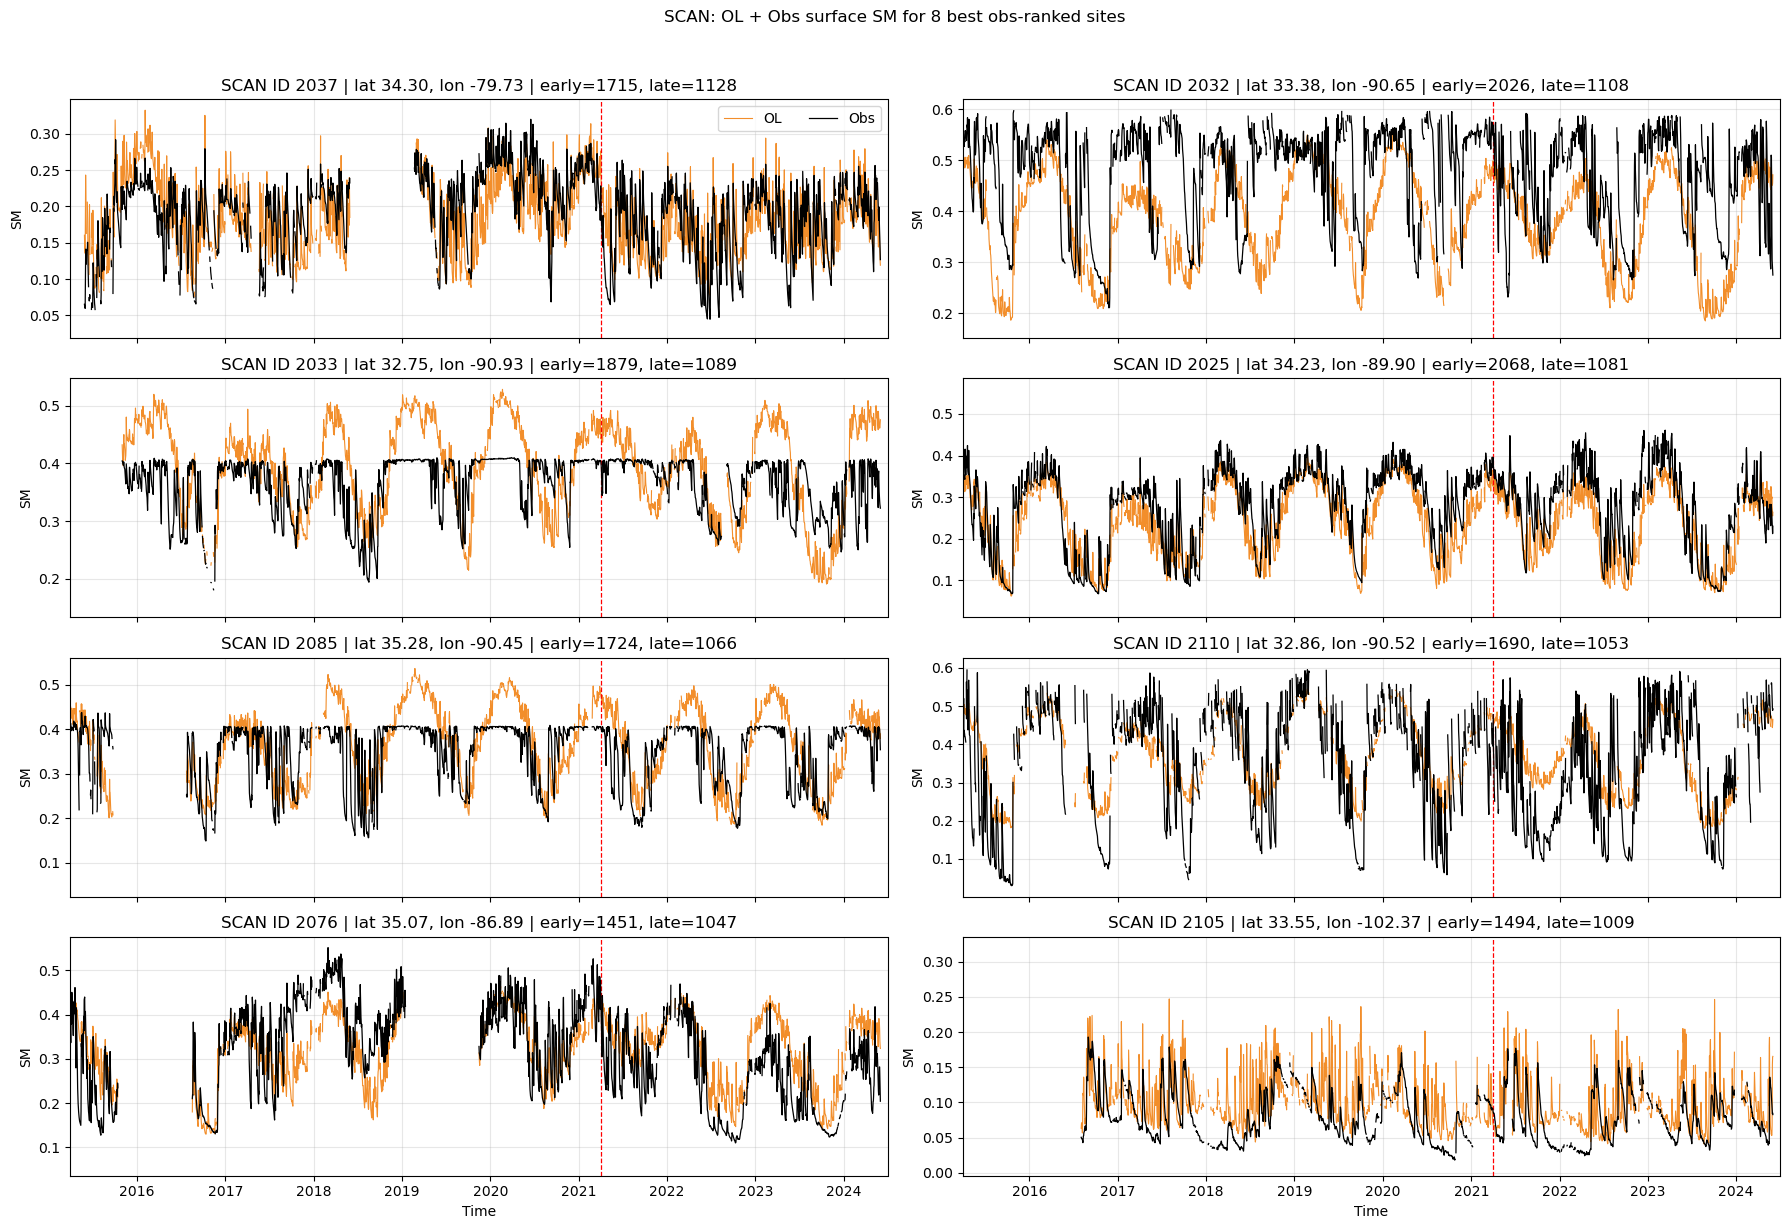

In [88]:
# -------------------------
# New figure: 8 best sites by obs-only split-side availability (surface)
# -------------------------
if "base_split_cov_df" not in globals():
    raise RuntimeError("Run the split-coverage section first (base_split_cov_df missing).")

depth = 0
split_date = dt.datetime.fromisoformat("2021-04-01")
start_dt = dt.datetime.fromisoformat("2015-04-01")
end_dt = dt.datetime.fromisoformat("2024-06-30")

# Obs-only ranking: best sites have highest split-side availability
best8_df = base_split_cov_df.sort_values(
    ["obs_days_min", "obs_days_total", "obs_days_early", "obs_days_late"],
    ascending=[False, False, False, False],
).head(8).copy()

best8 = best8_df["site"].astype(int).tolist()

print("Selected best 8 sites by obs-only split availability:")
display(best8_df[["site", "site_id", "obs_days_early", "obs_days_late", "obs_days_min", "obs_days_total", "keep"]])

fig, axs = plt.subplots(4, 2, figsize=(18, 12), sharex=True)
axs_flat = axs.ravel()

for i, site in enumerate(best8):
    ax = axs_flat[i]
    row = best8_df[best8_df["site"] == site].iloc[0]

    sid = str(row["site_id"]) if "site_id" in row else (str(meta["ids"][site]) if (meta is not None and "ids" in meta and site < len(meta["ids"])) else str(site))
    lat = float(row["lat"]) if "lat" in row else np.nan
    lon = float(row["lon"]) if "lon" in row else np.nan
    lat_txt = f"{lat:.2f}" if np.isfinite(lat) else "NA"
    lon_txt = f"{lon:.2f}" if np.isfinite(lon) else "NA"

    c_early = int(row["obs_days_early"])
    c_late = int(row["obs_days_late"])

    ax.plot(timestamps, ldas_by_exp["OL"][:, depth, site], color="#F28E2B", lw=0.8, label="OL")
    ax.plot(timestamps, obs[:, depth, site], color="k", lw=0.9, label="Obs", zorder=3)
    ax.axvline(split_date, color="red", ls="--", lw=0.9)

    ax.set_xlim(start_dt, end_dt)
    ax.set_ylabel("SM")
    ax.grid(alpha=0.3)
    ax.set_title(f"{NETWORK} ID {sid} | lat {lat_txt}, lon {lon_txt} | early={c_early}, late={c_late}")

# hide any unused panels
for j in range(len(best8), len(axs_flat)):
    axs_flat[j].set_visible(False)

axs_flat[0].legend(loc="upper right", ncol=2)
axs[-1, 0].set_xlabel("Time")
axs[-1, 1].set_xlabel("Time")
fig.suptitle(f"{NETWORK}: OL + Obs surface SM for 8 best obs-ranked sites", y=1.02)
plt.tight_layout()
plt.show()
